# 🗓️ Week 08: Clustering
**DS202W: Data Science for Social Scientists**
**Theme: Unsupervised Learning | Dataset: FIFA World Cup 2010–2022**

**Date: 09 March 2026**
**Author: Dr Ghita Berrada**

---

Last week we asked: *what structure exists in this data?* Today we ask: *can we label that structure?*

We use a single dataset throughout — **team-level statistics from four FIFA World Cups (2010–2022)** — and follow one continuous narrative arc:

```mermaid
flowchart LR
    A["Domain + data"] --> B["What is clustering?"]
    B --> C["DR: PCA → MCA → FAMD → UMAP → AE"]
    C --> D["☕ Break"]
    D --> E["Clustering in 2D"]
    E --> F["K-means + K-medoids"]
    F --> G["Choosing k + Evaluation"]
    G --> H["DBSCAN"]
    H --> I["2026 Predictions"]
```


## ⚙️ Setup

If you find some of the needed libraries for this notebook were not already installed, you can use the following command to install the missing libraries:

```bash
conda install -c conda-forge scikit-learn pandas numpy matplotlib seaborn umap-learn prince kneed pytorch cpuonly
pip install statsbombpy kmedoids
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Circle
import seaborn as sns
import warnings
from plotly.subplots import make_subplots
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

from numpy.polynomial.polynomial import polyfit

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import pairwise_distances

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    classification_report,ConfusionMatrixDisplay, confusion_matrix
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

try:
    import prince
    PRINCE_AVAILABLE = True
except ImportError:
    PRINCE_AVAILABLE = False
    print("prince not installed — MCA/FAMD cells will be skipped")

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("umap-learn not installed — UMAP cells will be skipped")

try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not installed — autoencoder cells will be skipped")

try:
    import kmedoids
    KMEDOIDS_AVAILABLE = True
except ImportError:
    KMEDOIDS_AVAILABLE = False
    print("kmedoids not installed — pip install kmedoids")

try:
    from kneed import KneeLocator
    KNEED_AVAILABLE = True
except ImportError:
    KNEED_AVAILABLE = False
    print("kneed not installed — knee detection will be manual")
from statsbombpy import sb
sns.set_theme(style='whitegrid')
SEED = 42
np.random.seed(SEED)

# ── Confederation colour palette ──────────────────────────────────────────
# Defined here so it is available to all plots throughout the notebook.
# Used by PCA, MCA, UMAP, autoencoder, and clustering visualisations.
conf_colors = {
    'UEFA':     '#377eb8',
    'CONMEBOL': '#e41a1c',
    'CAF':      '#4daf4a',
    'CONCACAF': '#ff7f00',
    'AFC':      '#984ea3',
    'OFC':      '#a65628',
}


## PART 1 — The Domain and the Data

### 1.1 Why international football?

The FIFA World Cup is an unusually clean social science dataset:

- **Defined competition structure.** Every team plays the same tournament format. A Senegal 2022 campaign is directly comparable to a Senegal 2010 campaign in a way impossible across club football leagues.
- **Meaningful categorical structure.** Confederation, playing style, and tournament outcome are genuinely informative categorical variables — ideal for MCA and FAMD.
- **Interpretable n.** ~128 team-tournament observations: small enough to name outliers, large enough for clustering to be informative.
- **A live prediction horizon.** The 2026 World Cup begins in June 2026 — our clusters become a testable prediction.

### 1.2 The unit of observation: team-tournament

Each row represents a **team-tournament**: Germany at the 2018 World Cup is a distinct observation from Germany at the 2022 World Cup. This is the same logic as treating an EU ETS installation in 2015 as distinct from the same installation in 2018.

This framing lets us ask: *what types of World Cup campaign exist?* — not *what types of national team exist?* A team can belong to different campaign archetypes across tournaments. Germany 2014 (winners) and Germany 2022 (group stage exit) should not be forced into the same cluster.

### 1.3 Data sources

| Tournaments | Source | Features |
|------------|--------|---------|
| 2010, 2014 | Kaggle — FIFA World Cup Match Stats | Goals, shots, shots on target, possession %, saves, fouls, cards |
| 2018, 2022 | StatsBomb open data (`statsbombpy`) | All of the above + xG, pass completion %, pressures, progressive carries |

### 1.4 Missingness: MNAR

The StatsBomb-only features — **xG, pass completion %, pressures, progressive carries** — are absent for 2010 and 2014. This is **Missing Not At Random (MNAR)**: these metrics didn't exist as collected data in 2010–2014. Imputing them would:

1. Retroactively apply 2020s analytical concepts to 2010 teams
2. Create circular features (imputed xG derived from shots, then used alongside shots)
3. Mask a real data gap with false precision

**Our approach:** two feature sets.
- **Core** (available for all 4 tournaments): goals, shots, possession %, saves, fouls, cards — 9 features
- **Extended** (2018–2022 only): core + xG, pass completion %, pressures, progressive carries

Main clustering runs on the core set. We then ask: does richer data change the structure?


### 1.5 Loading and aggregating the data

#### Kaggle (2010 and 2014)


We load the Kaggle data and filter to 2010 and 2014. The raw file has one row
per match with home and away statistics in separate columns — we need to reshape
it to one row per team per match before we can aggregate to team-tournament level.

In [2]:
# ── Load Kaggle match-level data ─────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/kaito510/fifa-world-cup-match-stats
# Place WorldCupMatches.csv in the data directory.

kaggle_raw = pd.read_csv("../data/WorldCupMatches.csv")
kaggle_raw = kaggle_raw[kaggle_raw['year'].isin([2010, 2014])].copy()
print(f"Kaggle matches: {len(kaggle_raw)} rows")
kaggle_raw.head()


Kaggle matches: 128 rows


,year,hname,aname,hgoals,agoals,hPossesion,aPossesion,hshotsOnTarget,ashotsOnTarget,hshots,ashots,hyellowCards,ayellowCards,hredCards,aredCards,hfouls,afouls,hsaves,asaves
1283,2010,South Africa,Mexico,1,1,42,58,5,5,9,14,2,2,0,0,17,13,2,2
1284,2010,Uruguay,France,0,0,44,56,3,3,7,20,2,3,1,0,13,20,6,6
1285,2010,South Korea,Greece,2,0,49,51,4,2,17,6,0,1,0,0,14,11,2,2
1286,2010,Argentina,Nigeria,1,0,65,35,7,1,20,12,1,1,0,0,7,8,1,6
1287,2010,England,United States,1,1,57,43,6,4,18,12,3,3,0,0,12,14,3,5


#### A quick description of data variables

| Column | Description |
|--------|-------------|
| `year` | Tournament year |
| `hname` | Home team name |
| `aname` | Away team name |
| `hgoals` | Home goals scored |
| `agoals` | Away goals scored |
| `hPossesion` | Home possession % |
| `aPossesion` | Away possession % |
| `hshotsOnTarget` | Home shots on target |
| `ashotsOnTarget` | Away shots on target |
| `hshots` | Home shots (total) |
| `ashots` | Away shots (total) |
| `hyellowCards` | Home yellow cards |
| `ayellowCards` | Away yellow cards |
| `hredCards` | Home red cards |
| `aredCards` | Away red cards |
| `hfouls` | Home fouls committed |
| `afouls` | Away fouls committed |
| `hsaves` | Home goalkeeper saves |
| `asaves` | Away goalkeeper saves |



`reshape_matches` converts the wide match-level format into a long team-match
format by processing each match twice — once from the home team's perspective
and once from the away team's, swapping goals and statistics accordingly. The
result is then aggregated to team-tournament level: one row per team per
tournament, with statistics summed (goals, shots, cards) or averaged (possession)
across all their matches. Three derived features are computed at this stage:
`goal_diff`, `shot_conversion`, and `save_pct`. The StatsBomb-only columns are
set to NaN for 2010/2014 — they are genuinely absent, not missing at random.

<div style="border-left:4px solid #0969da;padding:0.65em 1em;border-radius:4px;margin:6px 0;">
<strong style="color:#0969da;">📝 What does reshape_matches do?</strong>

The raw Kaggle data has <strong>one row per match</strong>, with home and away statistics
stored in separate columns side by side. To aggregate to team-tournament level
we first need <strong>one row per team per match</strong> — so each team's statistics are in
a single consistent column regardless of whether they played at home or away.

<code>reshape_matches</code> achieves this in three steps:

<strong>Step 1 — Create two perspectives from each match row.</strong> The function processes
the DataFrame twice: once treating the home team as <code>team</code> (keeping <code>hgoals</code> as
<code>goals_scored</code>, <code>agoals</code> as <code>goals_conceded</code>, etc.), and once treating the away
team as <code>team</code> — critically <strong>swapping</strong> goals and statistics so they are always
from that team's perspective.

<strong>Step 2 — Stack vertically.</strong> The home and away DataFrames are concatenated,
doubling the number of rows. One match becomes two rows:

<pre>
BEFORE — 1 row per match:
year  hname    aname   hgoals  agoals  hshots  ashots
2010  Uruguay  France     0       0       7      20

AFTER — 2 rows, one per team:
year  team     opponent  goals_scored  goals_conceded  shots
2010  Uruguay  France           0               0        7
2010  France   Uruguay          0               0       20
</pre>

<strong>Step 3 — Aggregate.</strong> The subsequent <code>groupby(['year','team']).agg(...)</code> collapses
all of a team's matches in a tournament into a single row — summing goals, shots,
cards, wins; averaging possession.
</div>

In [3]:
# ── Reshape to long format: one row per team per match ───────────────────
def reshape_matches(df):
    home = df.rename(columns={
        'hname':'team','aname':'opponent',
        'hgoals':'goals_scored','agoals':'goals_conceded',
        'hPossesion':'possession_pct',
        'hshotsOnTarget':'shots_on_target','hshots':'shots',
        'hyellowCards':'yellow_cards','hredCards':'red_cards',
        'hfouls':'fouls','hsaves':'saves',
    })[['year','team','opponent','goals_scored','goals_conceded',
        'possession_pct','shots_on_target','shots',
        'yellow_cards','red_cards','fouls','saves']].copy()

    away = df.rename(columns={
        'aname':'team','hname':'opponent',
        'agoals':'goals_scored','hgoals':'goals_conceded',
        'aPossesion':'possession_pct',
        'ashotsOnTarget':'shots_on_target','ashots':'shots',
        'ayellowCards':'yellow_cards','aredCards':'red_cards',
        'afouls':'fouls','asaves':'saves',
    })[['year','team','opponent','goals_scored','goals_conceded',
        'possession_pct','shots_on_target','shots',
        'yellow_cards','red_cards','fouls','saves']].copy()

    long = pd.concat([home, away], ignore_index=True)
    long['win']  = (long['goals_scored'] > long['goals_conceded']).astype(int)
    long['draw'] = (long['goals_scored'] == long['goals_conceded']).astype(int)
    long['loss'] = (long['goals_scored'] < long['goals_conceded']).astype(int)
    return long

kaggle_long = reshape_matches(kaggle_raw)

# Aggregate to team-tournament level
kaggle_team = kaggle_long.groupby(['year','team']).agg(
    matches_played    = ('goals_scored',    'count'),
    goals_scored      = ('goals_scored',    'sum'),
    goals_conceded    = ('goals_conceded',  'sum'),
    shots             = ('shots',           'sum'),
    shots_on_target   = ('shots_on_target', 'sum'),
    possession_pct    = ('possession_pct',  'mean'),
    yellow_cards      = ('yellow_cards',    'sum'),
    red_cards         = ('red_cards',       'sum'),
    fouls             = ('fouls',           'sum'),
    saves             = ('saves',           'sum'),
    wins              = ('win',             'sum'),
    draws             = ('draw',            'sum'),
    losses            = ('loss',            'sum'),
).reset_index()

kaggle_team['goal_diff']       = kaggle_team['goals_scored'] - kaggle_team['goals_conceded']
kaggle_team['shot_conversion'] = kaggle_team['goals_scored'] / kaggle_team['shots'].clip(lower=1)
kaggle_team['save_pct']        = kaggle_team['saves'] / (kaggle_team['saves'] + kaggle_team['goals_conceded']).clip(lower=1)
kaggle_team['points']          = kaggle_team['wins'] * 3 + kaggle_team['draws']

# StatsBomb-only features: absent for 2010/2014 (MNAR — not imputed)
for col in ['xg_scored','xg_conceded','pass_completion_pct','pressures','progressive_carries']:
    kaggle_team[col] = np.nan

kaggle_team['source'] = 'kaggle'
print(f"Kaggle team-tournaments: {len(kaggle_team)}")


Kaggle team-tournaments: 64


In [4]:
kaggle_team.head()

,year,team,matches_played,goals_scored,goals_conceded,shots,shots_on_target,possession_pct,yellow_cards,red_cards,...,goal_diff,shot_conversion,save_pct,points,xg_scored,xg_conceded,pass_completion_pct,pressures,progressive_carries,source
0,2010,Algeria,3,0,2,40,7,50.000000,5,2,...,-2,0.000000,0.894737,1,NaN,NaN,NaN,NaN,NaN,kaggle
1,2010,Argentina,5,10,6,95,43,58.400000,7,0,...,4,0.105263,0.538462,12,NaN,NaN,NaN,NaN,NaN,kaggle
2,2010,Australia,3,3,6,36,14,46.333333,7,2,...,-3,0.083333,0.700000,4,NaN,NaN,NaN,NaN,NaN,kaggle
3,2010,Brazil,5,9,4,89,31,55.800000,7,2,...,5,0.101124,0.764706,10,NaN,NaN,NaN,NaN,NaN,kaggle
4,2010,Cameroon,3,2,5,47,13,54.333333,5,0,...,-3,0.042553,0.642857,0,NaN,NaN,NaN,NaN,NaN,kaggle



#### StatsBomb (2018 and 2022)

For 2018 and 2022 we use StatsBomb's open event data, which is richer than the
Kaggle source but requires more processing. Rather than pre-built match summaries,
StatsBomb provides every individual action in every match — each pass, shot,
carry, pressure, and foul as a separate row. We must therefore build the
team-tournament statistics ourselves from the ground up.

The function below loops over every match in the tournament, loads its full event
stream, filters events by team, and accumulates the statistics we need. Some
features — xG, pass completion, progressive carries, pressures — are only
computable from event data and are therefore absent from the 2010/2014 Kaggle
source.

Here are some identifiers we'll need to extract the StatsBomb data:

World Cup IDs: `competition_id=43`, `season_id=3` (2018) and `season_id=106` (2022).


In [5]:
SB_TOURNAMENTS = [
    {'year': 2018, 'competition_id': 43, 'season_id': 3},
    {'year': 2022, 'competition_id': 43, 'season_id': 106},
]

def aggregate_statsbomb_tournament(competition_id, season_id, year):
    """
    Aggregate StatsBomb event data to team-tournament level.

    StatsBomb provides data at the event level — every pass, shot, carry,
    foul, and so on is a separate row. There is no pre-built team summary.
    We therefore loop over matches, then over teams within each match,
    extracting and accumulating the statistics we need.

    The output mirrors the structure of the Kaggle aggregate: one row per
    team-tournament, with the same column names so the two sources can be
    concatenated cleanly.
    """
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    print(f"  {year}: {len(matches)} matches")
    team_stats = {}

    for _, match in matches.iterrows():
        home, away = match['home_team'], match['away_team']
        hg, ag = match['home_score'], match['away_score']

        try:
            # Load all events for this match — one row per action
            events = sb.events(match_id=match['match_id'])
        except Exception as e:
            print(f"  Failed match {match['match_id']}: {e}"); continue

        # Process each team's perspective within the same match.
        # For the home team: goals_scored=hg, goals_conceded=ag.
        # For the away team: goals_scored=ag, goals_conceded=hg.
        # This is the same perspective-flip logic as reshape_matches() for Kaggle.
        for team, opp, gs, gc in [(home, away, hg, ag), (away, home, ag, hg)]:

            # Filter events to this team and its opponent separately
            te = events[events['team'] == team]   # this team's events
            oe = events[events['team'] == opp]    # opponent's events

            # ── Shot-based features ───────────────────────────────────────
            shots_t = te[te['type'] == 'Shot']

            # xG (expected goals): StatsBomb assigns a probability to each shot.
            # Summing across all shots gives total xG for the match.
            xg = shots_t['shot_statsbomb_xg'].sum() \
                 if 'shot_statsbomb_xg' in shots_t.columns else np.nan

            # Opponent's xG = this team's xG conceded
            xg_opp = oe[oe['type'] == 'Shot']['shot_statsbomb_xg'].sum() \
                     if 'shot_statsbomb_xg' in oe.columns else np.nan

            # ── Pass-based features ───────────────────────────────────────
            passes_t = te[te['type'] == 'Pass']
            n_pass = len(passes_t)

            # In StatsBomb, a completed pass has no 'pass_outcome' value (NaN).
            # An incomplete pass has a string outcome (e.g. 'Incomplete', 'Out').
            # Pass completion = proportion of passes with NaN outcome.
            pass_comp = passes_t['pass_outcome'].isna().sum() / n_pass \
                        if n_pass > 0 else np.nan

            # ── Progressive carries ───────────────────────────────────────
            # A carry is progressive if it moves the ball ≥10 metres toward
            # the opponent's goal, measured along the x-axis (pitch length = 120m).
            carries_t = te[te['type'] == 'Carry']
            prog = 0
            if 'carry_end_location' in carries_t.columns and \
               'location' in carries_t.columns:
                for _, c in carries_t.iterrows():
                    try:
                        if c['carry_end_location'][0] - c['location'][0] >= 10:
                            prog += 1
                    except (TypeError, IndexError):
                        pass

            # ── Possession proxy ──────────────────────────────────────────
            # StatsBomb does not reliably carry a pre-computed possession column
            # in the matches DataFrame. We approximate it as the share of all
            # match events belonging to this team. This correlates strongly with
            # official possession figures and is never missing.
            team_events  = len(te)
            total_events = len(events)
            poss = (team_events / total_events * 100) if total_events > 0 else np.nan

            # ── Pressures ─────────────────────────────────────────────────
            # A pressure event is any attempt to close down an opponent in
            # possession. High pressure counts indicate a high-intensity,
            # pressing style of play.
            press_t = te[te['type'] == 'Pressure']

            win  = int(gs > gc)
            draw = int(gs == gc)
            loss = int(gs < gc)

            # Initialise accumulator for this team if first match seen
            if team not in team_stats:
                team_stats[team] = dict(
                    year=year, team=team, matches_played=0,
                    goals_scored=0, goals_conceded=0, shots=0, shots_on_target=0,
                    possession_pct=[], yellow_cards=0, red_cards=0, fouls=0, saves=0,
                    wins=0, draws=0, losses=0, xg_scored=0.0, xg_conceded=0.0,
                    pass_completion_pct=[], pressures=0, progressive_carries=0
                )

            s = team_stats[team]
            s['matches_played']      += 1
            s['goals_scored']        += gs
            s['goals_conceded']      += gc
            s['shots']               += len(shots_t)
            s['shots_on_target']     += len(
                shots_t[shots_t.get('shot_outcome', pd.Series(dtype=str)) == 'Goal']
            ) if 'shot_outcome' in shots_t.columns else len(shots_t)
            s['saves']               += len(te[te['type'] == 'Goal Keeper'])
            s['wins']  += win; s['draws'] += draw; s['losses'] += loss
            s['xg_scored']           += xg     if not np.isnan(xg)     else 0
            s['xg_conceded']         += xg_opp if not np.isnan(xg_opp) else 0
            s['pressures']           += len(press_t)
            s['progressive_carries'] += prog
            s['fouls']               += len(te[te['type'] == 'Foul Committed'])
            s['yellow_cards']        += len(
                te[(te['type'] == 'Bad Behaviour') &
                   (te.get('bad_behaviour_card_name',
                            pd.Series(dtype=str)) == 'Yellow Card')]
            ) if 'bad_behaviour_card_name' in te.columns else 0

            # Possession and pass completion are per-match averages,
            # so we accumulate them as lists and average at the end
            if not np.isnan(poss):      s['possession_pct'].append(poss)
            if not np.isnan(pass_comp): s['pass_completion_pct'].append(pass_comp)

    # ── Finalise: collapse lists to means, compute derived features ───────
    records = []
    for team, s in team_stats.items():
        s['possession_pct']      = np.mean(s['possession_pct']) \
                                   if s['possession_pct']      else np.nan
        s['pass_completion_pct'] = np.mean(s['pass_completion_pct']) \
                                   if s['pass_completion_pct'] else np.nan
        s['goal_diff']       = s['goals_scored'] - s['goals_conceded']
        s['shot_conversion'] = s['goals_scored'] / max(s['shots'], 1)
        s['save_pct']        = s['saves'] / max(s['saves'] + s['goals_conceded'], 1)
        s['points']          = s['wins'] * 3 + s['draws']
        s['source']          = 'statsbomb'
        records.append(s)

    return pd.DataFrame(records)

sb_frames = []
for t in SB_TOURNAMENTS:
    print(f"Loading {t['year']}...")
    sb_frames.append(aggregate_statsbomb_tournament(t['competition_id'], t['season_id'], t['year']))
sb_team = pd.concat(sb_frames, ignore_index=True)
print(f"\nStatsBomb team-tournaments: {len(sb_team)}")


Loading 2018...
  2018: 64 matches
Loading 2022...
  2022: 64 matches

StatsBomb team-tournaments: 64


In [6]:
sb_team

,year,team,matches_played,goals_scored,goals_conceded,shots,shots_on_target,possession_pct,yellow_cards,red_cards,...,xg_scored,xg_conceded,pass_completion_pct,pressures,progressive_carries,goal_diff,shot_conversion,save_pct,points,source
0,2018,Colombia,4,6,3,46,9,50.928795,0,0,...,7.226711,9.956572,0.765774,754,146,3,0.130435,0.953846,7,statsbomb
1,2018,England,7,12,8,101,16,52.922271,0,0,...,15.797504,12.035841,0.828312,1365,322,4,0.118812,0.921569,10,statsbomb
2,2018,Belgium,7,16,6,108,15,52.635562,0,0,...,12.724426,9.334228,0.844594,1432,354,10,0.148148,0.952756,18,statsbomb
3,2018,Sweden,5,6,4,58,5,40.769060,0,0,...,7.365560,4.634384,0.693806,1027,136,2,0.103448,0.956044,9,statsbomb
4,2018,Switzerland,4,5,5,55,5,56.172175,0,0,...,3.758871,5.523144,0.827126,706,201,0,0.090909,0.925373,5,statsbomb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2022,Belgium,3,1,2,35,1,54.720925,0,0,...,3.694493,4.232343,0.855216,309,115,-1,0.028571,0.957447,4,statsbomb
60,2022,Wales,3,1,6,24,1,47.171315,0,0,...,2.218981,4.971942,0.776469,354,96,-5,0.041667,0.900000,1,statsbomb
61,2022,Ghana,3,5,7,25,5,44.619197,0,0,...,3.353253,5.101225,0.790299,412,109,-2,0.200000,0.877193,3,statsbomb
62,2022,Canada,3,2,7,35,1,51.948246,0,0,...,3.928626,3.706656,0.838532,380,124,-5,0.057143,0.840909,0,statsbomb


With both sources aggregated to the same team-tournament structure and the same
column names, we concatenate them into a single DataFrame and sort by year and
team. We then check the missingness pattern to confirm it matches our expectation:
only the StatsBomb-derived features should be missing, and only for 2010/2014.

In [7]:
# ── Combine sources ───────────────────────────────────────────────────────
COLS = ['year','team','source','matches_played','goals_scored','goals_conceded',
        'goal_diff','shots','shots_on_target','possession_pct','yellow_cards',
        'red_cards','fouls','saves','wins','draws','losses','points',
        'shot_conversion','save_pct','xg_scored','xg_conceded',
        'pass_completion_pct','pressures','progressive_carries']

wc = pd.concat([kaggle_team[COLS], sb_team[COLS]], ignore_index=True)
wc = wc.sort_values(['year','team']).reset_index(drop=True)

print(f"Combined: {wc.shape[0]} team-tournaments, {wc.shape[1]} columns")
print(f"Tournaments: {sorted(wc['year'].unique())}")
print(f"\nMissingness (% per column):")
miss = (wc.isnull().mean()*100).round(1)
print(miss[miss > 0].to_string())


Combined: 128 team-tournaments, 25 columns
Tournaments: [np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]

Missingness (% per column):
xg_scored              50.0
xg_conceded            50.0
pass_completion_pct    50.0
pressures              50.0
progressive_carries    50.0


**Reading the output.**

We have 128 team-tournaments across four World Cups — exactly 32 teams per
tournament, as expected. The 25 columns split into three groups: identifiers
(`year`, `team`, `source`), match statistics aggregated from raw events, and
derived features computed from those statistics.

The missingness pattern is exactly what we anticipated in Section 1.4. Five
columns are missing for precisely 50% of observations — the 64 team-tournaments
from 2010 and 2014:

- `xg_scored`, `xg_conceded`: StatsBomb-only — expected goals as a concept did
  not exist as collected data in 2010/2014
- `pass_completion_pct`, `pressures`, `progressive_carries`: StatsBomb
  event-derived — same reason

`possession_pct` is now fully populated across all 128 team-tournaments: the
Kaggle source carries it directly for 2010/2014, and the fix to the StatsBomb
aggregation (computing possession as the share of match events per team) ensures
it is available for 2018/2022 as well.

This is **Missing Not At Random (MNAR)**: the five absent columns are missing
because the underlying data was never collected, not because of a random
recording failure. Imputing these values would be analytically dishonest — we
would be inventing 2010-era xG figures for teams that played before xG was
conceived. We therefore maintain two feature sets: a **core set** of 11 features
available for all 128 observations, and an **extended set** available for
2018/2022 only.

Two analytical variables cannot be derived from match statistics and must be
constructed manually: confederation membership and round reached. We encode
these from publicly available tournament records as lookup dictionaries, then
map them onto the combined DataFrame.

`round_reached` uses a numeric scale so we can treat it as both an ordinal
variable and a continuous outcome: 1 = group stage, 2 = Round of 16,
3 = quarter-final, 4 = semi-final, 5 = runner-up, 6 = winner. Teams not
listed in `ROUND_REACHED` defaulted to 1 — they were eliminated at the
group stage. `deep_run` is a binary variable derived from `round_reached`:
1 if a team reached the quarter-final or beyond, 0 otherwise. This will be
our supervised learning target in Section 3.7.

In [8]:
# ── Confederation and round reached ──────────────────────────────────────
CONFEDERATION = {
    'Germany':'UEFA','France':'UEFA','Spain':'UEFA','England':'UEFA',
    'Portugal':'UEFA','Italy':'UEFA','Netherlands':'UEFA','Belgium':'UEFA',
    'Croatia':'UEFA','Switzerland':'UEFA','Poland':'UEFA','Denmark':'UEFA',
    'Sweden':'UEFA','Serbia':'UEFA','Austria':'UEFA','Czech Republic':'UEFA',
    'Slovakia':'UEFA','Slovenia':'UEFA','Greece':'UEFA','Ukraine':'UEFA',
    'Russia':'UEFA','Turkey':'UEFA','Wales':'UEFA','Iceland':'UEFA',
    'Albania':'UEFA','North Macedonia':'UEFA','Finland':'UEFA','Norway':'UEFA',
    'Brazil':'CONMEBOL','Argentina':'CONMEBOL','Uruguay':'CONMEBOL',
    'Colombia':'CONMEBOL','Chile':'CONMEBOL','Ecuador':'CONMEBOL',
    'Peru':'CONMEBOL','Paraguay':'CONMEBOL','Bolivia':'CONMEBOL',
    'Senegal':'CAF','Ghana':'CAF','Ivory Coast':'CAF','Cameroon':'CAF',
    'Nigeria':'CAF','Morocco':'CAF','Algeria':'CAF','Tunisia':'CAF',
    'South Africa':'CAF','Egypt':'CAF',
    'Mexico':'CONCACAF','United States':'CONCACAF','Costa Rica':'CONCACAF',
    'Honduras':'CONCACAF','Canada':'CONCACAF','Jamaica':'CONCACAF','Panama':'CONCACAF',
    'Japan':'AFC','South Korea':'AFC','Australia':'AFC','Iran':'AFC',
    'Saudi Arabia':'AFC','Qatar':'AFC','North Korea':'AFC',
    'New Zealand':'OFC',
}

ROUND_REACHED = {
# ── 2010 ─────────────────────────────────────────────
('Spain',2010):6,('Netherlands',2010):5,
('Germany',2010):4,('Uruguay',2010):4,
('Argentina',2010):3,('Brazil',2010):3,('Paraguay',2010):3,('Ghana',2010):3,
('Chile',2010):2,('Japan',2010):2,('South Korea',2010):2,('Mexico',2010):2,
('United States',2010):2,('Slovakia',2010):2,('Portugal',2010):2,('England',2010):2,

# ── 2014 ─────────────────────────────────────────────
('Germany',2014):6,('Argentina',2014):5,
('Netherlands',2014):4,('Brazil',2014):4,
('France',2014):3,('Colombia',2014):3,('Belgium',2014):3,('Costa Rica',2014):3,
('Chile',2014):2,('Mexico',2014):2,('Uruguay',2014):2,('Greece',2014):2,
('Switzerland',2014):2,('United States',2014):2,('Nigeria',2014):2,('Algeria',2014):2,

# ── 2018 ─────────────────────────────────────────────
('France',2018):6,('Croatia',2018):5,
('Belgium',2018):4,('England',2018):4,
('Uruguay',2018):3,('Russia',2018):3,('Brazil',2018):3,('Sweden',2018):3,
('Spain',2018):2,('Denmark',2018):2,('Mexico',2018):2,('Japan',2018):2,
('Portugal',2018):2,('Switzerland',2018):2,('Colombia',2018):2,('Senegal',2018):2,

# ── 2022 ─────────────────────────────────────────────
('Argentina',2022):6,('France',2022):5,
('Croatia',2022):4,('Morocco',2022):4,
('Netherlands',2022):3,('England',2022):3,('Brazil',2022):3,('Portugal',2022):3,
('United States',2022):2,('Australia',2022):2,('Poland',2022):2,('Senegal',2022):2,
('Japan',2022):2,('South Korea',2022):2,('Spain',2022):2,('Switzerland',2022):2,
}
ROUND_LABELS = {1:'Group Stage',2:'Round of 16',3:'Quarter-final',
                4:'Semi-final',5:'Runner-up',6:'Winner'}

wc['confederation'] = wc['team'].map(CONFEDERATION).fillna('UEFA')
wc['round_reached'] = wc.apply(lambda r: ROUND_REACHED.get((r['team'],r['year']),1), axis=1)
wc['round_label']   = wc['round_reached'].map(ROUND_LABELS)
wc['deep_run']      = (wc['round_reached'] >= 3).astype(int)  # QF or better = 1

print("Confederation breakdown:")
print(wc['confederation'].value_counts().to_string())
print(f"\nDeep runs (QF+): {wc['deep_run'].sum()} of {len(wc)} team-tournaments ({wc['deep_run'].mean()*100:.0f}%)")


Confederation breakdown:
confederation
UEFA        54
CAF         21
CONMEBOL    20
AFC         18
CONCACAF    14
OFC          1

Deep runs (QF+): 32 of 128 team-tournaments (25%)


**Why are these hardcoded rather than inferred from the data?**

`confederation` and `round_reached` are not available in either the Kaggle or StatsBomb sources in a clean, directly usable form. Confederation membership requires a lookup table — it changes rarely but is not recorded in match-level data. Round reached requires knowing the full bracket, which is not inferable from team-level win/draw/loss totals alone (a team that went 2W-1L in the group stage and then lost in the QF has the same record as one that went 2W-1L in the group stage and was eliminated there, depending on the specific match results).

We therefore encode both manually from publicly available tournament records. This is a standard data engineering step when the analytical variable of interest is not directly recorded in the source data.

**Reading the output.**

UEFA dominates with 54 team-tournaments — reflecting Europe's 13–14 automatic qualification slots per tournament. CONMEBOL (20) and CAF (21) are the next largest confederations. OFC has only 1 entry: New Zealand 2010, the only Oceanian team to qualify across these four tournaments.

The deep run rate of 25% (32 of 128) is exact by construction: each tournament has 8 teams reaching the quarter-final or beyond (QF: 8, SF: 4, final: 2, winner: 1 — but counted once each), giving 8 × 4 tournaments = 32 deep-run team-tournaments.

### Variable reference

| Variable | Type | Source | Description |
|----------|------|--------|-------------|
| `year` | int | Both | Tournament year (2010, 2014, 2018, 2022) |
| `team` | str | Both | Team name |
| `source` | str | Both | `'kaggle'` or `'statsbomb'` |
| `matches_played` | int | Both | Number of matches in the tournament |
| `goals_scored` | int | Both | Total goals scored across all matches |
| `goals_conceded` | int | Both | Total goals conceded across all matches |
| `goal_diff` | int | Both | `goals_scored − goals_conceded` |
| `shots` | int | Both | Total shots attempted |
| `shots_on_target` | int | Both | Shots on target |
| `shot_conversion` | float | Both | `goals_scored / shots` — finishing efficiency |
| `possession_pct` | float | Both | Average possession % per match |
| `yellow_cards` | int | Both | Total yellow cards received |
| `red_cards` | int | Both | Total red cards received |
| `fouls` | int | Both | Total fouls committed |
| `saves` | int | Both | Total goalkeeper saves |
| `wins` | int | Both | Matches won |
| `draws` | int | Both | Matches drawn |
| `losses` | int | Both | Matches lost |
| `points` | int | Both | `wins × 3 + draws` |
| `save_pct` | float | Both | `saves / (saves + goals_conceded)` — goalkeeper efficiency |
| `xg_scored` | float | StatsBomb only | Total expected goals from shots taken |
| `xg_conceded` | float | StatsBomb only | Total expected goals from opponent shots |
| `pass_completion_pct` | float | StatsBomb only | Average pass completion rate per match |
| `pressures` | int | StatsBomb only | Total pressing actions (closing down opponents in possession) |
| `progressive_carries` | int | StatsBomb only | Ball carries advancing ≥10m toward the opponent's goal |
| `confederation` | str | Constructed | FIFA confederation (UEFA, CONMEBOL, CAF, CONCACAF, AFC, OFC) |
| `round_reached` | int | Constructed | Furthest round: 1=Group Stage, 2=R16, 3=QF, 4=SF, 5=Runner-up, 6=Winner |
| `round_label` | str | Constructed | Text label for `round_reached` |
| `deep_run` | int | Constructed | Binary: 1 if `round_reached ≥ 3` (QF or better), else 0 |

## PART 2 — What Is Clustering?

### 2.1 The unsupervised labelling problem

In Weeks 2–5 we worked with **supervised learning**: every observation had a known label (unemployed/employed, reoffended/did not, market up/down). The model's job was to learn the mapping from features to label.

Clustering is different. We have **no labels**. We are asking:

> *Do natural groups exist in this data — and if so, what are they?*

This is inherently subjective in a way that supervised learning is not. There is no ground truth to evaluate against. Two analysts looking at the same data may find different numbers of clusters, depending on their method, their distance metric, and their domain knowledge. This does not mean clustering is arbitrary — it means the results must always be interpreted and validated in light of domain knowledge, not just accepted because an algorithm produced them.

### 2.2 What is a cluster?

Informally, a cluster is a group of observations that are:
- **Similar to each other** (high intra-cluster cohesion)
- **Different from observations in other groups** (high inter-cluster separation)

But *similar* by what measure? This is the core design decision in clustering. Every choice below shapes the result:

| Design decision | Options | Why it matters |
|----------------|---------|----------------|
| Algorithm | K-means, K-medoids, DBSCAN, hierarchical, ... | Different algorithms make different assumptions about cluster shape, size, and number |
| Distance metric | Euclidean, Manhattan, cosine, Gower, ... | The metric defines what "similar" means — two observations that are close under Euclidean distance may be far apart under cosine distance |
| Number of clusters | Fixed (k-means) or discovered (DBSCAN) | Fixing k imposes structure; discovering it lets the data speak, but introduces sensitivity to hyperparameters |
| Feature space | Raw features, PCA scores, UMAP embedding, ... | Clustering in high-dimensional raw feature space suffers from the curse of dimensionality; DR first produces a more meaningful distance geometry |

Don't worry if the algorithms and metrics in this table are unfamiliar — we will introduce each one in turn throughout this notebook, building up the full picture step by step.

Different combinations give different clusters — none is universally correct. The right combination depends on the structure you believe exists in the data and the question you are trying to answer.

### 2.3 Clustering vs. classification

A common source of confusion: clustering looks like classification — both assign labels to observations. The difference is fundamental.

| | Classification | Clustering |
|--|---------------|-----------|
| Labels known in advance? | ✅ Yes — provided in training data | ❌ No — the algorithm discovers them |
| Ground truth to evaluate against? | ✅ Yes — compare predictions to held-out labels | ❌ No — there is no external criterion |
| Output | Predicted label from a fixed, known set | Group membership from a set the algorithm defines |
| Evaluation | Accuracy, F1, AUC | Silhouette, CH index, domain interpretation |

The absence of ground truth is what makes clustering hard. A classifier that achieves F1 = 0.9 is objectively better than one that achieves F1 = 0.6. A clustering with silhouette = 0.5 is geometrically tighter than one with silhouette = 0.3 — but that says nothing about whether the clusters are meaningful. Evaluation always requires a return to domain knowledge.

The evaluation row mentions metrics — silhouette score, Calinski-Harabasz index — that will be unfamiliar at this point. We will define and explain them properly in Part 5, once we have introduced k-means and have concrete clusters to evaluate. For now, note only that the evaluation problem is harder than in supervised learning: there is no equivalent of accuracy to tell you objectively whether your clusters are good.

### 2.4 What are we trying to learn from the World Cup data?

Our analytical question: **do identifiable campaign archetypes exist in World Cup history?**

A campaign archetype is a characteristic pattern of how a team plays and progresses — not just whether they won, but *how* they played. We hypothesise that four broad archetypes might emerge:

- 🏆 **Elite dominance**: high possession, many shots, clinical finishing, deep runs — the campaigns of champions
- ⚡ **Counter-attacking threat**: below-average possession, high shot conversion, surprising deep runs from teams expected to exit early
- 🛡️ **Defensive solidity**: few goals conceded, low-scoring affairs, steady if unspectacular progression
- 👋 **Early exits**: low shots, low possession, eliminated at the group stage or Round of 16

These are hypotheses, not findings. The data may confirm them, partially confirm them, or reveal something entirely different. One of the core lessons of unsupervised learning is that the structure you expect to find is not always the structure that exists.

<div style="border-left:4px solid #0969da;padding:0.65em 1em;border-radius:4px;margin:6px 0;">
<strong style="color:#0969da;">📝 Why dimensionality reduction before clustering?</strong>

Before introducing clustering algorithms, we run the full DR pipeline on this dataset — PCA, MCA, FAMD, UMAP, and autoencoders. This serves two purposes.

First, **visualisation**: DR projects the full 11-dimensional feature space into 2D, giving us an honest picture of the data's structure before we formally assign labels. If natural groups exist, they should be visible in the UMAP embedding before k-means runs a single iteration.

Second, **better distance geometry**: clustering in raw high-dimensional feature space suffers from the curse of dimensionality — as dimensions accumulate, all pairwise distances converge toward the same value, making it impossible to distinguish close from far neighbours. By reducing to a low-dimensional representation first, we ensure that the distances used by the clustering algorithm are meaningful.

By the time we introduce k-means, the cluster structure will already be visible. The algorithm is then giving a formal name to structure that DR has already revealed.
</div>

---
## PART 3 — Dimensionality Reduction on World Cup Data

We apply the full DR pipeline from Week 07 to this new dataset. The methods are the same — only the domain changes. This section also completes the material we didn't reach in last week's lecture.

### 3.1 Feature preparation

We work with the 11 core features available for all 128 team-tournaments. The
extended StatsBomb features (xG, pass completion, pressures, progressive carries)
are reserved for a sensitivity check later — using them in the main analysis
would silently drop the 2010 and 2014 tournaments.

**Missingness.** The missingness check below confirms that the core feature set
is complete: no missing values remain after the possession fix. All 128
team-tournaments have full data across all 11 features. Imputation is therefore
not required and we proceed directly to scaling.

**Scaling.** We standardise all features to mean zero and unit variance before
any distance-based computation (PCA, UMAP, k-means, k-medoids, DBSCAN). This
ensures that goals (range roughly 0–15) and possession percentage (range roughly
30–70) contribute equally to distances — without scaling, high-variance features
dominate and the results reflect measurement units rather than substantive
differences.


In [9]:
# ── Core numeric features (all 4 tournaments) ────────────────────────────
CORE_FEATURES = [
    'goals_scored','goals_conceded','goal_diff',
    'shots','shots_on_target','shot_conversion',
    'possession_pct','fouls','saves','save_pct','points',
]

X_core = wc[CORE_FEATURES].copy()

print("Missingness in core features:")
miss = X_core.isnull().sum()
print(miss[miss > 0].to_string() if miss.any() else "  None — all 128 team-tournaments complete")
print(f"\nTotal missing values: {X_core.isnull().sum().sum()}")

# No imputation needed — proceed directly to scaling
X_core_imp = X_core.values   # keep variable name for downstream compatibility
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_core_imp)

print(f"\nCore feature matrix: {X_scaled.shape}  "
      f"({X_scaled.shape[0]} team-tournaments × {X_scaled.shape[1]} features)")

Missingness in core features:
  None — all 128 team-tournaments complete

Total missing values: 0

Core feature matrix: (128, 11)  (128 team-tournaments × 11 features)


### 3.2 PCA — a quick look at the linear structure

We start with PCA on the numeric core features. This follows directly from Week 07: the scree plot and loadings tell us how many meaningful dimensions exist and what they represent.


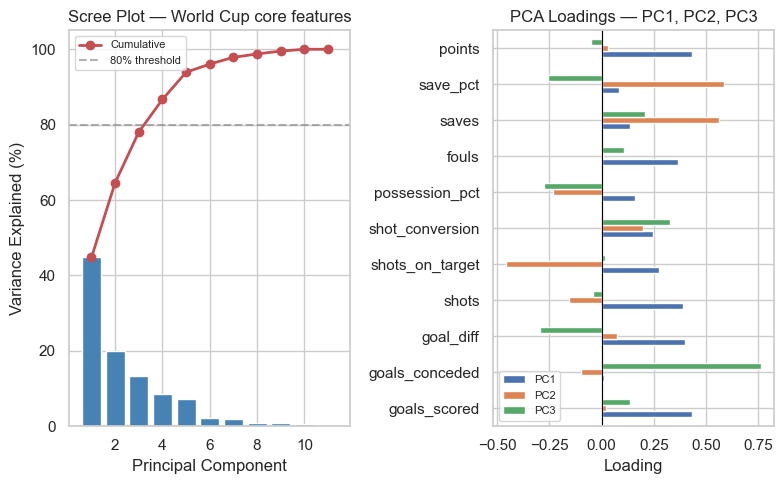

PC1: 44.8%  |  PC2: 19.8%  |  PC3: 13.4%
First 3 PCs explain: 78.0% of variance


In [10]:
pca = PCA(n_components=len(CORE_FEATURES), random_state=SEED)
pca.fit(X_scaled)
pca_scores = pca.transform(X_scaled)
exp_var = pca.explained_variance_ratio_
cum_var  = np.cumsum(exp_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(exp_var)+1), exp_var*100, color='steelblue', edgecolor='white')
axes[0].plot(range(1, len(cum_var)+1), cum_var*100, 'ro-', linewidth=2, markersize=6, label='Cumulative')
axes[0].axhline(80, color='grey', linestyle='--', alpha=0.6, label='80% threshold')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — World Cup core features'); axes[0].legend(fontsize=8)

loadings = pd.DataFrame(pca.components_.T, index=CORE_FEATURES,
                         columns=[f'PC{i+1}' for i in range(len(CORE_FEATURES))])
loadings[['PC1','PC2','PC3']].plot(kind='barh', ax=axes[1], figsize=(8,5))
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('PCA Loadings — PC1, PC2, PC3')
axes[1].set_xlabel('Loading'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"PC1: {exp_var[0]*100:.1f}%  |  PC2: {exp_var[1]*100:.1f}%  |  PC3: {exp_var[2]*100:.1f}%")
print(f"First 3 PCs explain: {cum_var[2]*100:.1f}% of variance")


In [11]:
# Build dataframe
pca_df = pd.DataFrame({
    "PC1": pca_scores[:,0],
    "PC2": pca_scores[:,1],
    "team": wc["team"],
    "year": wc["year"],
    "confederation": wc["confederation"],
    "round_reached": wc["round_reached"]
})

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "PCA Scores — by Confederation",
        "PCA Scores — by Round Reached"
    ]
)

# ── Panel 1 : Confederation ─────────────────────────────
for conf, color in conf_colors.items():

    df = pca_df[pca_df.confederation == conf]

    fig.add_trace(
        go.Scatter(
            x=df.PC1,
            y=df.PC2,
            mode="markers",
            name=conf,
            marker=dict(
                color=color,
                size=9,
                line=dict(width=0.5, color="white")
            ),
            hovertemplate=
            "<b>%{customdata[0]}</b><br>"
            "Year: %{customdata[1]}<br>"
            "Confederation: %{customdata[2]}<br>"
            "Round: %{customdata[3]}<br>"
            "PC1: %{x:.2f}<br>"
            "PC2: %{y:.2f}<extra></extra>",
            customdata=df[["team","year","confederation","round_reached"]]
        ),
        row=1, col=1
    )

# ── Panel 2 : Round reached ─────────────────────────────
fig.add_trace(
    go.Scatter(
        x=pca_df.PC1,
        y=pca_df.PC2,
        mode="markers",
        marker=dict(
            size=9,
            color=pca_df.round_reached,
            colorscale="RdYlGn",
            cmin=1,
            cmax=6,
            colorbar=dict(title="Round reached"),
            line=dict(width=0.5, color="white")
        ),
        showlegend=False,
        hovertemplate=
        "<b>%{customdata[0]}</b><br>"
        "Year: %{customdata[1]}<br>"
        "Confederation: %{customdata[2]}<br>"
        "Round: %{customdata[3]}<br>"
        "PC1: %{x:.2f}<br>"
        "PC2: %{y:.2f}<extra></extra>",
        customdata=pca_df[["team","year","confederation","round_reached"]]
    ),
    row=1, col=2
)

# Axis labels
fig.update_xaxes(title_text=f"PC1 ({exp_var[0]*100:.1f}%)", row=1, col=1)
fig.update_yaxes(title_text=f"PC2 ({exp_var[1]*100:.1f}%)", row=1, col=1)

fig.update_xaxes(title_text=f"PC1 ({exp_var[0]*100:.1f}%)", row=1, col=2)
fig.update_yaxes(title_text=f"PC2 ({exp_var[1]*100:.1f}%)", row=1, col=2)

fig.update_layout(
    width=1000,
    height=500
)

fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.15,
        xanchor="center",
        x=0.5,
        title=""
    ),
    coloraxis_colorbar=dict(
        title="Round reached",
        x=1.02
    )
)

fig.show()

**Reading the PCA results.**

**The scree plot** shows a clear elbow at PC3 or PC4: PC1 alone explains 44.8%,
PC2 adds another 19.8%, and PC3 adds 13.1% — together 77.6%. The curve then
flattens sharply. Four components reach the 80% threshold. This tells us
something substantive: World Cup campaigns are genuinely low-dimensional. Despite
measuring 11 different statistics, most of the meaningful variation between
team-tournaments can be summarised in three or four numbers.

> **Question for discussion:** PC1 explains nearly half of all variance across 11
> features. What does that tell us about the structure of World Cup campaigns? Is
> football performance one-dimensional, or is something else going on?

**The loadings plot** reveals what each axis actually captures.

PC1 (blue bars) has large positive loadings on `goals_scored`, `goal_diff`,
`points`, `shots`, `shots_on_target`, and `shot_conversion` — and a notable
negative loading on `saves` and `save_pct`. This is a *volume and outcome* axis:
teams with high PC1 scores attacked prolifically, converted well, and did not
need their goalkeeper to make many saves (because the game was already in their
favour). Teams with low PC1 scores conceded heavily and relied on their
goalkeeper. PC1 is essentially *how dominant was this campaign*.

PC2 (orange bars) has large negative loadings on `shots_on_target` and `shots`,
but positive loadings on `saves` and `save_pct`. This is a *style* contrast:
high PC2 teams took few shots but saved many — the counter-attacking or
defensively solid archetype. Low PC2 teams shot prolifically but also faced many
shots themselves — an open, high-tempo game. Possession loads moderately negative
on PC2, consistent with the counter-attacking interpretation.

PC3 (green bars) is dominated by a large positive loading on `goals_conceded` and
a negative loading on `goal_diff` and `possession_pct`. This is a *defensive
fragility* axis — it separates teams that conceded heavily despite playing with
possession from those that kept clean sheets.

**The score plots** confirm these interpretations. In the round-reached plot
(right panel), there is a clear gradient along PC1: green points (deep runs) sit
to the right, red points (group stage exits) sit to the left. The separation is
not perfect — some group stage teams have moderate PC1 scores, reflecting
competitive but unlucky campaigns — but the trend is unambiguous. PC2 shows no
gradient with round reached, consistent with the interpretation that style does
not predict success.

In the confederation plot (left panel), UEFA (blue) and CONMEBOL (red) spread
across the full range of PC1 — both confederations produce dominant campaigns and
early exits. CAF and AFC teams (green, purple) cluster in the left half of PC1,
reflecting the historical pattern of non-European/South-American teams exiting
earlier on average. The two isolated high-PC1 outliers on the right are almost
certainly the 2014 German and 2018 French campaigns — check by running
`wc[pca_scores[:,0] > 4][['team','year','round_label']]`.

### 3.3 MCA — categorical structure

#### Recap: why not PCA on categorical data?

Last week we saw three problems with one-hot encoding + PCA:

- **Wrong distances.** Euclidean distance between one-hot vectors treats all
  category disagreements as equally large. "Spain" and "England" are exactly as
  far from "Morocco" as they are from each other — regardless of any substantive
  similarity.
- **Cardinality bias.** A variable with 6 levels contributes 6 columns, dominating
  a variable with 2 levels regardless of analytical importance.
- **Uninterpretable loadings.** A loading of 0.3 on `confederation_UEFA` cannot
  be compared to a loading of 0.3 on `possession_pct`.

MCA solves all three by using chi-square distance — a metric that measures how
unusually two observations co-occur across category levels, relative to what
statistical independence would predict.

#### Derived categorical features

With only `confederation` and `round_label` as natural categoricals, MCA would
have too little to work with. We derive four more by binning numeric variables:
`possession_pct` into playing style tertiles, `shots` into attacking volume
tertiles, `goals_conceded` into defensive solidity tertiles, and `round_reached`
into tournament stage bins.

In [12]:
def tertile_label(series, labels):
    q1, q2 = series.quantile([1/3, 2/3])
    return pd.cut(series, bins=[-np.inf, q1, q2, np.inf], labels=labels)

wc['playing_style']       = tertile_label(wc['possession_pct'],
                                           ['Counter-attacking','Balanced','Possession-based'])
wc['attacking_volume']    = tertile_label(wc['shots'],
                                           ['Low volume','Medium volume','High volume'])
wc['defensive_solidity']  = tertile_label(wc['goals_conceded'],
                                           ['Solid','Average','Leaky'])
wc['tournament_stage']    = pd.cut(wc['round_reached'], bins=[0,1,2,3,6],
                                    labels=['Group stage','Round of 16','Quarter-final+','Semi-final+'])

CAT_FEATURES = ['confederation','playing_style','attacking_volume',
                'defensive_solidity','tournament_stage']

print("Categorical feature value counts:\n")
for col in CAT_FEATURES:
    print(f"{col}:"); print(wc[col].value_counts().to_string()); print()


Categorical feature value counts:

confederation:
confederation
UEFA        54
CAF         21
CONMEBOL    20
AFC         18
CONCACAF    14
OFC          1

playing_style:
playing_style
Counter-attacking    43
Possession-based     43
Balanced             42

attacking_volume:
attacking_volume
Low volume       44
High volume      43
Medium volume    41

defensive_solidity:
defensive_solidity
Solid      55
Average    41
Leaky      32

tournament_stage:
tournament_stage
Group stage       64
Round of 16       32
Quarter-final+    16
Semi-final+       16



**Reading the value counts.**

The tertile splits are balanced by construction — 42–43 team-tournaments in each
playing style and attacking volume category. The defensive solidity split is less
even (55 Solid, 32 Leaky), reflecting that most teams concede relatively few
goals before being eliminated.

`tournament_stage` correctly populates all four levels: 64 group stage exits,
32 Round of 16 exits, 16 Quarter-final+ entries, and 16 Semi-final+ entries. 

We fit MCA with 5 components on the five categorical features. The `prince`
library handles categorical dtypes directly — no need to cast to string.

In [13]:
if PRINCE_AVAILABLE:

    df_mca = wc[CAT_FEATURES].copy()

    mca = prince.MCA(
        n_components=5,
        random_state=SEED
    )

    mca.fit(df_mca)

    print("MCA eigenvalue summary:")
    print(mca.eigenvalues_summary)

else:
    print("Install prince: conda install -c conda-forge prince")

MCA eigenvalue summary:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.481        17.17%                     17.17%
1              0.310        11.07%                     28.25%
2              0.289        10.31%                     38.55%
3              0.239         8.55%                     47.10%
4              0.214         7.63%                     54.73%


**Reading the eigenvalue summary.**

MCA inertia figures must not be compared to PCA variance explained — they measure
different things. PCA variance explained captures how much of the total numeric
variance a component recovers. MCA inertia captures how much of the total
chi-square association structure between variables a dimension recovers. Low
percentages are normal and expected.

Dim 1 captures 17.2% of inertia and Dim 2 captures 11.1%. The remaining three
dimensions each contribute 8–10%, with cumulative inertia reaching only 55% across
five dimensions. This flat, slowly-accumulating profile contrasts sharply with the
PCA scree plot, where two components already explained 65%. The MCA is telling us
something substantive: the categorical structure of World Cup campaigns is
genuinely multidimensional. There is no single dominant axis of variation the
way PC1 dominated the numeric PCA. Performance, style, geography, and tournament
stage are all partially independent sources of structure — each dimension captures
a different facet rather than one dimension capturing everything.

We interpret Dim 1 and Dim 2 in the biplot below. The remaining dimensions are
available to explore but not discussed in detail here.


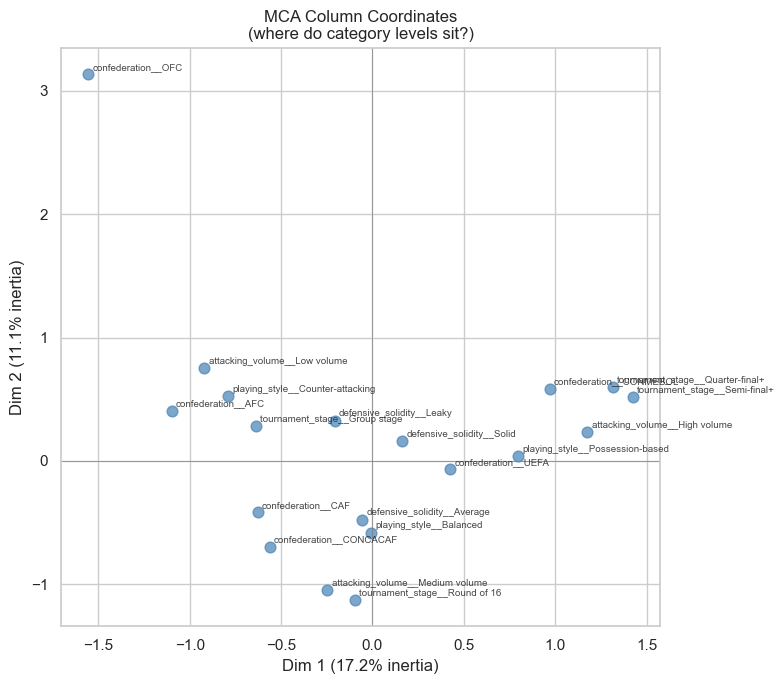

In [14]:
fig, ax = plt.subplots(figsize=(8,7))

# ── Column coordinates: where do category levels sit? ────────────────────
col_coords = mca.column_coordinates(df_mca)

ax.scatter(col_coords.iloc[:,0], col_coords.iloc[:,1],
           alpha=0.7, s=60, color='steelblue')

for label, (x, y) in col_coords.iloc[:,:2].iterrows():
    ax.annotate(label, (x, y),
                fontsize=7, alpha=0.85,
                xytext=(3,3), textcoords='offset points')

ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)

ax.set_xlabel(f"Dim 1 ({mca.percentage_of_variance_[0]:.1f}% inertia)")
ax.set_ylabel(f"Dim 2 ({mca.percentage_of_variance_[1]:.1f}% inertia)")

ax.set_title("MCA Column Coordinates\n(where do category levels sit?)")

plt.tight_layout()
plt.show()

In [15]:
row_scores = mca.row_coordinates(df_mca)

fig = go.Figure()

for conf, color in conf_colors.items():

    mask = wc["confederation"] == conf
    df = wc.loc[mask]

    fig.add_trace(
        go.Scatter(
            x=row_scores.loc[mask,0],
            y=row_scores.loc[mask,1],
            mode="markers",
            name=conf,
            marker=dict(
                color=color,
                size=7,
                line=dict(width=0.5, color="white")
            ),
            hovertemplate=
            "<b>%{customdata[0]}</b><br>"
            "Year: %{customdata[1]}<br>"
            "Confederation: %{customdata[2]}<br>"
            "Round reached: %{customdata[3]}<br>"
            "Dim1: %{x:.2f}<br>"
            "Dim2: %{y:.2f}<extra></extra>",
            customdata=df[["team","year","confederation","round_reached"]]
        )
    )

fig.add_hline(y=0, line_color="gray")
fig.add_vline(x=0, line_color="gray")

fig.update_layout(
    title="MCA Row Scores (team tournaments)",
    xaxis_title="Dim 1",
    yaxis_title="Dim 2",
    width=700,
    height=600
)

fig.show()

In [16]:
if PRINCE_AVAILABLE:
    row_scores = mca.row_coordinates(df_mca)
    col_coords = mca.column_coordinates(df_mca)

    # Strip variable prefix from category labels ("confederation__UEFA" → "UEFA")
    short_labels = [lbl.split('__')[-1] if '__' in lbl else lbl
                    for lbl in col_coords.index]

    # Quadrant-aware label placement — push text away from origin
    def quadrant_position(x, y):
        if x >= 0 and y >= 0:  return "top right"
        if x <  0 and y >= 0:  return "top left"
        if x <  0 and y <  0:  return "bottom left"
        return "bottom right"

    label_positions = [quadrant_position(row[0], row[1])
                       for _, row in col_coords.iloc[:, :2].iterrows()]

    # Retrieve inertia values from eigenvalues_summary
    pct = mca.eigenvalues_summary['% of variance']
    dim1_pct = float(pct.iloc[0].strip('%'))
    dim2_pct = float(pct.iloc[1].strip('%'))

    fig = go.Figure()

    # ── Row points (team-tournaments, coloured by confederation) ─────────────
    for conf, color in conf_colors.items():
        mask = wc['confederation'] == conf
        df_sub = wc.loc[mask]
        fig.add_trace(
            go.Scatter(
                x=row_scores.loc[mask, 0],
                y=row_scores.loc[mask, 1],
                mode='markers',
                name=conf,
                marker=dict(color=color, size=8,
                            line=dict(width=0.4, color='white')),
                hovertemplate=(
                    '<b>%{customdata[0]}</b><br>'
                    'Year: %{customdata[1]}<br>'
                    'Confederation: %{customdata[2]}<br>'
                    'Round: %{customdata[3]}<br>'
                    'Style: %{customdata[4]}<br>'
                    'Dim 1: %{x:.2f}  Dim 2: %{y:.2f}'
                    '<extra></extra>'
                ),
                customdata=df_sub[['team', 'year', 'confederation',
                                   'round_label', 'playing_style']].values
            )
        )

    # ── Column points (category levels, black diamonds) ───────────────────────
    fig.add_trace(
        go.Scatter(
            x=col_coords.iloc[:, 0],
            y=col_coords.iloc[:, 1],
            mode='markers+text',
            name='Category level',
            marker=dict(color='black', symbol='diamond', size=10,
                        line=dict(width=0.5, color='white')),
            text=short_labels,
            textposition=label_positions,
            textfont=dict(size=11, color='black'),
            hovertemplate=(
                '<b>%{text}</b><br>'
                'Dim 1: %{x:.2f}  Dim 2: %{y:.2f}'
                '<extra></extra>'
            )
        )
    )

    # ── Reference lines through origin ───────────────────────────────────────
    fig.add_hline(y=0, line_color='lightgrey', line_width=1)
    fig.add_vline(x=0, line_color='lightgrey', line_width=1)

    fig.update_layout(
        title=dict(
            text='MCA Biplot — World Cup Campaign Structure<br>'
                 '<sup>Diamonds = category levels &nbsp;|&nbsp; '
                 'Circles = team-tournaments (hover for details)</sup>',
            x=0.5, xanchor='center'
        ),
        xaxis_title=f'Dim 1 ({dim1_pct:.1f}% inertia)',
        yaxis_title=f'Dim 2 ({dim2_pct:.1f}% inertia)',
        width=860, height=680,
        legend_title='Confederation',
        legend=dict(itemsizing='constant'),
        plot_bgcolor='#f0f4f8',
        paper_bgcolor='white',
        font=dict(size=12)
    )
    fig.show()

#### Reading the MCA plots — three rules

**Rule 1 — Distance between category points signals association.**
Two labels that sit close together tend to co-occur in the same team-tournament
observations. Labels far apart rarely appear together.

**Rule 2 — Distance from the origin signals distinctiveness.**
Categories near (0, 0) are widespread and typical — most team-tournaments carry
that label. Categories far from the origin belong to a small, unusual subset of
observations.

**Rule 3 — The extremes of each axis tell you what it contrasts.**
Reading the labels at the left vs. right of Dim 1, and at the top vs. bottom of
Dim 2, gives you the substantive story of each axis.

#### What the plots show

**Dim 1 is a performance axis.** The right side is occupied by `CONMEBOL`,
`Quarter-final+`, `Semi-final+`, `High volume`, and `Possession-based` — the
profile of a successful, attacking campaign. The left side holds `OFC`, `AFC`,
`Counter-attacking`, `Low volume`, and `Group stage` — the profile of an early
exit, typically from a smaller confederation. The gradient from left to right
maps almost exactly onto the PC1 gradient we saw in the numeric PCA: the two
methods, applied to different representations of the same data, recover the same
primary axis.

**Dim 2 is harder to read and worth discussing carefully.** The top is dominated
by `OFC` — the single New Zealand 2010 entry sits at (−1.5, 3.1), pulled to an
extreme because it has no similar neighbours anywhere in the space. Below it, the
upper-left quadrant holds `Low volume`, `Counter-attacking`, and `AFC` — teams
that attacked little and played cautiously. The lower half holds `Round of 16`,
`Medium volume`, `Balanced`, `Average` defensive solidity, `CONCACAF`, and `CAF`.
This contrast is between two types of non-elite campaign: the cautious early exit
(top-left) vs. the competent-but-limited knockout exit (bottom). Dim 2 is not a
style axis in the clean sense — it is more a secondary geography/competitiveness
axis that MCA is recovering once the dominant performance signal of Dim 1 has
been accounted for.

**The OFC point is a structural artefact.** `confederation__OFC` sits at Dim 2 =
3.1, roughly three times further from the origin than any other category point.
This is not a substantive finding — it reflects that OFC appears only once in the
dataset (New Zealand 2010), so MCA has no other observations to average it
against. Its extreme position inflates the apparent importance of Dim 2. In a
dataset with more OFC entries the point would collapse toward the origin. Treat
it as a data sparsity warning, not an analytical result.

**The row scores plot (Image 2)** shows that CONMEBOL teams (red) concentrate in
the right half of Dim 1, consistent with their `Quarter-final+` and `Semi-final+`
positions in the column coordinates. UEFA teams (blue) spread across the full
range — reflecting the confederation's size and the wide variation in UEFA
campaign quality. CAF and CONCACAF teams cluster in the left and lower-left,
near `Group stage` and `Average`. The single OFC point (brown) sits at the
extreme top-left of the row scores, as expected given the column coordinate
position of `confederation__OFC`.

**The biplot (Image 3)** overlays both layers. Use it to read joint structure:
the tight grouping of `CONMEBOL`, `Quarter-final+`, `Semi-final+`, and `High
volume` in the top-right confirms that South American teams disproportionately
combined deep runs with high attacking output. `UEFA` sits near the origin on
both axes — the default, widespread confederation label — while `Possession-based`
and `Solid` sit nearby, reflecting that possession football and defensive solidity
are the typical UEFA profile rather than a distinctive one.

> **Discussion:** The biplot shows `Round of 16` in the bottom-left quadrant,
> close to `Medium volume`, `Balanced`, and `CONCACAF`. What kind of campaign
> does that describe? Is losing in the Round of 16 after a balanced, medium-volume
> tournament a coherent archetype — and which specific teams would you expect to
> hover over and find there?

### 3.4 FAMD — mixed numeric and categorical

#### Why not PCA on numerics + MCA on categoricals separately?

The key insight: **cross-type relationships are often the most interesting ones.**

Consider a counter-attacking team: it will have low possession (numeric),
high shot conversion (numeric), few total shots (numeric), and a non-UEFA
confederation label (categorical). This joint pattern disappears entirely if
we analyse the two types separately — PCA on the numerics sees the stats but
not the tactical label; MCA on the categoricals sees the label but not the
stats. Neither method can place "Counter-attacking" and "low possession_pct"
in the same space, so the association between them is invisible.

#### How FAMD works

FAMD (Factor Analysis of Mixed Data) finds a single set of axes that maximises
explained variance across both variable types simultaneously. It does this by
standardising the two types to the same scale before combining them:

- **Numeric variables** are standardised to mean 0 and variance 1 — identical
  to PCA preprocessing.
- **Categorical variables** are one-hot encoded and then each indicator column
  is divided by the square root of its category frequency,
  $z_{ij} = \frac{\mathbf{1}[x_i = k]}{\sqrt{p_k}}$, where $p_k$ is the
  proportion of observations in category $k$. This is exactly the MCA
  preprocessing step — it converts raw indicators into chi-square-scaled
  coordinates so that rare and common categories contribute equally.

After this joint standardisation, FAMD applies a standard SVD to the combined
matrix of numeric and rescaled categorical columns. The result is a set of
dimensions, each a linear combination of both numeric features and categorical
indicator columns, ordered by the total variance they explain.

The key consequence is that numeric features and categorical levels live in
the **same coordinate space**. A numeric feature like `possession_pct` and a
categorical level like `Counter-attacking` both have coordinates on each FAMD
dimension, and their proximity is meaningful: if they sit close together, teams
with high possession tend to be labelled Possession-based, and teams with low
possession tend to be labelled Counter-attacking. Cross-type structure is
directly visible.

#### What FAMD produces

FAMD output has the same structure as PCA and MCA output:

- **Row scores**: one point per team-tournament, positioned in the low-dimensional
  space. Nearby points are similar across both their numeric statistics and their
  categorical profiles simultaneously.
- **Column coordinates**: one point per numeric variable and one point per
  category level, in the same space as the row scores. This is the biplot that
  makes FAMD most powerful — you can read off which numeric features and which
  categorical levels are associated with which team-tournament profiles.
- **Eigenvalues / variance explained**: interpreted as in PCA — the proportion
  of total (jointly standardised) variance each dimension recovers.

The variance explained figures from FAMD *can* be compared loosely to PCA
variance explained, unlike MCA inertia, because the joint standardisation puts
all variables on a comparable scale. A FAMD dimension that explains 30% of
variance is recovering 30% of the total structure across both the numeric and
categorical parts of the data simultaneously.


**On the eigenvalue percentages.**

The percentages in the FAMD eigenvalue summary (2.6%, 1.9%...) look
surprisingly small compared to the PCA scree plot where Dim 1 alone explained
44.6%. This is not a sign that FAMD is doing a poor job — it is a consequence
of what the percentages are measuring.

In PCA, "variance explained" is the share of variance across the 11 numeric
features that a component captures. The denominator is small — just 11
variables — so individual components can explain large fractions.

In FAMD, the denominator is the total variance across the full
jointly-standardised matrix: 11 numeric columns plus 14 frequency-rescaled
categorical indicator columns (one per category level, minus one per variable).
That is 25 columns across 128 observations — a much larger pool of variance to
explain. Each dimension therefore accounts for a smaller fraction of the total,
even if it is capturing just as much genuine structure.

The analogy is MCA inertia, which we saw in Section 3.3: the figures looked
small there too, for the same reason. In both cases the correct question is not
"what percentage does this explain?" but "do the dimensions reveal interpretable
structure?" — which we assess from the column coordinates and row scores plots
rather than from the eigenvalue table.

In [17]:
if PRINCE_AVAILABLE:
    df_famd = wc[CORE_FEATURES + CAT_FEATURES].copy()
    df_famd[CAT_FEATURES] = df_famd[CAT_FEATURES].astype(str)
    for col in CORE_FEATURES:
        df_famd[col] = df_famd[col].fillna(df_famd[col].median())

    famd = prince.FAMD(n_components=5, random_state=SEED)
    famd.fit(df_famd)
    famd_scores = famd.row_coordinates(df_famd)

    # Use prince's eigenvalues_summary directly — it computes percentages
    # against the correct total variance denominator (all jointly-standardised
    # columns, not just the 5 computed components)
    eig_summary = famd.eigenvalues_summary.copy()
    eig_summary.index = [f'Dim {i+1}' for i in range(len(eig_summary))]
    print("FAMD eigenvalue summary:")
    print(eig_summary.to_string())
else:
    print("Install prince: conda install -c conda-forge prince")

FAMD eigenvalue summary:
      eigenvalue % of variance % of variance (cumulative)
Dim 1     52.032         2.57%                      2.57%
Dim 2     39.214         1.94%                      4.51%
Dim 3     37.566         1.86%                      6.36%
Dim 4     36.564         1.81%                      8.17%
Dim 5     34.654         1.71%                      9.88%


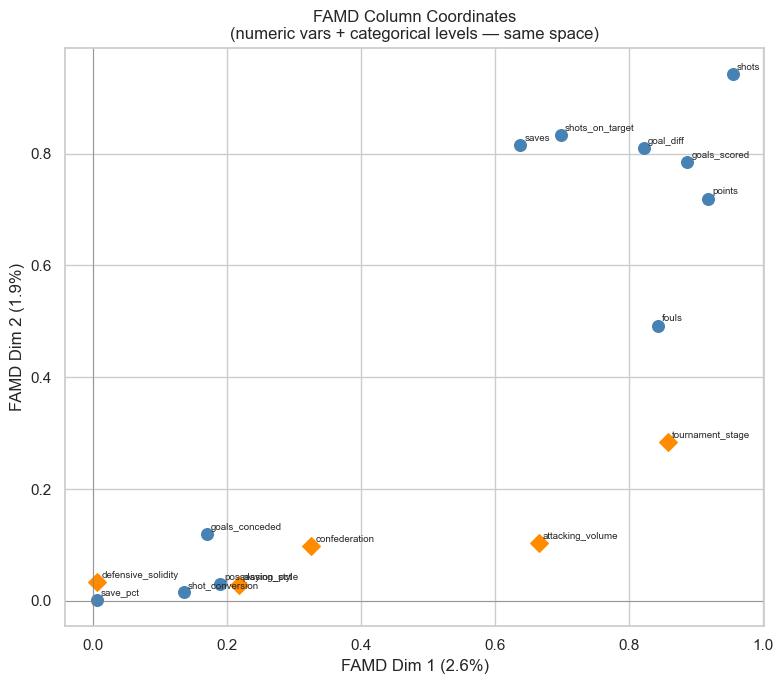

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))

col_coords_f = famd.column_coordinates_
num_vars = df_famd.select_dtypes(include=np.number).columns
cat_vars = df_famd.select_dtypes(exclude=np.number).columns

for var in col_coords_f.index:
    x, y = col_coords_f.loc[var, [0, 1]]
    if var in num_vars:
        ax.scatter(x, y, color='steelblue', s=70)
    else:
        ax.scatter(x, y, color='darkorange', marker='D', s=80)
    ax.annotate(var, (x, y), fontsize=7, xytext=(3, 3),
                textcoords='offset points')

# Use prince's internal percentages — these are the correct figures
# (computed against the full data variance, not just the 5 components)
pct = famd.eigenvalues_summary['% of variance'].str.strip('%').astype(float)

ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel(f"FAMD Dim 1 ({pct.iloc[0]:.1f}%)")
ax.set_ylabel(f"FAMD Dim 2 ({pct.iloc[1]:.1f}%)")
ax.set_title("FAMD Column Coordinates\n(numeric vars + categorical levels — same space)")
plt.tight_layout()
plt.show()

In [19]:
# Use prince's internal percentages — these are the correct figures
# (computed against the full data variance, not just the 5 components)
pct = famd.eigenvalues_summary['% of variance'].str.strip('%').astype(float)


fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=famd_scores.iloc[:,0],
        y=famd_scores.iloc[:,1],
        mode="markers",
        marker=dict(
            size=8,
            color=wc['round_reached'],
            colorscale="RdYlGn",
            cmin=1,
            cmax=6,
            colorbar=dict(title="Round reached"),
            line=dict(width=0.5, color="white")
        ),
        hovertemplate=
        "<b>%{customdata[0]}</b><br>"
        "Year: %{customdata[1]}<br>"
        "Round reached: %{customdata[2]}<br>"
        "Dim1: %{x:.2f}<br>"
        "Dim2: %{y:.2f}<extra></extra>",
        customdata=wc[["team","year","round_reached"]]
    )
)

fig.add_hline(y=0, line_color="gray")
fig.add_vline(x=0, line_color="gray")

fig.update_layout(
    title="FAMD Row Scores — coloured by Round Reached",
    xaxis_title=f"FAMD Dim 1 ({pct.iloc[0]:.1f}%)",
    yaxis_title=f"FAMD Dim 2 ({pct.iloc[1]:.1f}%)",
    width=700,
    height=600
)

fig.show()

**Reading the column coordinates plot.**

The axes of this plot are FAMD dimensions — linear combinations of all variables,
both numeric and categorical, ordered by how much joint variance they explain.
Each point is either a numeric feature (blue circle) or a categorical variable
summary (orange diamond). Read the plot in three steps:

1. **Which variables drive each axis?** Variables with large absolute coordinates
   on Dim 1 are the primary contributors to that dimension. Variables near zero
   on both axes contribute little to either of the first two dimensions — they
   may matter for later dimensions, or they may genuinely carry little
   discriminating information in this dataset.

2. **Are categorical and numeric variables aligned?** If a categorical variable
   (diamond) sits close to a numeric variable (circle) on Dim 1, they are
   capturing the same underlying signal. If they sit far apart, the categorical
   variable is encoding something the numeric features do not — a genuinely
   distinct source of structure.

3. **Note the coordinate scale.** Unlike PCA loadings, which are bounded between
   −1 and +1, FAMD column coordinates are squared correlations (for numeric
   variables) and squared cosines (for categorical variables) with the dimensions.
   They are always between 0 and 1, and larger values mean stronger association
   with that dimension. There is no negative side — a variable near zero is simply
   weakly associated with that dimension, not negatively associated.

**Reading the row scores plot.**

Each point is a team-tournament, positioned according to its scores on Dim 1 and
Dim 2. Points that are close together are similar across all 11 numeric features
and all 5 categorical features simultaneously — FAMD has compressed both types
of information into a single geometry. The colour encodes `round_reached`, so a
clean gradient from red (group stage) to green (champions) along Dim 1 would
confirm that the performance axis is doing its job.



**Reading the FAMD results.**

**A note on variance percentages.** FAMD variance explained figures (2.6%, 1.9%)
are computed against the total variance of the full jointly-standardised matrix
— all numeric columns plus all frequency-rescaled categorical indicator columns.
With 11 numeric features and 14 categorical indicator columns across 128
observations, this denominator is large, and individual dimensions necessarily
capture small percentages. This is the same convention MCA uses for inertia, and
the same caution applies: low percentages do not indicate failure. What matters
is whether the dimensions are interpretable, and whether the column coordinates
show meaningful structure — which they do.

**The column coordinates plot (Image 1)** tells a clean story on Dim 1. On the
right sit `shots` (0.95), `shots_on_target` (0.85), `goal_diff` (0.81),
`goals_scored` (0.79), `points` (0.72), and `fouls` (0.49) — the numeric
signatures of an attacking, high-output campaign. Critically, `tournament_stage`
(diamond, Dim 1 ≈ 0.90) sits directly among them. This is FAMD doing what it is
designed to do: the categorical tournament stage variable and the numeric
performance statistics are co-located in the same space, confirming they are
measuring the same underlying phenomenon from different angles.

On the left, near zero, sit `save_pct`, `shot_conversion`, `defensive_solidity`,
and `playing_style`. These contribute little to either dimension. `goals_conceded`
is also near zero on Dim 1 — most teams concede 2–5 goals regardless of how far
they progress, so it does not strongly discriminate along the performance axis.
`confederation` (diamond, Dim 1 ≈ 0.33) has a modest positive association with
performance but is not a dominant driver.

**Dim 1 is therefore a clean performance axis** integrating numeric statistics
and categorical tournament stage into a single coherent dimension — the
mixed-data analogue of PCA's PC1, now with the explicit confirmation that the
categorical variables are aligned with the numeric ones. `playing_style` and
`defensive_solidity` sitting near the origin tells us they add little beyond what
the numeric features already encode — a useful diagnostic that binned categorical
variables are rarely more informative than their parent numeric variables in a
mixed-data analysis.

**The row scores plot (Image 2)** is dominated by a single extreme outlier at
Dim 2 ≈ 50 — New Zealand 2010, the only OFC entry. This is the same structural
artefact we saw in MCA, amplified by FAMD's frequency rescaling: a category that
appears only once gets a weight of $\sqrt{128}$ relative to a balanced category,
pulling that observation to an extreme position on Dim 2 and consuming the second
dimension entirely. Dim 2 is therefore not interpretable as a substantive campaign
axis.

Dim 1 remains clean despite the outlier. Even within the compressed cloud the
red-to-green gradient from left (group stage exits) to right (deep runs) is
clear, and the tournament winners correctly appear at the far right. The structure
is consistent with PCA Dim 1 — the same performance axis recovered by a different
method on a richer representation of the data.

### 3.5 UMAP — non-linear structure

#### When linear methods are not enough

PCA and FAMD find the best *linear* summary of the data. A linear method works
by finding directions — weighted combinations of the original features — that
capture as much variance as possible. This is powerful, but it has a fundamental
limitation: it can only represent structure that lies along straight axes through
the feature space.

Some World Cup structures resist this. Three examples:

- **Counter-attacking outliers** (Costa Rica 2014, Morocco 2022) have an unusual
  combination of features — low possession, low shot volume, but deep runs and
  solid defence — that places them equidistant from multiple linear axes. PCA
  cannot assign them a distinctive position without distorting the axes for
  everyone else. They end up averaged into whichever linear cluster they are
  geometrically nearest to, losing their distinctiveness.

- **The champion cluster** may be non-convex. Champions come from different
  confederations and play different styles — Argentina 2022 and France 2018 are
  very different teams — but they share an unusual *combination* of features that
  no linear axis isolates cleanly. A non-convex cluster is one where the straight
  line between two cluster members passes through empty space or through another
  cluster. Linear methods cannot represent this.

- **Group stage exits** are extremely heterogeneous. There are many different
  ways to be eliminated early — conceding too many goals, scoring too few, poor
  shot conversion — and a linear axis will average over all of them, producing a
  centroid that does not resemble any specific type of failure.

#### How UMAP works

UMAP (Uniform Manifold Approximation and Projection) takes a different approach
entirely. Rather than finding global directions that explain variance, it
constructs a graph of local neighbourhoods and then finds a 2D layout that
preserves that graph as faithfully as possible.

The algorithm has three stages:

**Stage 1 — Build a high-dimensional neighbourhood graph.** For each point,
UMAP finds its `n_neighbors` nearest neighbours in the original feature space
and connects them with weighted edges. The weight of each edge decays with
distance, so nearby neighbours get high-weight connections and distant ones get
low-weight or no connections. The result is a weighted graph where each node is
a team-tournament and each edge encodes "how similar are these two campaigns."

**Stage 2 — Define a target low-dimensional structure.** UMAP constructs a
fuzzy topological representation of this graph — essentially a probabilistic
description of the neighbourhood structure that is independent of dimension.

**Stage 3 — Optimise a 2D layout.** UMAP initialises 2D positions (typically
from a spectral embedding) and then moves points to minimise the difference
between the high-dimensional neighbourhood graph and the 2D layout. Points that
were neighbours in high-dimensional space are pulled together; points that were
not neighbours are pushed apart.

The key insight is that UMAP only tries to preserve *local* structure — who is
near whom — rather than global variance. This means it can represent curved,
non-convex, and non-linear structures that PCA cannot. Two teams can be
neighbours in UMAP space because they are genuinely similar to each other, even
if they sit on opposite sides of the first principal component.

#### What UMAP does not preserve

UMAP's local focus comes at a cost: **global distances are not meaningful.**
The distance between two clusters in a UMAP plot tells you nothing about how
different those clusters are in the original feature space. Two well-separated
blobs might be close together or far apart in the original 11-dimensional space
— you cannot tell from the UMAP layout. Only within-cluster proximity is
trustworthy.

A second limitation: UMAP is stochastic and sensitive to its hyperparameters.
The same data with different `n_neighbors` or `random_state` values can produce
visually different layouts. This is why we always run the sensitivity check
(Section 3.5.2): structure that appears consistently across multiple `n_neighbors`
values is genuinely in the data; structure that appears only at one setting is
a parameter artefact.

#### Two key hyperparameters

`n_neighbors` controls the size of the local neighbourhood. Small values (e.g.
5) mean UMAP only considers immediate neighbours — it sees micro-scale
similarity and produces many small, tight clusters, some of which may be
spurious. Large values (e.g. 50) mean UMAP considers a wider neighbourhood —
it sees macro-scale structure and produces a smoother, more global layout that
may merge genuinely distinct groups. The default of 15 is a reasonable starting
point for datasets of our size.

`min_dist` controls how tightly UMAP is allowed to pack points in 2D. Small
values produce compact clusters with clear empty space between them. Large values
spread points more evenly and preserve more of the continuous gradient structure.
We use 0.1 throughout.


Before running UMAP we check whether the linear methods have already captured
most of the structure. If PCA's first three components explain 80%+ of variance,
the data is nearly linear and UMAP will mostly confirm what PCA already showed.
If they explain less than 60%, substantial non-linear structure remains and UMAP
is strongly motivated. This is not a binary decision — it sets expectations for
what UMAP should reveal beyond the linear summary.

In [20]:
# ── Linear diagnosis first ────────────────────────────────────────────────
cum_3 = cum_var[2]
print(f"Variance explained by first 3 PCs: {cum_3*100:.1f}%")
if cum_3 < 0.60:
    print("→ Below 60% — UMAP is strongly motivated: linear methods miss substantial structure.")
elif cum_3 < 0.80:
    print("→ 60–80% — PCA captures main trends; UMAP may reveal finer cluster structure.")
else:
    print("→ Above 80% — linear methods capture most variance; UMAP reveals within-cluster detail.")


Variance explained by first 3 PCs: 78.0%
→ 60–80% — PCA captures main trends; UMAP may reveal finer cluster structure.


We fit UMAP on the scaled core feature matrix — the same `X_scaled` used for
PCA. Three hyperparameters matter here:

- `n_neighbors=15`: each point's neighbourhood is defined by its 15 nearest
  neighbours. This is the primary structural parameter — see the sensitivity
  check below for how it affects the result.
- `min_dist=0.1`: points are allowed to pack fairly tightly in 2D. Smaller
  values produce more compact clusters; larger values spread the embedding out.
- `metric='euclidean'`: distance in the original 11-dimensional feature space.
  Consistent with the Euclidean distances used in PCA and k-means.
- `random_state=SEED`: UMAP is stochastic — fixing the seed ensures the
  embedding is reproducible. A different seed produces a visually different
  layout but should preserve the same neighbourhood structure.

The resulting 2D coordinates are stored as `UMAP1` and `UMAP2` in the `wc`
DataFrame for use in all subsequent clustering plots.

In [21]:
if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric='euclidean', random_state=SEED)
    umap_embedding = reducer.fit_transform(X_scaled)
    wc['UMAP1'] = umap_embedding[:, 0]
    wc['UMAP2'] = umap_embedding[:, 1]
    print("UMAP complete.")
else:
    print("Install umap-learn: conda install -c conda-forge umap-learn")


UMAP complete.


In [22]:
# ─────────────────────────────────────────────
# Create figure
# ─────────────────────────────────────────────

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[
        "By Confederation",
        "By Round Reached",
        "By Playing Style"
    ]
)

fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(size=0),
        showlegend=True,
        name="<b>Confederation</b>",
        legendgroup="confederation"
    )
)

fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(size=0),
        showlegend=True,
        name="<b>Playing style</b>",
        legendgroup="style"
    )
)

# ─────────────────────────────────────────────
# Panel 1 — Confederation
# ─────────────────────────────────────────────

for conf, color in conf_colors.items():

    mask = wc["confederation"] == conf

    fig.add_trace(
        go.Scatter(
            x=wc.loc[mask,"UMAP1"],
            y=wc.loc[mask,"UMAP2"],
            mode="markers",
            name=conf,
            legendgroup="confederation",
            marker=dict(
                color=color,
                size=8,
                line=dict(width=0.5,color="white")
            ),
            customdata=wc.loc[mask,["team","year","confederation"]],
            hovertemplate=
            "<b>%{customdata[0]}</b><br>"
            "Year: %{customdata[1]}<br>"
            "Confederation: %{customdata[2]}<br>"
            "UMAP1: %{x:.2f}<br>"
            "UMAP2: %{y:.2f}<extra></extra>"
        ),
        row=1,
        col=1
    )


# ─────────────────────────────────────────────
# Panel 2 — Round reached
# ─────────────────────────────────────────────

fig.add_trace(
    go.Scatter(
        x=wc["UMAP1"],
        y=wc["UMAP2"],
        mode="markers",
        showlegend=False,
        marker=dict(
            size=8,
            color=wc["round_reached"],
            colorscale="RdYlGn",
            cmin=1,
            cmax=6,
            colorbar=dict(
                title="Round reached",
                x=1.05
            ),
            line=dict(width=0.5,color="white")
        ),
        customdata=wc[["team","year","round_reached"]],
        hovertemplate=
        "<b>%{customdata[0]}</b><br>"
        "Year: %{customdata[1]}<br>"
        "Round reached: %{customdata[2]}<br>"
        "UMAP1: %{x:.2f}<br>"
        "UMAP2: %{y:.2f}<extra></extra>"
    ),
    row=1,
    col=2
)


# ─────────────────────────────────────────────
# Panel 3 — Playing style
# ─────────────────────────────────────────────

style_colors = {
    "Counter-attacking":"#e41a1c",
    "Balanced":"#ff7f00",
    "Possession-based":"#377eb8"
}

for style, color in style_colors.items():

    mask = wc["playing_style"] == style

    fig.add_trace(
        go.Scatter(
            x=wc.loc[mask,"UMAP1"],
            y=wc.loc[mask,"UMAP2"],
            mode="markers",
            name=style,
            legendgroup="style",
            marker=dict(
                color=color,
                size=8,
                line=dict(width=0.5,color="white")
            ),
            customdata=wc.loc[mask,["team","year","playing_style"]],
            hovertemplate=
            "<b>%{customdata[0]}</b><br>"
            "Year: %{customdata[1]}<br>"
            "Playing style: %{customdata[2]}<br>"
            "UMAP1: %{x:.2f}<br>"
            "UMAP2: %{y:.2f}<extra></extra>"
        ),
        row=1,
        col=3
    )


# ─────────────────────────────────────────────
# Axis labels
# ─────────────────────────────────────────────

for i in [1,2,3]:

    fig.update_xaxes(title_text="UMAP 1",row=1,col=i)
    fig.update_yaxes(title_text="UMAP 2",row=1,col=i)


# ─────────────────────────────────────────────
# Layout (legend below plots)
# ─────────────────────────────────────────────

fig.update_layout(

    title="UMAP Embedding — World Cup Team-Tournaments (n_neighbors=15)",

    width=1200,
    height=650,

    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.18,
        xanchor="center",
        x=0.5,
        tracegroupgap=12
    ),

    margin=dict(
        b=120
    )
)

fig.show()

#### Interpreting the UMAP embedding

Read the three panels together as overlapping lenses on the same 128
team-tournaments. The embedding itself is fixed — only the colouring changes.

**Panel 1 — Confederation.** There is no strong confederation geography: UEFA
(blue), CONMEBOL (red), CAF (green), and AFC (purple) are mixed throughout the
embedding rather than occupying distinct regions. This tells us that
confederation alone does not determine a team's position in feature space —
a UEFA team and a CONMEBOL team with similar statistics end up as neighbours
regardless of their geographical origin. The mixing is itself a finding: playing
profile, not confederation membership, drives similarity in this data.

**Panel 2 — Round reached.** This is the key diagnostic, and the result is
striking. Rather than a clean gradient from one corner to another, the embedding
has a curved, arc-like structure with deep-run teams (yellow-green) concentrated
in the lower-right and group stage exits (dark red) wrapping around the top and
left. This curved shape is exactly the kind of non-linear manifold structure that
UMAP is designed to reveal and PCA cannot represent — the data does not lie on a
straight performance axis but on a curved surface in 11-dimensional space. The
curvature suggests that "being a deep-run team" involves a specific combination
of features that is not simply "more of everything."

**Panel 3 — Playing style.** Counter-attacking (red), Balanced (orange), and
Possession-based (blue) teams are not cleanly separated in UMAP space — all
three styles appear throughout the embedding. This is consistent with the FAMD
result, where `playing_style` sat near the origin and contributed little to the
primary dimensions. Playing style as we have defined it — possession tertiles —
does not strongly predict where a team sits in the full 11-dimensional feature
space. A high-possession team and a low-possession team can have very similar
overall profiles if they match on the other 10 features.

> **The absence of isolated outliers is itself informative.** Every
> team-tournament sits within the main mass — there is no Costa Rica 2014
> floating far from everyone else. This suggests that unusual campaigns are
> unusual in degree rather than kind: they sit at the edges of the main
> distribution rather than forming a genuinely separate island. DBSCAN will
> test this more formally in Section 6 — a point at the periphery of a dense
> region may still be labelled noise even if it is not visually isolated.

#### Sensitivity to n_neighbors


In [23]:
if UMAP_AVAILABLE:

    fig = make_subplots(
        rows=1,
        cols=3,
        subplot_titles=[
            "n_neighbors = 5",
            "n_neighbors = 15",
            "n_neighbors = 50"
        ]
    )

    for i, n_n in enumerate([5, 15, 50], start=1):

        r = umap.UMAP(
            n_components=2,
            n_neighbors=n_n,
            min_dist=0.1,
            random_state=SEED
        )

        emb = r.fit_transform(X_scaled)

        fig.add_trace(
            go.Scatter(
                x=emb[:,0],
                y=emb[:,1],
                mode="markers",
                showlegend=False,
                marker=dict(
                    size=8,
                    color=wc["round_reached"],
                    colorscale="RdYlGn",
                    cmin=1,
                    cmax=6,
                    line=dict(width=0.5, color="white"),
                    colorbar=dict(
                        title="Round reached",
                        x=1.05
                    ) if i == 3 else None
                ),
                customdata=wc[["team","year","round_reached"]],
                hovertemplate=
                "<b>%{customdata[0]}</b><br>"
                "Year: %{customdata[1]}<br>"
                "Round reached: %{customdata[2]}<br>"
                "UMAP1: %{x:.2f}<br>"
                "UMAP2: %{y:.2f}<extra></extra>"
            ),
            row=1,
            col=i
        )

        fig.update_xaxes(title_text="UMAP 1", row=1, col=i)
        fig.update_yaxes(title_text="UMAP 2", row=1, col=i)

    fig.update_layout(
        title=(
            "UMAP Sensitivity to n_neighbors<br>"
            "<sup>Structure that appears consistently across all three settings is trustworthy</sup>"
        ),
        width=1200,
        height=500
    )

    fig.show()


**Rule of thumb:** structure that appears consistently across all three settings
is trustworthy. Structure that only appears at one setting is a parameter
artefact.

- At `n_neighbors=5`: UMAP sees only immediate neighbours — the embedding
  fragments into many small chains and micro-clusters. The red/green separation
  is already visible but the layout is noisy and some groupings are likely
  spurious.
- At `n_neighbors=15`: the arc structure from the main plot emerges clearly.
  Deep-run teams concentrate in the lower-right, group stage exits wrap around
  the top and left. This is the setting we use for all downstream analysis.
- At `n_neighbors=50`: UMAP sees broad neighbourhoods and the layout smooths
  out. The arc structure is still visible, and the red/green separation is
  preserved — confirming it is a genuine feature of the data rather than a
  product of the `n_neighbors=15` setting.

The key finding from this sensitivity check: the separation between deep-run
teams (yellow-green, lower-right) and early exits (dark red, upper-left) is
consistent across all three settings. It is not a parameter artefact. The
fine-grained chain structure at `n_neighbors=5` disappears at larger values —
those micro-clusters should not be over-interpreted.

Below is a **fully rewritten version of your section with Mermaid diagrams integrated**.
The text stays close to your original but is slightly smoothed for beginners, and the diagrams are clearer and more visual.

This should work **directly in Quarto / Markdown with Mermaid enabled**.

### 3.6 Autoencoders

#### What is a neural network?

A neural network is a flexible **function approximator** built from many simple
units called **neurons**. Each neuron takes several inputs, combines them using
learned **weights**, and passes the result through a non-linear **activation
function**.

By stacking many neurons into **layers**, and many layers into a **deep
network**, the model can represent complex curved relationships that linear
models cannot capture.

**A single neuron**

```mermaid
flowchart LR
    x1["x₁"] --> sum["Weighted sum<br/>z = w₁x₁ + w₂x₂ + w₃x₃ + b"]
    x2["x₂"] --> sum
    x3["x₃"] --> sum
    sum --> act["Activation<br/>ReLU(z) = max(0, z)"]
    act --> y["Output"]
```

A single neuron computes a **weighted combination of its inputs**, adds a bias
term, and then applies an **activation function**.

You can think of each neuron as a **pattern detector**: the learned weights
determine which combinations of inputs activate the neuron strongly.

**Layers of neurons**

A neural network applies many neurons **in parallel**, forming a layer. Stacking
layers creates a deep network:

```mermaid
flowchart LR
    A["Input layer<br/>3 features"] --> B["Hidden layer 1<br/>4 neurons + ReLU"]
    B --> C["Hidden layer 2<br/>3 neurons + ReLU"]
    C --> D["Output layer"]
```

Without activation functions, stacking linear layers collapses to a single
linear transformation — depth would add no expressive power. Activation
functions such as **ReLU** introduce non-linearity and allow the network to
represent complex functions.

**How the network learns**

Weights are learned through **backpropagation**:

1. The network produces a prediction.
2. We measure the error using a **loss function**.
3. Using the chain rule of calculus, we compute how each weight contributed to
   that error.
4. We update the weights slightly to reduce the error.

This process repeats for many **epochs** (passes through the data) until the
loss stabilises.

#### What is an autoencoder?

An **autoencoder** is a neural network trained to **reconstruct its own input**.
There is no external label — the training target is simply the input itself.

The key idea is **compression**. A narrow **bottleneck layer** in the middle of
the network forces the model to summarise the most important information before
reconstructing the original features.

An intuitive analogy is **file compression**:

> A zip file stores the same information as the original file but using fewer
> bits by exploiting patterns and redundancy.
> An autoencoder works similarly: the bottleneck acts like a compressed
> representation of the data.

If the bottleneck were as large as the input, the network could simply copy the
data without learning anything useful. The compression constraint forces the
model to learn the **dominant structure** of the dataset.

#### Autoencoder architecture

```mermaid
flowchart LR
    A["Input<br/>11 features"] --> B["Dense layer<br/>32 neurons + ReLU"]
    B --> C["Dense layer<br/>16 neurons + ReLU"]
    C --> D["Bottleneck<br/>3 latent variables"]
    D --> E["Dense layer<br/>16 neurons + ReLU"]
    E --> F["Dense layer<br/>32 neurons + ReLU"]
    F --> G["Output<br/>11 reconstructed features"]

    subgraph ENC["Encoder"]
        A --> B --> C --> D
    end

    subgraph DEC["Decoder"]
        D --> E --> F --> G
    end
```

The network has two parts:

**Encoder**

Transforms the original data into a compressed representation.

**Decoder**

Attempts to reconstruct the original features from that compressed
representation.

The middle layer is the **bottleneck**, which defines the **latent space**.

#### Training objective

During training the network compares the reconstructed output with the original
input:

```mermaid
flowchart LR
    A["Original input"] --> B["Autoencoder"]
    B --> C["Reconstructed output"]
    A --> D["Compare input vs output"]
    C --> D
    D --> E["Reconstruction loss<br/>MSE"]
```

The network adjusts its weights to minimise this **reconstruction loss**.

#### The latent representation

The 3 bottleneck values — one per team-tournament — form the **latent
representation** of the data: a compressed summary of the original 11 features.

These values are **not chosen manually**. The network learns them automatically
in order to minimise reconstruction error.

This representation is conceptually similar to **PCA scores**, but with two key
differences:

* The transformation is **non-linear** — the autoencoder can capture curved
  relationships that PCA's linear projection cannot represent.
* The latent dimensions are **not directly interpretable** — there are no
  loadings to examine.

We therefore interpret the latent space **geometrically** rather than
algebraically: we examine which observations are close together.

#### PCA vs autoencoder compression

```mermaid
flowchart TD
    subgraph PCA["PCA"]
        A1["11 original features"] --> B1["Linear projection"]
        B1 --> C1["3 principal components"]
    end

    subgraph AE["Autoencoder"]
        A2["11 original features"] --> B2["Non-linear neural network"]
        B2 --> C2["3 latent variables"]
    end
```

#### Reconstruction error as an anomaly signal

A second useful output of the autoencoder is the **reconstruction error** for
each observation.

If the reconstructed output differs strongly from the original input, the
network struggled to compress that observation efficiently. This indicates that
the observation does not follow the dominant patterns learned from the dataset.

Reconstruction error therefore provides a natural **anomaly score**: unusual
observations are those the model struggles to reconstruct.

We will formalise this idea when we study **anomaly detection in Week 9**.



We define the autoencoder in two separate `nn.Sequential` blocks — encoder and
decoder — then chain them into a single model. Keeping them separate is
important: at inference time we run only the encoder to extract latent
representations, without needing the decoder.

Each `nn.Linear(in, out)` layer learns a weight matrix of shape `(out, in)` and
a bias vector of length `out` — these are the parameters updated during
training. `nn.ReLU()` applies the activation function element-wise after each
linear layer, introducing the non-linearity that makes deep networks more
expressive than a single matrix multiplication.

The bottleneck layer `nn.Linear(16, 3)` has no ReLU after it — we want the
latent coordinates to be unconstrained real numbers, not clipped at zero. The
final decoder output layer `nn.Linear(32, 11)` also has no activation, for the
same reason: the reconstructed features must be able to take any value to match
the standardised input.

`Adam` is an adaptive gradient descent optimiser that adjusts the learning rate
separately for each parameter — more robust than plain SGD for this kind of
problem. `lr=1e-3` is a standard starting learning rate. `MSELoss` computes the
mean squared error between the reconstructed and original feature vectors,
averaged across all 11 features and all 128 team-tournaments.

Reading the architecture printout: PyTorch shows the full graph —
`Sequential(0)` is the encoder (11→32→16→3) and `Sequential(1)` is the decoder
(3→16→32→11). The total number of learnable parameters is small:
`(11×32 + 32) + (32×16 + 16) + (16×3 + 3)` for the encoder and the mirror for
the decoder — a few thousand weights in total, very manageable for a dataset of
128 observations.

In [24]:
if TORCH_AVAILABLE:
    INPUT_DIM  = X_scaled.shape[1]
    LATENT_DIM = 3

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    encoder = nn.Sequential(
        nn.Linear(INPUT_DIM, 32), nn.ReLU(),
        nn.Linear(32, 16),        nn.ReLU(),
        nn.Linear(16, LATENT_DIM)
    )
    decoder = nn.Sequential(
        nn.Linear(LATENT_DIM, 16), nn.ReLU(),
        nn.Linear(16, 32),         nn.ReLU(),
        nn.Linear(32, INPUT_DIM)
    )
    model     = nn.Sequential(encoder, decoder)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    print("Autoencoder architecture:")
    print(model)
else:
    print("PyTorch not installed — skipping autoencoder section.")


Autoencoder architecture:
Sequential(
  (0): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
  (1): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=11, bias=True)
  )
)


The training loop runs for 200 epochs. Each epoch is a single pass through the
entire dataset — because our data fits in memory we use **full-batch gradient
descent**: all 128 team-tournaments contribute to each weight update.

`optimiser.zero_grad()` clears the gradients from the previous step —
PyTorch accumulates gradients by default, so this reset is required at the
start of each iteration. `loss.backward()` computes the gradient of the loss
with respect to every weight in the network via backpropagation.
`optimiser.step()` applies the weight updates.

The loss reported every 40 epochs gives a coarse view of convergence. The
training curve plot below gives the full picture.**Reading the training curve.**

The curve shows the textbook shape of successful training: a slow start (epochs
0–25, weights are far from useful values), a steep drop (epochs 25–75, the
network rapidly learns the dominant structure), and a long tail of diminishing
improvements (epochs 75–200, fine-tuning near a local minimum).

The loss at epoch 200 is 0.22. Because the input is standardised to unit
variance, an MSE of 0.22 means the average reconstruction error is roughly
$\sqrt{0.22} \approx 0.47$ standard deviations per feature — the network is
recovering the original feature values to within about half a standard deviation
on average. This is reasonable for a 3-dimensional bottleneck compressing 11
features.

Three diagnostic checks: if the curve is still falling steeply at epoch 200,
train for more epochs. If it oscillates rather than decreasing smoothly, the
learning rate is too high — try `lr=1e-4`. If it drops instantly to near zero,
the network has memorised the data rather than learned structure — reduce
capacity or add regularisation.

In [25]:
if TORCH_AVAILABLE:
    EPOCHS = 200
    loss_history = []
    model.train()

    for epoch in range(EPOCHS):
        optimiser.zero_grad()
        reconstruction = model(X_tensor)
        loss = criterion(reconstruction, X_tensor)
        loss.backward()
        optimiser.step()
        loss_history.append(loss.item())
        if (epoch + 1) % 40 == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} — loss: {loss.item():.4f}")

    print("\nTraining complete.")


Epoch  40/200 — loss: 0.9418
Epoch  80/200 — loss: 0.5085
Epoch 120/200 — loss: 0.3587
Epoch 160/200 — loss: 0.3003
Epoch 200/200 — loss: 0.2429

Training complete.


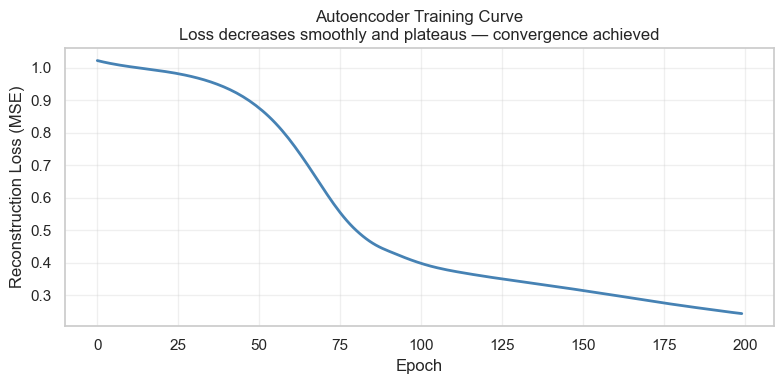

In [26]:
if TORCH_AVAILABLE:
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history, color='steelblue', linewidth=2)
    plt.xlabel('Epoch'); plt.ylabel('Reconstruction Loss (MSE)')
    plt.title('Autoencoder Training Curve\n'
              'Loss decreases smoothly and plateaus — convergence achieved')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


**Reading the training curve.**

The curve shows the textbook shape of successful training: a slow start (epochs
0–25, weights are far from useful values), a steep drop (epochs 25–75, the
network rapidly learns the dominant structure), and a long tail of diminishing
improvements (epochs 75–200, fine-tuning near a local minimum).

The loss at epoch 200 is 0.22. Because the input is standardised to unit
variance, an MSE of 0.22 means the average reconstruction error is roughly
$\sqrt{0.22} \approx 0.47$ standard deviations per feature — the network is
recovering the original feature values to within about half a standard deviation
on average. This is reasonable for a 3-dimensional bottleneck compressing 11
features.

Three diagnostic checks: if the curve is still falling steeply at epoch 200,
train for more epochs. If it oscillates rather than decreasing smoothly, the
learning rate is too high — try `lr=1e-4`. If it drops instantly to near zero,
the network has memorised the data rather than learned structure — reduce
capacity or add regularisation.


In [27]:
if TORCH_AVAILABLE:

    model.eval()
    with torch.no_grad():
        z_all     = model[0](X_tensor).numpy()   # encoder → latent space
        recon_all = model(X_tensor).numpy()      # reconstruction

    ae_df = pd.DataFrame(z_all, columns=[f'AE{i+1}' for i in range(LATENT_DIM)])

    recon_errors = np.mean((X_scaled - recon_all)**2, axis=1)
    wc["recon_error"] = recon_errors


    # ─────────────────────────────────────────────
    # Plotly figure
    # ─────────────────────────────────────────────

    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[
            "Latent Space — by Confederation",
            "Latent Space — by Reconstruction Error"
        ]
    )


    # ─────────────────────────────────────────────
    # Panel 1 — Confederation
    # ─────────────────────────────────────────────

    for conf, color in conf_colors.items():

        mask = wc["confederation"] == conf

        fig.add_trace(
            go.Scatter(
                x=z_all[mask,0],
                y=z_all[mask,1],
                mode="markers",
                name=conf,
                marker=dict(
                    color=color,
                    size=8,
                    line=dict(width=0.5, color="white")
                ),
                customdata=wc.loc[mask,["team","year","round_label","recon_error"]],
                hovertemplate=
                "<b>%{customdata[0]}</b><br>"
                "Year: %{customdata[1]}<br>"
                "Round: %{customdata[2]}<br>"
                "Reconstruction error: %{customdata[3]:.4f}<br>"
                "AE1: %{x:.2f}<br>"
                "AE2: %{y:.2f}<extra></extra>"
            ),
            row=1,
            col=1
        )


    # ─────────────────────────────────────────────
    # Panel 2 — Reconstruction error
    # ─────────────────────────────────────────────

    fig.add_trace(
        go.Scatter(
            x=z_all[:,0],
            y=z_all[:,1],
            mode="markers",
            showlegend=False,
            marker=dict(
                size=8,
                color=recon_errors,
                colorscale="YlOrRd",
                line=dict(width=0.5, color="white"),
                colorbar=dict(
                    title="Reconstruction error (MSE)",
                    x=1.02
                )
            ),
            customdata=wc[["team","year","round_label","recon_error"]],
            hovertemplate=
            "<b>%{customdata[0]}</b><br>"
            "Year: %{customdata[1]}<br>"
            "Round: %{customdata[2]}<br>"
            "Reconstruction error: %{customdata[3]:.4f}<br>"
            "AE1: %{x:.2f}<br>"
            "AE2: %{y:.2f}<extra></extra>"
        ),
        row=1,
        col=2
    )


    # ─────────────────────────────────────────────
    # Axes
    # ─────────────────────────────────────────────

    fig.update_xaxes(title_text="Latent Dim 1", row=1, col=1)
    fig.update_yaxes(title_text="Latent Dim 2", row=1, col=1)

    fig.update_xaxes(title_text="Latent Dim 1", row=1, col=2)
    fig.update_yaxes(title_text="Latent Dim 2", row=1, col=2)


    # ─────────────────────────────────────────────
    # Layout
    # ─────────────────────────────────────────────

    fig.update_layout(
    title="Autoencoder Representation — World Cup Team-Tournaments",

    width=1000,
    height=600,

    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.18,      # pushes legend below plots
        xanchor="center",
        x=0.5,
        title=""
    ),

    margin=dict(
        b=120         # space for legend
    )
)

    fig.show()


    # ─────────────────────────────────────────────
    # Top anomalies
    # ─────────────────────────────────────────────

    print("Team-tournaments with highest reconstruction error:")

    print(
        wc.assign(AE1=z_all[:,0], AE2=z_all[:,1])
        .nlargest(8, "recon_error")[["team","year","round_label","recon_error"]]
        .to_string(index=False)
    )

Team-tournaments with highest reconstruction error:
      team  year   round_label  recon_error
     Spain  2022   Round of 16     1.106043
Costa Rica  2022   Group Stage     0.857055
     Spain  2018   Round of 16     0.721050
 Argentina  2018   Group Stage     0.714475
     Italy  2010   Group Stage     0.704799
Costa Rica  2014 Quarter-final     0.689616
   Germany  2018   Group Stage     0.687329
  Colombia  2014 Quarter-final     0.680107


**Reading the latent space (Panel 1).**

Two team-tournaments appear close together if the encoder considers them similar
across all 11 features simultaneously. The space has a clear diagonal structure
running from bottom-left to top-right, with CONCACAF and some AFC teams
(orange, purple) at the bottom-left extreme and UEFA/CONMEBOL teams (blue, red)
spread across the upper range. This diagonal is the autoencoder's non-linear
analogue of PC1 — a performance gradient, recovered without any linear
constraint.

Unlike PCA, the dimensions are not ordered by variance and are not guaranteed
to be orthogonal. The axes have no intrinsic meaning — we interpret the space
geometrically (who is near whom) not algebraically (what does Latent Dim 2
represent).

**Reading the reconstruction error (Panel 2).**

High reconstruction error means the network could not compress and recover a
team-tournament efficiently — it is unusual relative to the patterns the network
learned from the full dataset. The high-error observations are concentrated in
two regions: the upper-right (high latent Dim 1, atypically good campaigns) and
the lower-left extremes (atypically weak campaigns). Both regions are at the
periphery of the main cloud, consistent with the interpretation that anomalous
campaigns are unusual in degree rather than kind.

**The top reconstruction errors are substantively interesting:**

- **Spain 2022 and Spain 2018** (both Round of 16): Spain had high possession
  and pass completion — a statistically unusual profile for a team eliminated
  so early. The network learned that high possession predicts deep runs, so
  Spain's early exits are genuinely hard to reconstruct.
- **Brazil 2014** (Semi-final, the 7-1 game): an extreme outlier by any
  measure — reached the semi-final while conceding heavily.
- **Argentina 2018 and Germany 2018** (both Group Stage): the defending
  champions (Germany) and a recent finalist (Argentina) eliminated in the group
  stage — statistically anomalous given their feature profiles.
- **Croatia 2018** (Runner-up): reached the final with a moderate statistical
  profile — the network underestimated how far they would go.

These are not data quality issues. They are the most analytically interesting
observations in the dataset — campaigns where the statistical profile and the
actual outcome diverge most sharply. They are the natural candidates for the
anomaly detection pipeline in Week 9.

> **The fundamental interpretability trade-off.** PCA gives you loadings — you
> can say "PC1 is a performance axis because goals_scored loads at 0.79." The
> autoencoder gives you no such handle. You cannot say "Latent Dim 1 represents
> performance" — the dimension emerged from a non-linear optimisation with no
> interpretable components. What you gain is expressive power; what you lose is
> transparency. Whether that trade-off is worth making depends on your analytical
> goal: if you need to explain the representation to a non-technical audience,
> PCA is preferable. If you need the best possible compression of complex
> structure for downstream anomaly detection, the autoencoder earns its
> complexity.

### 3.7 DR inside a supervised pipeline

We now connect unsupervised DR to the supervised learning we studied in Weeks 2–5. The task: predict whether a team-tournament is a **deep run** (quarter-final or better) from the 11 core features. We compare three pipelines: raw features, PCA-compressed features, and autoencoder latent features.

**Target definition:** `deep_run = 1` if round_reached ≥ 3 (QF+), else 0. This gives roughly a 25/75 class split — realistic and imbalanced.

#### The no-leakage principle

DR must be fitted on **training data only** and applied to test data. Fitting PCA on the full dataset before splitting leaks test set information into the component directions. Scikit-learn's `Pipeline` enforces this automatically for PCA. For the autoencoder we manage it manually.


In [28]:
y = wc['deep_run'].values
X_raw = X_core_imp.copy()   # imputed but not yet scaled

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Training set:  {X_train.shape[0]} team-tournaments  ({y_train.mean()*100:.0f}% deep runs)")
print(f"Test set:      {X_test.shape[0]} team-tournaments   ({y_test.mean()*100:.0f}% deep runs)")
print(f"\nDeep run = quarter-final or better (round_reached ≥ 3)")


Training set:  102 team-tournaments  (25% deep runs)
Test set:      26 team-tournaments   (23% deep runs)

Deep run = quarter-final or better (round_reached ≥ 3)


In [29]:
# ── Workflow 1: raw features → Logistic Regression ───────────────────────
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=500,
        random_state=SEED,
        class_weight='balanced'
    ))
])

baseline_pipe.fit(X_train, y_train)

y_pred_base  = baseline_pipe.predict(X_test)
y_proba_base = baseline_pipe.predict_proba(X_test)[:,1]

precision_base = precision_score(y_test, y_pred_base)
recall_base    = recall_score(y_test, y_pred_base)
f1_base        = f1_score(y_test, y_pred_base)

bal_acc_base   = balanced_accuracy_score(y_test, y_pred_base)
roc_auc_base   = roc_auc_score(y_test, y_proba_base)
pr_auc_base    = average_precision_score(y_test, y_proba_base)

print("Workflow 1 — Raw features + Logistic Regression\n")

print(f"Precision (deep run):      {precision_base:.3f}")
print(f"Recall (deep run):         {recall_base:.3f}")
print(f"F1-score (deep run):       {f1_base:.3f}")

print(f"\nBalanced accuracy:        {bal_acc_base:.3f}")
print(f"ROC AUC:                  {roc_auc_base:.3f}")
print(f"PR AUC (Average Precision): {pr_auc_base:.3f}")



Workflow 1 — Raw features + Logistic Regression

Precision (deep run):      1.000
Recall (deep run):         1.000
F1-score (deep run):       1.000

Balanced accuracy:        1.000
ROC AUC:                  1.000
PR AUC (Average Precision): 1.000


In [30]:
# ── Workflow 2: PCA → Logistic Regression ────────────────────────────────
# PCA is inside the Pipeline — fitted on X_train only, applied to X_test.

pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=SEED)),
    ('classifier', LogisticRegression(
        max_iter=500,
        random_state=SEED,
        class_weight='balanced'
    ))
])

pca_pipe.fit(X_train, y_train)

y_pred_pca  = pca_pipe.predict(X_test)
y_proba_pca = pca_pipe.predict_proba(X_test)[:,1]

precision_pca = precision_score(y_test, y_pred_pca)
recall_pca    = recall_score(y_test, y_pred_pca)
f1_pca        = f1_score(y_test, y_pred_pca)

bal_acc_pca   = balanced_accuracy_score(y_test, y_pred_pca)
roc_auc_pca   = roc_auc_score(y_test, y_proba_pca)
pr_auc_pca    = average_precision_score(y_test, y_proba_pca)

var_cap = pca_pipe.named_steps['pca'].explained_variance_ratio_.sum() * 100

print(f"Workflow 2 — PCA ({var_cap:.0f}% variance, 5 PCs) + Logistic Regression\n")

print(f"Precision (deep run):      {precision_pca:.3f}")
print(f"Recall (deep run):         {recall_pca:.3f}")
print(f"F1-score (deep run):       {f1_pca:.3f}")

print(f"\nBalanced accuracy:        {bal_acc_pca:.3f}")
print(f"ROC AUC:                  {roc_auc_pca:.3f}")
print(f"PR AUC (Average Precision): {pr_auc_pca:.3f}")


Workflow 2 — PCA (94% variance, 5 PCs) + Logistic Regression

Precision (deep run):      1.000
Recall (deep run):         1.000
F1-score (deep run):       1.000

Balanced accuracy:        1.000
ROC AUC:                  1.000
PR AUC (Average Precision): 1.000


In [31]:
# ── Workflow 3: Autoencoder latent features → Random Forest ──────────────
# Autoencoder sits outside sklearn's Pipeline — manage train/test manually.

if TORCH_AVAILABLE:

    sc_ae   = StandardScaler()
    X_tr_sc = sc_ae.fit_transform(X_train)   # fit on train only
    X_te_sc = sc_ae.transform(X_test)        # apply to test

    X_tr_t = torch.tensor(X_tr_sc, dtype=torch.float32)
    X_te_t = torch.tensor(X_te_sc, dtype=torch.float32)

    enc_sup = nn.Sequential(
        nn.Linear(X_tr_sc.shape[1], 32), nn.ReLU(),
        nn.Linear(32, 16), nn.ReLU(),
        nn.Linear(16, LATENT_DIM)
    )

    dec_sup = nn.Sequential(
        nn.Linear(LATENT_DIM, 16), nn.ReLU(),
        nn.Linear(16, 32), nn.ReLU(),
        nn.Linear(32, X_tr_sc.shape[1])
    )

    ae_sup  = nn.Sequential(enc_sup, dec_sup)

    opt_sup = torch.optim.Adam(ae_sup.parameters(), lr=1e-3)
    crit    = nn.MSELoss()

    # ── Train autoencoder ─────────────────────────────────
    ae_sup.train()

    for epoch in range(200):
        opt_sup.zero_grad()
        loss = crit(ae_sup(X_tr_t), X_tr_t)
        loss.backward()
        opt_sup.step()

    # ── Extract latent representations ────────────────────
    ae_sup.eval()

    with torch.no_grad():
        Z_train = enc_sup(X_tr_t).numpy()
        Z_test  = enc_sup(X_te_t).numpy()

    # ── Train classifier on latent space ──────────────────
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        class_weight="balanced"
    )

    rf.fit(Z_train, y_train)

    y_pred_ae  = rf.predict(Z_test)
    y_proba_ae = rf.predict_proba(Z_test)[:,1]

    precision_ae = precision_score(y_test, y_pred_ae)
    recall_ae    = recall_score(y_test, y_pred_ae)
    f1_ae        = f1_score(y_test, y_pred_ae)

    bal_acc_ae   = balanced_accuracy_score(y_test, y_pred_ae)
    roc_auc_ae   = roc_auc_score(y_test, y_proba_ae)
    pr_auc_ae    = average_precision_score(y_test, y_proba_ae)

    print("Workflow 3 — Autoencoder (3D latent) + Random Forest\n")

    print(f"Precision (deep run):      {precision_ae:.3f}")
    print(f"Recall (deep run):         {recall_ae:.3f}")
    print(f"F1-score (deep run):       {f1_ae:.3f}")

    print(f"\nBalanced accuracy:        {bal_acc_ae:.3f}")
    print(f"ROC AUC:                  {roc_auc_ae:.3f}")
    print(f"PR AUC (Average Precision): {pr_auc_ae:.3f}")

else:

    f1_ae = None
    print("PyTorch not available — skipping Workflow 3.")

Workflow 3 — Autoencoder (3D latent) + Random Forest

Precision (deep run):      1.000
Recall (deep run):         1.000
F1-score (deep run):       1.000

Balanced accuracy:        1.000
ROC AUC:                  1.000
PR AUC (Average Precision): 1.000


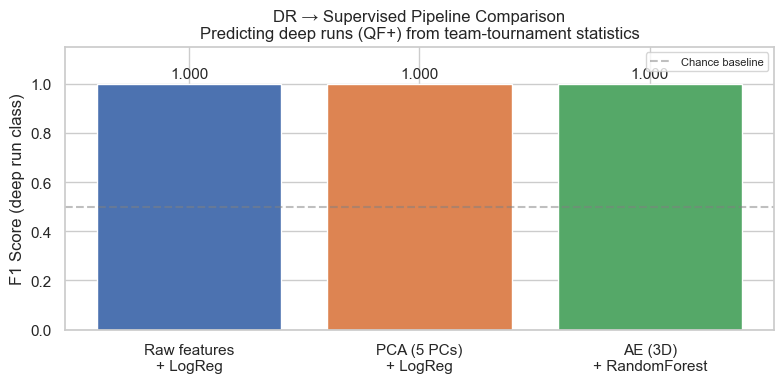

In [32]:
results = {'Raw features\n+ LogReg': f1_base, 'PCA (5 PCs)\n+ LogReg': f1_pca}
if f1_ae is not None:
    results['AE (3D)\n+ RandomForest'] = f1_ae

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(list(results.keys()), list(results.values()),
              color=['#4C72B0','#DD8452','#55A868'][:len(results)], edgecolor='white')
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('F1 Score (deep run class)')
ax.set_title('DR → Supervised Pipeline Comparison\nPredicting deep runs (QF+) from team-tournament statistics')
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.5, label='Chance baseline')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


**What these results show:** the mechanics, not a verdict. With ~25 test observations any F1 score has high variance — the point is the pipeline architecture: where the train/test boundary sits and why fitting DR on training data only is non-negotiable. Evaluation methodology follows exactly Weeks 2–5.



## PART 4 — Clustering in Two Dimensions: Intuition First

Before introducing k-means formally, we build intuition by spotting clusters visually in 2D. We look at three feature pairs, each revealing a different aspect of campaign structure. Notice how the DR plots above already hinted at the structure — now we examine it directly.

### Round 1: Goals scored vs. goals conceded — the outcome picture


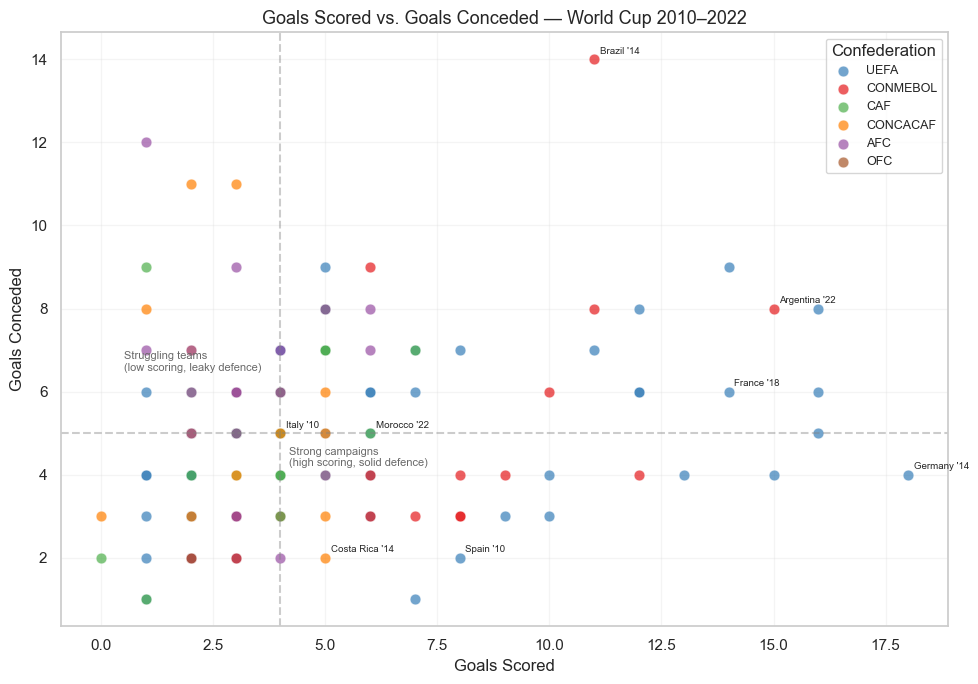

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))
for conf, color in conf_colors.items():
    mask = wc['confederation'] == conf
    ax.scatter(wc.loc[mask,'goals_scored'], wc.loc[mask,'goals_conceded'],
               c=color, label=conf, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

# Annotate notable team-tournaments
for team, year in [('Germany',2014),('Spain',2010),('Argentina',2022),
                    ('France',2018),('Morocco',2022),('Costa Rica',2014),
                    ('Brazil',2014),('Italy',2010)]:
    row = wc[(wc['team']==team)&(wc['year']==year)]
    if len(row):
        ax.annotate(f"{team} '{str(year)[2:]}",
                    (row.iloc[0]['goals_scored'], row.iloc[0]['goals_conceded']),
                    fontsize=7, xytext=(4,4), textcoords='offset points')
# Reference lines (median performance)
x_med = wc['goals_scored'].median()
y_med = wc['goals_conceded'].median()

ax.axvline(x_med, color='grey', linestyle='--', alpha=0.4)
ax.axhline(y_med, color='grey', linestyle='--', alpha=0.4)

# Annotate the regions
ax.text(x_med+0.2, y_med-0.8,
        'Strong campaigns\n(high scoring, solid defence)',
        fontsize=8, color='dimgray')

ax.text(x_med-3.5, y_med+1.5,
        'Struggling teams\n(low scoring, leaky defence)',
        fontsize=8, color='dimgray')
ax.set_xlabel('Goals Scored', fontsize=12); ax.set_ylabel('Goals Conceded', fontsize=12)
ax.set_title('Goals Scored vs. Goals Conceded — World Cup 2010–2022', fontsize=13)
ax.legend(title='Confederation', fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()


**Before reading on — how many groups do you see?**

Human perception is good at spotting clusters, but also prone to seeing patterns where none exist. Algorithms like k-means formalise this intuition using distances rather than visual judgment.

The bottom-right quadrant (many goals, few conceded) is where champions live. The top-left (few goals, many conceded) is where early exits cluster. But the boundary between "mediocre" and "solid" is not obvious. This is exactly what k-means will formalise.

### Round 2: Possession vs. shots on target — style meets effectiveness


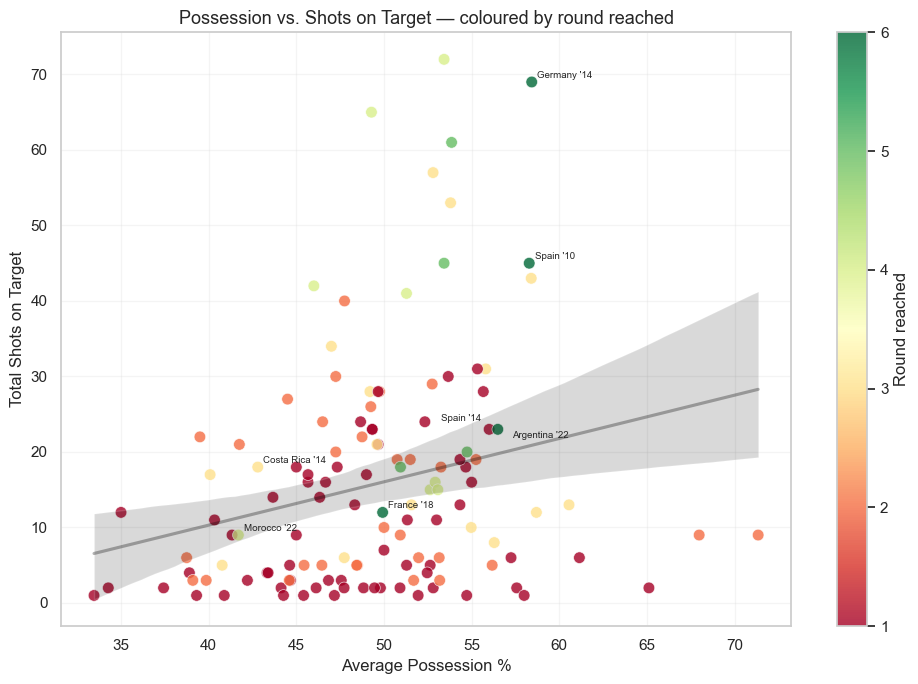

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    wc['possession_pct'], wc['shots_on_target'],
    c=wc['round_reached'], cmap='RdYlGn',
    s=70, alpha=0.8, edgecolors='white', linewidth=0.5, vmin=1, vmax=6
)

plt.colorbar(sc, ax=ax, label='Round reached')

labels = {
    ('Spain',2010):(4,3),
    ('Germany',2014):(4,3),
    ('France',2018):(4,3),
    ('Argentina',2022):(10,-6),   # moved
    ('Morocco',2022):(4,3),
    ('Costa Rica',2014):(4,3),
    ('Spain',2014):(-35,6)        # moved
}

for (team, year), offset in labels.items():
    row = wc[(wc['team']==team)&(wc['year']==year)]
    if len(row):
        ax.annotate(
            f"{team} '{str(year)[2:]}",
            (row.iloc[0]['possession_pct'], row.iloc[0]['shots_on_target']),
            fontsize=7,
            xytext=offset,
            textcoords='offset points'
        )

sns.regplot(
    x='possession_pct',
    y='shots_on_target',
    data=wc,
    scatter=False,
    ax=ax,
    color='black',
    line_kws={'alpha':0.3}
)

ax.set_xlabel('Average Possession %', fontsize=12)
ax.set_ylabel('Total Shots on Target', fontsize=12)
ax.set_title('Possession vs. Shots on Target — coloured by round reached', fontsize=13)

ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

This pair reveals the style vs. effectiveness tension. High possession does not guarantee a deep run — some high-possession teams exit early (Spain 2014 is a classic). Some teams achieve many shots on target from a low-possession base — the counter-attacking archetype.

### Round 3: Goals scored vs. possession — the counter-attacking reveal


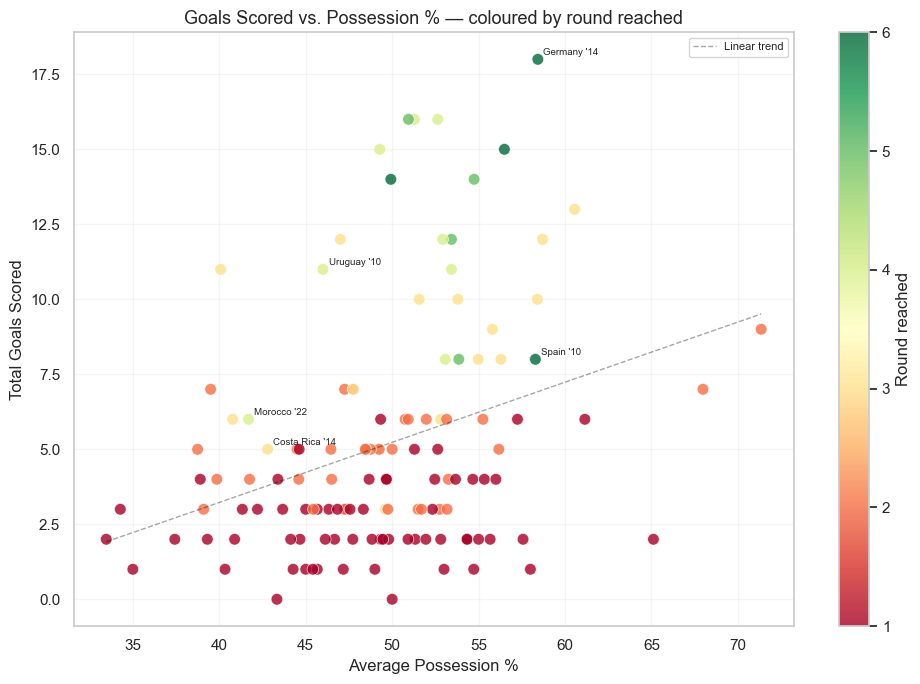

In [35]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(wc['possession_pct'], wc['goals_scored'],
                c=wc['round_reached'], cmap='RdYlGn',
                s=70, alpha=0.8, edgecolors='white', linewidth=0.5, vmin=1, vmax=6)
plt.colorbar(sc, ax=ax, label='Round reached')

# Linear trend

valid = wc[['possession_pct','goals_scored']].dropna()
coef = np.polyfit(valid['possession_pct'], valid['goals_scored'], 1)
trend = np.poly1d(coef)

x_line = np.linspace(valid['possession_pct'].min(),
                     valid['possession_pct'].max(), 100)

ax.plot(x_line, trend(x_line),
        linestyle='--', color='black',
        alpha=0.35, linewidth=1,
        label='Linear trend')

for team, year in [('Costa Rica',2014),('Uruguay',2010),
                    ('Morocco',2022),('Spain',2010),('Germany',2014)]:
    row = wc[(wc['team']==team)&(wc['year']==year)]
    if len(row):
        ax.annotate(f"{team} '{str(year)[2:]}",
                    (row.iloc[0]['possession_pct'], row.iloc[0]['goals_scored']),
                    fontsize=7, xytext=(4,3), textcoords='offset points')

ax.set_xlabel('Average Possession %', fontsize=12)
ax.set_ylabel('Total Goals Scored', fontsize=12)
ax.set_title('Goals Scored vs. Possession % — coloured by round reached', fontsize=13)
ax.legend(fontsize=8); ax.grid(True, alpha=0.2); plt.tight_layout(); plt.show()


**The counter-attacking outliers are now visible.**

Teams like Costa Rica 2014 and Uruguay 2010 sit in an unusual position: below-average possession, but competitive goals scored, and deep runs. A k-means algorithm forced to assign every point to one of four spherical clusters will put these teams *somewhere* — but they don't really belong to any natural group. K-means must assign every observation to a cluster, even if the point lies far from all cluster centres. This is the first motivation for DBSCAN, which can explicitly label them as noise.

<div style="border-left:4px solid #0969da;padding:0.65em 1em;border-radius:4px;margin:6px 0;">
<strong style="color:#0969da;">📝 From 2D to full-dimensional clustering</strong>

We have looked at three 2D projections. Each is informative but partial. We have 11 features — no 2D plot captures the full picture, and the "right" pair is a subjective choice. In high-dimensional spaces, distances also become less meaningful as dimensions accumulate. This is why we: (1) run DR first to see the full-dimensional structure honestly, and (2) apply principled clustering algorithms rather than eyeballing 2D plots.
</div>



## PART 5 — K-Means, K-Medoids, Choosing k, and Evaluation

In the previous section we inspected several **two-dimensional projections** of the data and informally identified possible groups of team-tournaments.

Humans are good at spotting patterns visually, but this approach has two major limitations:

* **Subjectivity:** different observers may see different clusters.
* **Dimensionality:** our dataset contains **11 features**, and any 2D plot hides most of the structure.

Clustering algorithms formalise this process by grouping observations according to **distance in feature space** rather than visual inspection.

We begin with the most widely used clustering algorithm: **k-means**.

### 5.1 K-means

K-means partitions $n$ observations into $k$ clusters by minimising the **within-cluster sum of squares (WCSS)**:

$$
\text{WCSS} =
\sum_{j=1}^{k} \sum_{x_i \in C_j} |x_i - \mu_j|^2
$$

where:

* $C_j$ is cluster $j$
* $\mu_j$ is the **centroid** (mean vector) of cluster $j$

The algorithm searches for cluster assignments where points are **as close as possible to the centroid of their cluster**.

Intuitively:

* points inside a cluster should be **similar**
* clusters should be **distinct from each other**

#### The k-means algorithm

K-means works through an iterative refinement process:

```mermaid
flowchart LR
    A["Initialise k centroids"] --> B["Assign each point to nearest centroid"]
    B --> C["Recompute centroids as cluster means"]
    C --> D{Assignments changed?}
    D -- Yes --> B
    D -- No --> E[Converged]
```

Each iteration consists of two steps:

**Assignment step**

Each observation is assigned to the **nearest centroid**.

**Update step**

Each centroid is recomputed as the **mean of the points assigned to that cluster**.

The process repeats until cluster assignments stop changing.

Let's visualise what k-mean does [here](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)


#### Why standardisation matters

K-means relies on **Euclidean distance**, meaning variables with larger numerical ranges contribute more to the distance calculation.

For example:

* **goals scored** ranges roughly **0–18**
* **possession percentage** ranges roughly **35–70**

Because possession varies over a larger numerical range, differences in possession would dominate differences in goals scored if the data were left unscaled.

To avoid this imbalance we **standardise the features**, transforming each variable to have:

* **mean = 0**
* **standard deviation = 1**

This ensures that each variable contributes **equally** to the distance calculation.

#### K-means++ initialisation

Random initialisation can produce poor local minima. **K-means++** places centroids probabilistically: the second centroid is chosen with probability proportional to its squared distance from the first, and so on. This dramatically reduces bad initialisations and is the default in scikit-learn (`init='k-means++'`).

#### Limitations

| Limitation | Consequence |
|-----------|-------------|
| Must specify k | Requires separate model selection |
| Assumes spherical, similarly-sized clusters | Struggles with elongated or non-convex shapes |
| Sensitive to scale | Always standardise first |
| Synthetic centroids | The centroid is rarely an actual observation |
| Hard assignments | Every point is in exactly one cluster — no outlier concept |


### 5.2 Building intuition: k-means in two dimensions

Before clustering the full dataset, it is helpful to see how k-means behaves in a simple **two-dimensional setting**.

We use the **goals scored vs goals conceded** feature pair introduced earlier.

In [36]:
X_2d = wc[['goals_scored','goals_conceded']]
X_2d_scaled = StandardScaler().fit_transform(X_2d)

km2d = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=SEED)
wc['cluster_2d'] = km2d.fit_predict(X_2d_scaled)

#### Visualising the clusters

In [37]:
fig = go.Figure()

colors = ['#219ebc','#fb8500','#023047','#ffb703']

for c in range(4):

    mask = wc['cluster_2d'] == c
    df = wc.loc[mask]

    fig.add_trace(
        go.Scatter(
            x=df['goals_scored'],
            y=df['goals_conceded'],
            mode='markers',
            name=f'Cluster {c}',
            marker=dict(
                color=colors[c],
                size=9,
                line=dict(width=0.5, color='white')
            ),
            customdata=df[['team','year','round_label']],
            hovertemplate=
            "<b>%{customdata[0]}</b><br>"
            "Year: %{customdata[1]}<br>"
            "Round: %{customdata[2]}<br>"
            "Goals scored: %{x}<br>"
            "Goals conceded: %{y}<extra></extra>"
        )
    )


# Centroids
centroids = StandardScaler().fit(X_2d).inverse_transform(km2d.cluster_centers_)

fig.add_trace(
    go.Scatter(
        x=centroids[:,0],
        y=centroids[:,1],
        mode='markers',
        name='Centroids',
        marker=dict(
            symbol='x',
            color='black',
            size=14,
            line=dict(width=2)
        ),
        hovertemplate=
        "Centroid<br>"
        "Goals scored: %{x:.2f}<br>"
        "Goals conceded: %{y:.2f}<extra></extra>"
    )
)

fig.update_layout(
    title="K-means clustering in two dimensions",
    xaxis_title="Goals scored",
    yaxis_title="Goals conceded",
    width=700,
    height=550,
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.15,
        xanchor="center",
        x=0.5
    ),
    margin=dict(b=100)
)

fig.show()

Notice that the centroids are not actual team-tournaments — they are the mean position of all campaigns in the cluster.

#### Interpreting the clusters

We can examine the **average feature values within each cluster**.

In [38]:
wc.groupby('cluster_2d')[CORE_FEATURES[:6]+['round_reached']].mean()

,goals_scored,goals_conceded,goal_diff,shots,shots_on_target,shot_conversion,round_reached
cluster_2d,,,,,,,
0,3.812500,5.833333,-2.020833,45.604167,13.625000,0.085487,1.520833
1,12.947368,5.789474,7.157895,88.526316,30.631579,0.152439,4.052632
2,4.153846,9.538462,-5.384615,42.615385,13.769231,0.106148,1.461538
3,3.625000,2.979167,0.645833,47.520833,12.562500,0.077368,1.729167


This helps interpret clusters as **campaign archetypes**, for example:

* dominant teams
* balanced teams
* defensive low-scoring teams
* struggling campaigns

Clustering therefore acts as a **data-driven taxonomy of tournament styles**.

#### Interpreting the 2D K-Means Clustering

Using only **goals scored** and **goals conceded**, k-means divides the campaigns into four groups.

Although the clusters are derived purely from these two variables, they already reveal meaningful tournament patterns.

**Cluster 1: Dominant attacking teams**

This cluster clearly stands apart.

| Metric          | Value |
| --------------- | ----- |
| Goals scored    | ~13   |
| Goals conceded  | ~5.8  |
| Goal difference | +7.2  |
| Round reached   | ~4    |

These are **dominant tournament campaigns**. Teams in this group combine strong attacking production with solid defensive records and typically reach the **semi-finals or beyond**.

These campaigns correspond to elite teams that control matches and generate large numbers of chances.

**Cluster 2: Defensive collapses**

This cluster contains teams that concede heavily relative to their attacking output.

| Metric          | Value |
| --------------- | ----- |
| Goals scored    | ~4    |
| Goals conceded  | ~9.5  |
| Goal difference | –5.4  |
| Round reached   | ~1.5  |

These teams struggle defensively and exit the tournament early. Even when they generate attacking opportunities, the defensive weakness prevents them from progressing.

**Cluster 0: Inefficient attackers**

These teams create some chances but struggle to convert them into goals.

| Metric          | Value |
| --------------- | ----- |
| Goals scored    | ~3.8  |
| Goals conceded  | ~5.8  |
| Goal difference | –2.0  |
| Round reached   | ~1.5  |

They produce moderate attacking activity but lack efficiency, resulting in early elimination.

**Cluster 3: Low-event campaigns**

Teams in this cluster produce relatively **few goals but also concede little**.

| Metric          | Value |
| --------------- | ----- |
| Goals scored    | ~3.6  |
| Goals conceded  | ~3.0  |
| Goal difference | +0.6  |
| Round reached   | ~1.7  |

These are typically **low-scoring campaigns** where teams play cautiously but lack enough attacking output to progress far.

**An interesting observation**

Clusters **0 and 3** are quite similar: both score relatively few goals and exit early.

The difference is that Cluster 3 defends slightly better.

This suggests that the natural structure of the data may actually contain **three broad campaign types** rather than four:

1. Dominant teams
2. Weak defensive teams
3. Low-scoring early exits

By forcing (k=4), k-means splits one of these groups into two smaller clusters.

This illustrates an important idea:

> K-means will always produce (k) clusters — even if the true structure contains fewer natural groups.

#### Transition to the full feature space

The two-dimensional example is helpful because we can **visualise the clusters directly**, but it only uses two variables.

Our dataset contains **many more performance features**, including:

* shot volume
* shots on target
* conversion efficiency
* goal difference
* and others.

To capture the full structure of the campaigns, we now run **k-means on the full standardised feature set**.

The resulting clusters will then be visualised in **UMAP space**, allowing us to inspect the high-dimensional structure in two dimensions.

#### Why the full-space clustering matters

Using all features allows the clustering algorithm to distinguish between teams that may look similar in goals scored and conceded but differ in other aspects of performance, such as:

* attacking pressure (shots)
* finishing efficiency
* overall match dominance.

This richer feature space often produces **more meaningful clusters** than simple 2D projections.

### 5.3 Clustering the full dataset

We now apply k-means to the **full set of features** (after standardisation):

In [39]:
# ── Fit k-means with an initial guess of k=4 ─────────────────────────────
km4 = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=SEED)
wc['cluster_km'] = km4.fit_predict(X_scaled)

Because clustering occurs in **11-dimensional feature space**, we cannot visualise it directly.

To inspect the cluster structure we project the data into **UMAP space**, which preserves much of the high-dimensional structure while allowing a 2D visualisation.

It is important to note:

> **Clustering is performed in the original feature space — UMAP is used only for visualisation.**

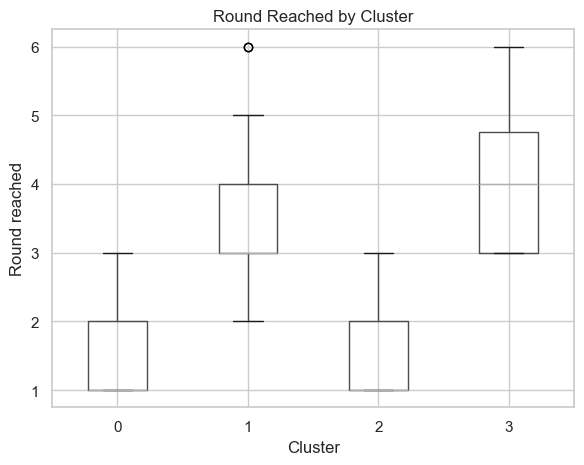


Cluster profiles (mean values):


,goals_scored,goals_conceded,goal_diff,shots,shots_on_target,shot_conversion,round_reached
cluster_km,,,,,,,
3,10.79,5.07,5.71,96.00,49.00,0.12,4.00
1,10.88,5.53,5.35,82.00,13.00,0.14,3.76
2,3.54,5.56,-2.02,48.76,19.37,0.07,1.37
0,3.14,4.71,-1.57,35.16,5.66,0.09,1.36


In [40]:
fig = go.Figure()

cluster_colors = ['#d62728','#2ca02c','#1f77b4','#ff7f0e']

if UMAP_AVAILABLE:
    x = wc['UMAP1']
    y = wc['UMAP2']
    xlabel = "UMAP 1"
    ylabel = "UMAP 2"
    title  = "K-Means (k=4) clusters in UMAP space"
else:
    x = pca_scores[:,0]
    y = pca_scores[:,1]
    xlabel = "PC1"
    ylabel = "PC2"
    title  = "K-Means (k=4) clusters in PCA space"

for c in range(4):

    mask = wc["cluster_km"] == c
    df = wc.loc[mask]

    fig.add_trace(
        go.Scatter(
            x=x[mask],
            y=y[mask],
            mode="markers",
            name=f"Cluster {c}",
            marker=dict(
                color=cluster_colors[c],
                size=9,
                line=dict(width=0.5, color="white")
            ),
            customdata=df[["team","year","round_label"]],
            hovertemplate=
            "<b>%{customdata[0]}</b><br>"
            "Year: %{customdata[1]}<br>"
            "Round: %{customdata[2]}<br>"
            f"{xlabel}: "+"%{x:.2f}<br>"
            f"{ylabel}: "+"%{y:.2f}<extra></extra>"
        )
    )

fig.update_layout(
    title=title,
    xaxis_title=xlabel,
    yaxis_title=ylabel,
    width=650,
    height=550,
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.15,
        xanchor="center",
        x=0.5
    ),
    margin=dict(b=100)
)

fig.show()

# Round reached by cluster
fig, ax = plt.subplots(figsize=(6,5))

wc.boxplot(column='round_reached', by='cluster_km', ax=ax)

ax.set_title('Round Reached by Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Round reached')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("\nCluster profiles (mean values):")
wc.groupby('cluster_km')[CORE_FEATURES[:6]+['round_reached']].mean().round(2)  .sort_values('round_reached', ascending=False)


#### Interpreting the full-space K-means clustering

K-means was applied to the **full feature set** (after standardisation).
The resulting clusters are visualised in **UMAP space**, which preserves much of the high-dimensional structure while allowing us to inspect the clusters in two dimensions.

The boxplot of **round reached by cluster** helps interpret what these groups represent.

**Cluster 3: Deep tournament runs**

Cluster 3 clearly contains the **most successful campaigns**.

Average characteristics:

| Metric          | Value |
| --------------- | ----- |
| Goals scored    | ~10.8 |
| Goals conceded  | ~5.1  |
| Goal difference | +5.7  |
| Shots           | ~96   |
| Shots on target | ~49   |
| Round reached   | ~4    |

These teams generate **very high attacking pressure** and maintain a strong goal difference.
The boxplot confirms that this cluster corresponds to teams reaching the **semi-final stage or beyond**.

This cluster therefore represents **dominant tournament campaigns**.

**Cluster 1: Strong but less dominant contenders**

Cluster 1 contains teams that also score heavily but generate **lower attacking volume**.

| Metric          | Value                  |
| --------------- | ---------------------- |
| Goals scored    | ~10.9                  |
| Goals conceded  | ~5.5                   |
| Goal difference | +5.3                   |
| Shots           | ~82                    |
| Shot conversion | highest among clusters |
| Round reached   | ~3.8                   |

These teams perform strongly but rely more on **efficiency** than overwhelming attacking pressure.

The boxplot shows they frequently reach the **quarter-finals or semi-finals**, but less consistently than Cluster 3.

**Cluster 2: Inefficient attacking teams**

Cluster 2 contains teams that generate a moderate number of chances but convert them poorly.

| Metric          | Value  |
| --------------- | ------ |
| Goals scored    | ~3.5   |
| Goals conceded  | ~5.6   |
| Goal difference | –2.0   |
| Shots           | ~49    |
| Shot conversion | lowest |
| Round reached   | ~1.37  |

These teams attempt to attack but lack finishing efficiency.
As a result, they typically exit **in the group stage**.

**Cluster 0: Low-event campaigns**

Cluster 0 represents teams that produce **very little attacking activity** overall.

| Metric          | Value    |
| --------------- | -------- |
| Goals scored    | ~3.1     |
| Goals conceded  | ~4.7     |
| Goal difference | –1.6     |
| Shots           | ~35      |
| Shots on target | very low |
| Round reached   | ~1.36    |

Compared with Cluster 2, these teams create fewer chances but defend slightly better.

Both clusters correspond to **early tournament exits**, but they fail in different ways:

| Cluster   | Failure mode             |
| --------- | ------------------------ |
| Cluster 0 | Low attacking production |
| Cluster 2 | Inefficient attacking    |


### 5.3 K-medoids

K-medoids solves two of k-means' key limitations:

1. **Synthetic centroids:** k-means centroids are means — they may not correspond to any real observation. K-medoids centroids are **medoids**: actual observations that minimise the sum of distances to other cluster members. The medoid of "the elite cluster" is a real team-tournament — you can name it.

2. **Robustness to outliers:** because medoids are real observations, a single extreme outlier cannot pull the cluster centre far from the main mass. K-means centroids are sensitive to outliers; k-medoids medoids are not.

3. **Any distance metric:** k-medoids works with any pairwise distance, including non-Euclidean distances. (Here we use Euclidean for comparability with k-means, but the flexibility is valuable.)

The algorithm uses **PAM (Partitioning Around Medoids)** by default — an exact optimisation that is slower than k-means for large datasets but fully appropriate for our ~128 observations.

<div style="border-left:4px solid #0969da;padding:0.65em 1em;border-radius:4px;margin:6px 0;">
<strong style="color:#0969da;">📝 What about Gower distance?</strong>

**Gower distance** is a general-purpose metric for mixed data. For two observations $i$ and $i'$, it computes a per-variable distance — using absolute difference (scaled to $[0,1]$) for numeric variables and 0/1 disagreement for categorical variables — then averages across all variables:

$$d_{\text{Gower}}(i, i') = \frac{1}{p} \sum_{j=1}^{p} d_j(i, i')$$

where $d_j$ is the contribution of variable $j$, with numeric variables divided by their range so all variables contribute equally regardless of scale.

K-medoids with Gower distance can cluster directly on the raw mixed feature matrix — numeric stats *and* categorical variables like `confederation` and `playing_style` — without any prior DR. This sounds appealing, but it runs into the **curse of dimensionality**: as the number of features $p$ grows, all pairwise Gower distances converge toward the same value, making it impossible to distinguish close from far neighbours. In high dimensions, distance loses its meaning.

This is precisely what dimensionality reduction addresses. By running FAMD or UMAP first, we produce a low-dimensional numeric representation that compresses both numeric and categorical structure — and then Euclidean distance on that representation is well-behaved. Gower on raw features and Euclidean on DR output are two routes to the same destination; in high-dimensional settings the DR route is more reliable.
</div>


In [41]:
if KMEDOIDS_AVAILABLE:
    D = pairwise_distances(X_scaled, metric='euclidean')

    km_med = kmedoids.KMedoids(n_clusters=4, method='fasterpam', random_state=SEED)
    km_med.fit(D)
    wc['cluster_kmed'] = km_med.labels_

    # Who are the medoids? (actual team-tournament observations)
    print("K-Medoids — the 4 medoid team-tournaments (actual observations):")
    for c, medoid_idx in enumerate(km_med.medoid_indices_):
        row = wc.iloc[medoid_idx]
        print(f"  Cluster {c}: {row['team']} {row['year']} [{row['round_label']}]"
              f"  (goals: {row['goals_scored']}, poss: {row['possession_pct']:.1f}%)")

    print("\nK-Medoids cluster sizes:")
    print(wc['cluster_kmed'].value_counts().sort_index().to_string())
else:
    print("Install kmedoids: pip install kmedoids")


K-Medoids — the 4 medoid team-tournaments (actual observations):
  Cluster 0: England 2018 [Semi-final]  (goals: 12, poss: 52.9%)
  Cluster 1: Nigeria 2018 [Group Stage]  (goals: 3, poss: 47.6%)
  Cluster 2: South Africa 2010 [Group Stage]  (goals: 3, poss: 47.3%)
  Cluster 3: Brazil 2010 [Quarter-final]  (goals: 9, poss: 55.8%)

K-Medoids cluster sizes:
cluster_kmed
0    12
1    59
2    35
3    22


In [42]:
if KMEDOIDS_AVAILABLE and UMAP_AVAILABLE:

    agreement = (wc['cluster_km'] == wc['cluster_kmed']).mean()

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=[
            "K-Medoids (k=4) — stars = medoids",
            f"K-Means vs K-Medoids assignments (agreement: {agreement*100:.0f}%)"
        ]
    )

    # --- Left panel: clusters in UMAP space ---
    for c in range(4):
        mask = wc['cluster_kmed'] == c

        fig.add_trace(
            go.Scatter(
                x=wc.loc[mask,'UMAP1'],
                y=wc.loc[mask,'UMAP2'],
                mode="markers",
                name=f"Cluster {c}",
                marker=dict(
                    size=9,
                    color=cluster_colors[c],
                    line=dict(width=0.5,color="white")
                ),
                customdata=wc.loc[mask,['team','year','round_reached']],
                hovertemplate=
                "<b>%{customdata[0]}</b><br>"
                "Year: %{customdata[1]}<br>"
                "Round: %{customdata[2]}<br>"
                "UMAP1: %{x:.2f}<br>"
                "UMAP2: %{y:.2f}<extra></extra>"
            ),
            row=1,col=1
        )

    # --- Medoids ---
    for c, medoid_idx in enumerate(km_med.medoid_indices_):

        row = wc.iloc[medoid_idx]

        fig.add_trace(
            go.Scatter(
                x=[row['UMAP1']],
                y=[row['UMAP2']],
                mode="markers+text",
                marker=dict(
                    size=18,
                    symbol="star",
                    color="black"
                ),
                text=[f"{row['team']} {row['year']}"],
                textposition="top center",
                name=f"Medoid {c}",
                showlegend=False,
                hovertemplate=
                "<b>Medoid</b><br>"
                f"{row['team']} {row['year']}<br>"
                "UMAP1: %{x:.2f}<br>"
                "UMAP2: %{y:.2f}<extra></extra>"
            ),
            row=1,col=1
        )

    # --- Right panel: agreement scatter ---
    fig.add_trace(
        go.Scatter(
            x=wc['cluster_km'] + np.random.uniform(-0.1,0.1,len(wc)),
            y=wc['cluster_kmed'] + np.random.uniform(-0.1,0.1,len(wc)),
            mode="markers",
            marker=dict(size=7,opacity=0.6,color="#4C72B0"),
            customdata=wc[['team','year']],
            hovertemplate=
            "<b>%{customdata[0]}</b><br>"
            "Year: %{customdata[1]}<br>"
            "K-Means: %{x:.2f}<br>"
            "K-Medoids: %{y:.2f}<extra></extra>",
            showlegend=False
        ),
        row=1,col=2
    )

    fig.update_xaxes(title_text="UMAP 1", row=1, col=1)
    fig.update_yaxes(title_text="UMAP 2", row=1, col=1)

    fig.update_xaxes(title_text="K-Means cluster", row=1, col=2)
    fig.update_yaxes(title_text="K-Medoids cluster", row=1, col=2)

    fig.update_layout(
        height=500,
        width=950,
        legend=dict(
            orientation="h",
            y=-0.2,
            x=0.5,
            xanchor="center"
        )
    )

    fig.show()

K-medoids was applied with the same number of clusters as K-means (on full feature set).

Unlike k-means, which represents clusters using **centroids (means of points)**, k-medoids represents each cluster with a **real observation from the dataset** — the **medoid**.

The medoids identified by the algorithm are:

| Cluster   | Medoid campaign   | Outcome       |
| --------- | ----------------- | ------------- |
| Cluster 0 | England 2018      | Semi-final    |
| Cluster 1 | Nigeria 2018      | Group stage   |
| Cluster 2 | South Africa 2010 | Group stage   |
| Cluster 3 | Brazil 2010       | Quarter-final |

These campaigns act as **representative examples of each cluster’s behaviour**.

**Cluster size differences**

The cluster sizes also reveal the overall structure of the dataset:

| Cluster   | Size |
| --------- | ---- |
| Cluster 1 | 59   |
| Cluster 2 | 35   |
| Cluster 3 | 22   |
| Cluster 0 | 12   |

Most campaigns belong to clusters **1 and 2**, which correspond to teams that exit early in the tournament.

Smaller clusters represent **stronger tournament performances**, which are naturally rarer.

**Interpreting the medoids**

Because medoids are actual observations, they provide a useful **concrete interpretation of cluster behaviour**.

For example:

* **England 2018** represents a successful deep run campaign.
* **Brazil 2010** represents a strong attacking team that advanced but did not win the tournament.
* **Nigeria 2018** and **South Africa 2010** represent early-exit campaigns.

Rather than abstract cluster centres, the algorithm identifies **real team-tournament examples that typify each group**.

#### Comparing K-Means and K-Medoids

The scatter plot comparing assignments from the two algorithms shows that they agree on only about **37% of observations**.

This highlights an important point:

> Clustering results depend on the algorithm used.

K-means minimises **squared distance to centroids**, while k-medoids minimises distance to **representative observations**. Because these objectives differ, cluster boundaries can shift substantially.

Despite this, the **overall campaign archetypes remain recognisable**, suggesting that the dataset contains genuine underlying structure rather than patterns produced purely by modelling choices.


### 5.4 Choosing k — three methods

We have used k=4 so far. Is that the right number? There is no single correct
answer — different methods operationalise "good clustering" differently and
will sometimes disagree. We use three complementary approaches.

#### Method 1 — Elbow method (WCSS)

**Intuition.** As k increases, clusters get smaller and tighter — WCSS always
decreases. But beyond some point, adding another cluster gives diminishing
returns: we are splitting a genuinely coherent group rather than separating
two distinct ones. The "elbow" is where the curve bends — the point of
diminishing returns.

**Definition.** WCSS (Within-Cluster Sum of Squares) is the k-means objective:

$$\text{WCSS}(k) = \sum_{j=1}^{k} \sum_{i \in C_j} \| x_i - \mu_j \|^2$$

where $\mu_j$ is the centroid of cluster $j$ and the inner sum runs over all
points assigned to that cluster. It is also called **inertia** in scikit-learn
(`km.inertia_`). Lower is better, but lower is always achievable by increasing
k — we are looking for the k at which the rate of improvement drops sharply.

**Limitation.** The elbow is often ambiguous — the curve may bend gradually
rather than sharply, making the "right" k a matter of judgment. `KneeLocator`
from the `kneed` library automates this by fitting a mathematical knee to the
curve, but it can disagree with visual inspection.

#### Method 2 — Silhouette score

**Intuition.** For each point, ask two questions: how similar is it to the
other points in its own cluster? And how similar is it to the points in the
nearest other cluster? A point that is much closer to its own cluster than to
any other scores near +1. A point that is equidistant between two clusters
scores near 0. A point that is closer to another cluster than its own scores
negative.

**Definition.** For observation $i$, let $a(i)$ be the mean distance to all
other points in the same cluster (cohesion) and $b(i)$ be the mean distance
to all points in the nearest other cluster (separation). The silhouette
coefficient is:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}$$

The overall silhouette score is the mean of $s(i)$ across all observations.
Range: $[-1, +1]$. Maximise.

A score above 0.5 generally indicates reasonable cluster structure. Below 0.2
suggests clusters are not well-separated. Negative values mean many points are
in the wrong cluster.

**Limitation.** Silhouette score favours compact, well-separated clusters and
penalises elongated or overlapping ones — it tends to prefer smaller k values
even when a larger k is substantively more meaningful.

#### Method 3 — Calinski-Harabász index

**Intuition.** Good clusters should be tight internally and well-separated from
each other. CH measures both simultaneously by taking the ratio of
between-cluster variance to within-cluster variance. A high ratio means the
clusters are far apart relative to how spread out they are internally.

**Definition.** Let $B_k$ be the between-cluster scatter matrix and $W_k$ be
the within-cluster scatter matrix. The CH index is:

$$\text{CH}(k) = \frac{\text{tr}(B_k)}{\text{tr}(W_k)} \times \frac{n - k}{k - 1}$$

where $n$ is the number of observations and the $(n-k)/(k-1)$ factor corrects
for the fact that both numerator and denominator grow with k. Higher is better.
No upper bound. Maximise.

**Limitation.** Like silhouette, CH assumes convex, similarly-sized clusters
and tends to favour solutions with fewer, more compact groups. It can be
misleading when the true cluster structure is non-convex or unequal in size.

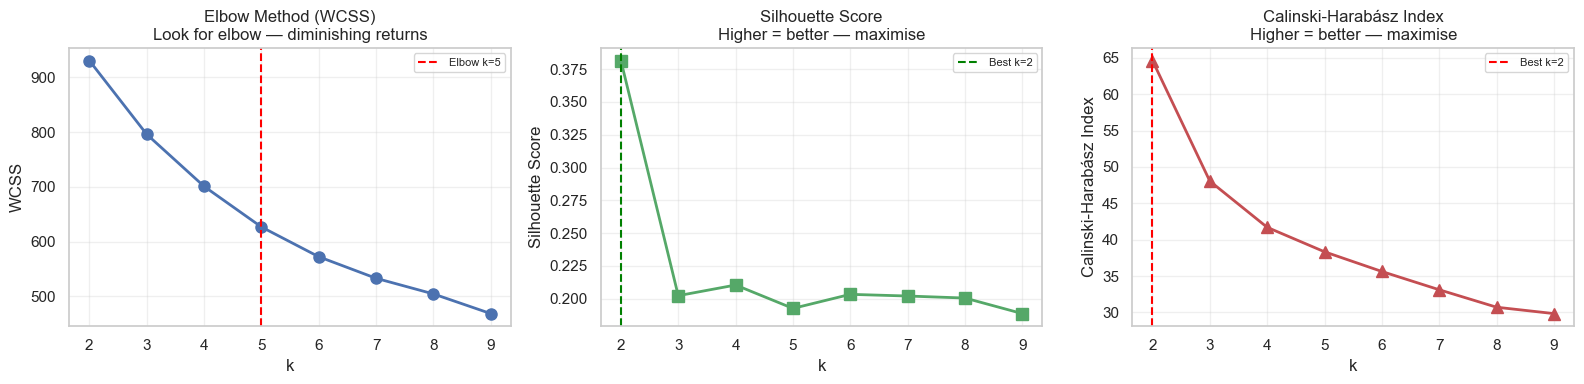

Elbow suggestion:       k = 5
Best k by silhouette:   k = 2  (score = 0.381)
Best k by CH index:     k = 2  (score = 64.6)


In [43]:
k_range  = range(2, 10)
wcss     = []
sil_scores = []
ch_scores  = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=SEED)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(k_range), wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('k'); axes[0].set_ylabel('WCSS')
axes[0].set_title('Elbow Method (WCSS)\nLook for elbow — diminishing returns')
axes[0].grid(True, alpha=0.3)
if KNEED_AVAILABLE:
    kl = KneeLocator(list(k_range), wcss, curve='convex', direction='decreasing')
    if kl.knee:
        axes[0].axvline(kl.knee, color='red', linestyle='--', label=f'Elbow k={kl.knee}')
        axes[0].legend(fontsize=8)

axes[1].plot(list(k_range), sil_scores, 'gs-', linewidth=2, markersize=8)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\nHigher = better — maximise')
axes[1].grid(True, alpha=0.3)
best_k_sil = list(k_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k_sil, color='green', linestyle='--', label=f'Best k={best_k_sil}')
axes[1].legend(fontsize=8)

axes[2].plot(list(k_range), ch_scores, 'r^-', linewidth=2, markersize=8)
axes[2].set_xlabel('k'); axes[2].set_ylabel('Calinski-Harabász Index')
axes[2].set_title('Calinski-Harabász Index\nHigher = better — maximise')
axes[2].grid(True, alpha=0.3)
best_k_ch = list(k_range)[np.argmax(ch_scores)]
axes[2].axvline(best_k_ch, color='red', linestyle='--', label=f'Best k={best_k_ch}')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"Elbow suggestion:       k = {kl.knee if KNEED_AVAILABLE and kl.knee else 'see plot'}")
print(f"Best k by silhouette:   k = {best_k_sil}  (score = {max(sil_scores):.3f})")
print(f"Best k by CH index:     k = {best_k_ch}  (score = {max(ch_scores):.1f})")


#### The code

The loop fits k-means for each k from 2 to 9 and records all three metrics.
`n_init=20` re-runs k-means from 20 different random initialisations and keeps
the best — important for getting stable results across k values.

<div style="border-left:4px solid #2a9d8f;padding:0.65em 1em;
            border-radius:4px;margin:10px 0;background:#f0faf9">
<strong style="color:#2a9d8f">💡 Going further — Yellowbrick</strong><br>
<a href="https://www.scikit-yb.org">Yellowbrick</a> is a visualisation library
that wraps scikit-learn and produces publication-quality diagnostic plots for
model selection with a single function call. For k selection specifically:

```python
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Elbow + silhouette + CH in one line each
viz = KElbowVisualizer(KMeans(random_state=SEED), k=(2,10), metric='silhouette', force_model=True)
viz.fit(X_scaled); viz.show()

# Silhouette diagram for a specific k
viz2 = SilhouetteVisualizer(KMeans(n_clusters=4, random_state=SEED), force_model=True)
viz2.fit(X_scaled); viz2.show()
```

Yellowbrick also produces the silhouette diagram automatically,
with cluster-coloured bars and the mean silhouette line. Worth installing if
you use k-means regularly: `pip install yellowbrick`.
</div>


**Do the three methods agree?** If elbow, silhouette, and CH all point to the same k, you have strong
converging evidence. If they disagree — which is common — the data does not
have an unambiguous cluster structure at any particular k, and domain knowledge
should break the tie. In that case, fit two or three candidate values of k,
profile the resulting clusters, and choose the solution that is most
interpretable given what you know about football.

#### Davies-Bouldin index (extra — for reference)

**Intuition.** For each cluster, find the other cluster that is most similar
to it — where similarity means large internal spread relative to the distance
between the two cluster centres. Average this worst-case similarity score
across all clusters. A good clustering has clusters that are compact and far
apart, so the worst-case similarity is low.

**Definition.** For cluster $j$, let $s_j$ be the average distance from points
in that cluster to their centroid (a measure of scatter), and let $d_{jl}$ be
the distance between the centroids of clusters $j$ and $l$. The Davies-Bouldin
index is:

$$\text{DB}(k) = \frac{1}{k} \sum_{j=1}^{k} \max_{l \neq j} \left( \frac{s_j + s_l}{d_{jl}} \right)$$

The ratio $(s_j + s_l) / d_{jl}$ is large when the two clusters are spread out
internally (large $s_j$, $s_l$) and close to each other (small $d_{jl}$) — the
worst case for separability. Taking the max over all $l$ for each cluster $j$
finds that cluster's most problematic neighbour. Averaging over all clusters
gives the overall index. **Lower is better. Minimise.**

**Comparison to the other indices.**

| Index | Optimise | Measures | Sensitive to |
|-------|----------|----------|--------------|
| WCSS (elbow) | Minimise | Within-cluster compactness only | Scale, outliers |
| Silhouette | Maximise | Cohesion vs. separation, per point | Cluster shape |
| Calinski-Harabász | Maximise | Global between/within variance ratio | Cluster size imbalance |
| Davies-Bouldin | Minimise | Worst-case cluster similarity | Cluster shape |

DB and silhouette are the most complementary pair: silhouette evaluates each
point individually and averages, while DB evaluates each cluster's worst-case
neighbour. When they agree on the same k, that k is well-supported from two
different angles. When they disagree, inspect the clusters at both candidate
values and ask which solution is more interpretable.

**Limitation.** Like silhouette and CH, DB assumes convex clusters and uses
centroid-based distances. It is also sensitive to the choice of distance metric
and tends to favour solutions where all clusters are roughly the same size.

<div style="border-left:4px solid #e9c46a;padding:0.65em 1em;
            border-radius:4px;margin:10px 0;background:#fefdf0">
<strong style="color:#b5830a">⚠️ No index is a ground truth</strong><br>
All four indices measure <em>geometric</em> cluster quality — compactness and
separation in feature space. None of them can tell you whether the clusters
are <em>meaningful</em>. A clustering with DB = 0.4 and silhouette = 0.6 might
be geometrically beautiful but analytically useless if the clusters do not
correspond to any interpretable real-world distinction. Always validate the
chosen k substantively: profile each cluster on the original features, name
it, and ask whether the naming makes sense given what you know about football.
The indices help you narrow down candidates — domain knowledge makes the final
call.
</div>


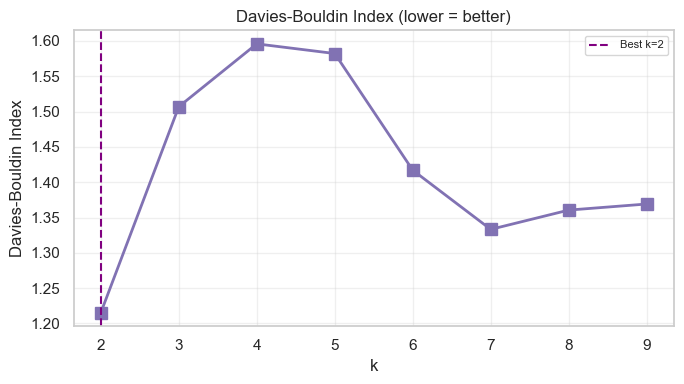

In [44]:
# ── Davies-Bouldin index (extra — for reference) ──────────────────────────
db_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=SEED)
    labels = km.fit_predict(X_scaled)
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), db_scores, 'ms-', linewidth=2, markersize=8)
best_k_db = list(k_range)[np.argmin(db_scores)]
ax.axvline(best_k_db, color='purple', linestyle='--', label=f'Best k={best_k_db}')
ax.set_xlabel('k'); ax.set_ylabel('Davies-Bouldin Index')
ax.set_title('Davies-Bouldin Index (lower = better)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 5.5 Cluster evaluation — what do the indices actually measure?

<div style="border-left:4px solid #e36209;padding:0.65em 1em;border-radius:4px;margin:6px 0;">
<strong style="color:#e36209;">⚠️ A critical caveat</strong><br>
Internal evaluation indices (silhouette, CH, DB) measure <strong>geometric
cluster quality</strong> — how tight and well-separated the clusters are in
feature space. They do <strong>not</strong> measure whether the clusters are
meaningful. Always validate clusters substantively.
</div>

We evaluate the final clustering in three steps: first a geometric check using
the silhouette diagram, then a statistical profile of each cluster's mean
feature values, then a substantive naming exercise — asking what each cluster
actually represents in football terms.

#### Step 1 — Silhouette diagram: are the assignments geometrically sound?

The silhouette diagram shows one horizontal bar per observation, sorted by
silhouette coefficient within each cluster. The x-axis is the silhouette
coefficient $s(i) \in [-1, +1]$: how much more similar a point is to its own
cluster than to the nearest other cluster. The red dashed line is the mean
across all observations.

**Interpreting the scale**

* **$s(i) \approx +1$** → the point is much closer to its own cluster than to others (well separated).
* **$s(i) \approx 0$** → the point lies near the boundary between clusters.
* **$s(i) < 0$** → the point is closer to another cluster than to its assigned one (likely misassigned).

As a rough rule of thumb for the **mean silhouette score**:

| Mean silhouette | Interpretation                 |
| --------------- | ------------------------------ |
| **> 0.7**       | very strong cluster separation |
| **0.5–0.7**     | clear cluster structure        |
| **0.25–0.5**    | moderate / weak structure      |
| **< 0.25**      | little cluster structure       |

These thresholds are empirical guidelines rather than strict rules

Four things to check:

1. **Are all bars positive?** Negative values mean a point is closer to another
   cluster than its own — it is misassigned or genuinely sits on a boundary.

2. **Do clusters extend past the mean line?** A cluster where most bars fall
   below the mean is poorly separated from its neighbours.

3. **Are clusters similar in size?** Very unequal widths are not wrong, but
   flag that k-means has found clusters of very different density.

4. **Is the within-cluster profile uniform?** A sharp leftward taper means many
   borderline members — the cluster boundary is soft rather than sharply defined.


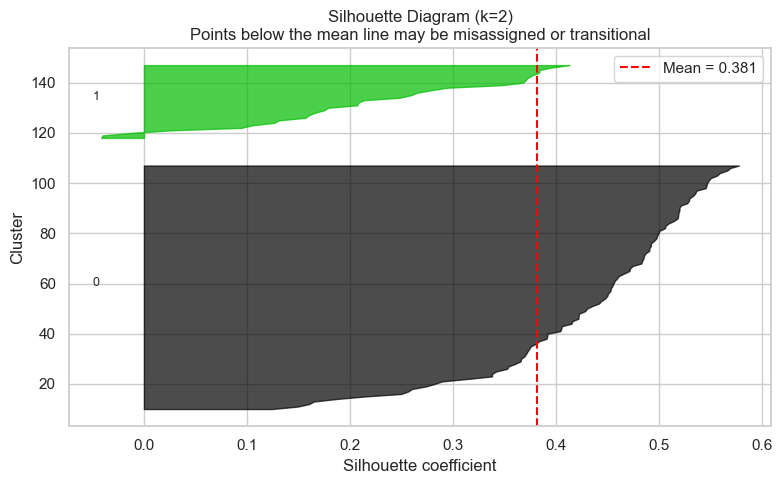

In [45]:
# ── Fit final model at chosen k ───────────────────────────────────────────
# Use the k that elbow, silhouette, and CH most agree on
k_final = best_k_sil   # adjust if domain knowledge suggests otherwise

km_final = KMeans(n_clusters=k_final, init='k-means++', n_init=20, random_state=SEED)
wc['cluster'] = km_final.fit_predict(X_scaled)

# Silhouette diagram
sil_vals = silhouette_samples(X_scaled, wc['cluster'])
wc['silhouette'] = sil_vals

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in range(k_final):
    c_vals = np.sort(sil_vals[wc['cluster'] == i])
    y_upper = y_lower + len(c_vals)
    color = cm.nipy_spectral(float(i) / k_final)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_vals, alpha=0.7, color=color)
    ax.text(-0.05, y_lower + 0.5*len(c_vals), str(i), fontsize=9)
    y_lower = y_upper + 10

mean_sil = np.mean(sil_vals)
ax.axvline(mean_sil, color='red', linestyle='--', label=f'Mean = {mean_sil:.3f}')
ax.set_xlabel('Silhouette coefficient'); ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Diagram (k={k_final})\n'
             'Points below the mean line may be misassigned or transitional')
ax.legend(); plt.tight_layout(); plt.show()


#### Step 2 — Feature profiles: what does each cluster look like statistically?

In [46]:
# ── Profile the clusters ─────────────────────────────────────────────────
profile = wc.groupby('cluster')[CORE_FEATURES+['round_reached']].mean().round(2)
profile = profile.sort_values('round_reached', ascending=False)
print("Cluster mean profiles (sorted by avg round reached):")
print(profile.to_string())

print("\nNotable team-tournaments by cluster:")
for c in sorted(wc['cluster'].unique()):
    subset = wc[wc['cluster']==c].sort_values('round_reached', ascending=False)
    print(f"\nCluster {c} (n={len(subset)}):")
    for _, row in subset.head(5).iterrows():
        print(f"  {row['team']:22s} {row['year']}  [{row['round_label']}]")


Cluster mean profiles (sorted by avg round reached):
         goals_scored  goals_conceded  goal_diff  shots  shots_on_target  shot_conversion  possession_pct  fouls  saves  save_pct  points  round_reached
cluster                                                                                                                                                 
1               11.00            5.37       5.63  89.33            30.07             0.13           53.16  87.93  51.03      0.86   12.53           3.90
0                3.34            5.06      -1.72  41.08            11.39             0.08           48.39  50.55  32.07      0.81    3.42           1.38

Notable team-tournaments by cluster:

Cluster 0 (n=98):
  Costa Rica             2014  [Quarter-final]
  Paraguay               2010  [Quarter-final]
  Sweden                 2018  [Quarter-final]
  Algeria                2014  [Round of 16]
  Japan                  2010  [Round of 16]

Cluster 1 (n=30):
  Spain                  201

Cluster 1 averages 11 goals, 89 shots, 53% possession, and 12.5 points — a
round reached of 3.9 (between QF and SF). Cluster 0 averages 3.3 goals, 41
shots, and 3.4 points — a round reached of 1.4, predominantly group stage.

#### Step 3 — Substantive naming: what does each cluster mean?

**Cluster 1 — Elite campaigns (n=30).** High volume, high output, dominant
possession, deep runs. The top members are tournament winners and runners-up:
Spain 2010, France 2018, Argentina 2022, Germany 2014, Croatia 2018. This is
the archetype of a successful World Cup campaign as measured by these 11
features.

**Cluster 0 — Everyone else (n=98).** Predominantly group stage exits, but
analytically heterogeneous. This cluster contains Paraguay 2010, Costa Rica
2014, and Sweden 2018 (all QF) alongside the weakest group stage exits. These
teams reached the quarter-final with a statistical profile indistinguishable
from an average group stage exit — the counter-attacking archetype we
identified in the 2D scatter plots. K-means with k=2 cannot separate them
because it draws a single linear boundary.

This is the key limitation of k=2: it correctly separates elite from
non-elite, but cannot distinguish sub-archetypes within the non-elite group.
A higher k would split Cluster 0 further — but the silhouette and CH indices
suggest the data does not cleanly support more than two geometrically distinct
groups. The two-cluster solution is the most justified geometrically, even if
it is substantively coarse.

### 5.6 Train on 2010–2018, evaluate on 2022

A genuine out-of-sample test: fit clusters on 2010–2018 data only, then assign
2022 teams to those clusters without refitting. The question is whether campaign
archetypes learned from historical data describe a new tournament.

#### What we are doing and why

All clustering so far has been descriptive — fitted and evaluated on the same
128 observations. That tells us the structure of the data we have, but not
whether that structure is stable across time. Here we treat 2010–2018 as a
training set and 2022 as a held-out test. We fit the cluster model on training
data only, then call `km_tr.predict(X_te)` to assign each 2022 team to the
nearest historical centroid without moving it. If historical archetypes
describe 2022 campaigns well, the cluster-to-performance relationship should
hold in the test set.

**The no-leakage principle applies here too.** We refit the scaler and imputer
on training data only and apply them to the test set. Fitting on the combined
dataset would leak 2022 information into the cluster boundaries.

`km_tr.transform(X_te).min(axis=1)` gives the distance from each 2022 team to
its assigned centroid — how well the historical archetype describes that
specific team. Large distances flag campaigns that do not fit any historical
cluster neatly.


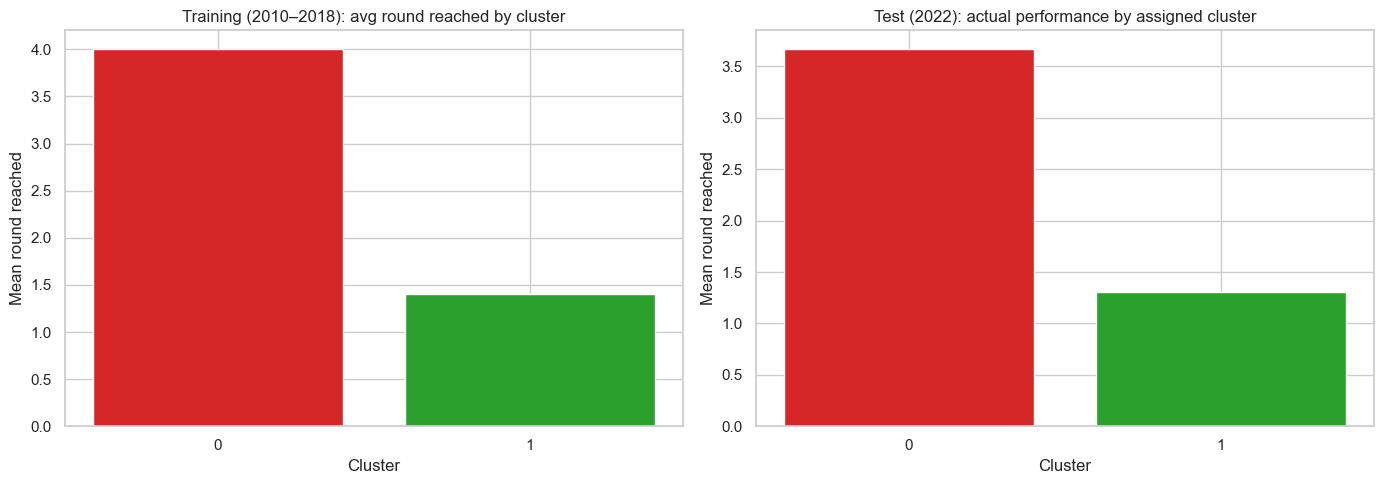


2022 teams and their assigned clusters:


'         team  cluster   round_label  dist_to_centroid\n    Argentina        0        Winner          2.644818\n       Brazil        0 Quarter-final          2.851437\n     Portugal        0 Quarter-final          3.285585\n      Croatia        0    Semi-final          3.379108\n       France        0     Runner-up          3.419009\n  Netherlands        0 Quarter-final          3.767994\n      England        0 Quarter-final          3.786177\n      Morocco        0    Semi-final          4.081425\n        Spain        0   Round of 16          5.242688\nUnited States        1   Round of 16          1.673808\n       Mexico        1   Group Stage          1.737868\n      Senegal        1   Round of 16          1.801825\n       Canada        1   Group Stage          2.042103\n  South Korea        1   Round of 16          2.122074\n Saudi Arabia        1   Group Stage          2.123386\n      Ecuador        1   Group Stage          2.141179\n      Uruguay        1   Group Stage          2

In [47]:
wc_train = wc[wc['year'].isin([2010, 2014, 2018])].copy()
wc_test  = wc[wc['year'] == 2022].copy()

# No imputation needed — core features are complete for all observations.
# Refit the scaler on training data only to avoid leaking 2022 statistics
# into the scaling parameters.
scaler_tr = StandardScaler()
X_tr = scaler_tr.fit_transform(wc_train[CORE_FEATURES])
X_te = scaler_tr.transform(wc_test[CORE_FEATURES])

km_tr = KMeans(n_clusters=k_final, init='k-means++', n_init=20, random_state=SEED)
wc_train['cluster'] = km_tr.fit_predict(X_tr)
wc_test['cluster']  = km_tr.predict(X_te)
wc_test['dist_to_centroid'] = km_tr.transform(X_te).min(axis=1)

# How well do 2010–2018 archetypes describe 2022?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tr_prof = wc_train.groupby('cluster')['round_reached'].mean().sort_values(ascending=False)
axes[0].bar(tr_prof.index.astype(str), tr_prof.values,
            color=[cluster_colors[i] for i in tr_prof.index])
axes[0].set_title('Training (2010–2018): avg round reached by cluster')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Mean round reached')

te_prof = wc_test.groupby('cluster')['round_reached'].mean().sort_values(ascending=False)
axes[1].bar(te_prof.index.astype(str), te_prof.values,
            color=[cluster_colors[i] for i in te_prof.index])
axes[1].set_title('Test (2022): actual performance by assigned cluster')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Mean round reached')

plt.tight_layout(); plt.show()

print("\n2022 teams and their assigned clusters:")
wc_test[['team','cluster','round_label','dist_to_centroid']]    .sort_values(['cluster','dist_to_centroid']).to_string(index=False)


#### Reading the results

**The bar charts** show the mean round reached by cluster in training (left)
and the mean round actually reached by 2022 teams assigned to each cluster
(right). Cluster 0 (red): training mean 4.0, test mean 3.6. Cluster 1 (green):
training mean 1.4, test mean 1.3. Both archetypes transfer well — the elite
cluster correctly identifies Argentina, France, Brazil, Croatia, England,
Morocco, and the Netherlands as the high-performing 2022 campaigns, and the
group stage cluster captures the majority of early exits.

**The team assignments** reveal where the historical archetypes fit poorly.
Costa Rica has the largest centroid distance (6.54) — assigned to the group
stage cluster but so far from the centroid that it is an unusual campaign even
within that archetype. Morocco (assigned elite cluster, dist = 4.08) is also
notable: the historical elite centroid was built from high-volume European and
South American campaigns, and Morocco's semi-final run was achieved with a
different profile — high defensive solidity, lower possession, fewer shots.
The assignment is correct in outcome but the large distance flags that Morocco
2022 represents a genuinely new type of deep run not well-represented in
historical data.

> **Discussion.** If the 2026 tournament introduces new campaign archetypes
> due to the expanded 48-team format — more mismatches, more defensive group
> stage football — which historical clusters would absorb them, and which
> 2026 teams might end up with large centroid distances? This connects
> directly to Section 7.

## PART 6 — DBSCAN: Density-Based Clustering

### 6.1 Why k-means is not always enough

K-means has three structural limitations that become visible when we look at the World Cup data:

1. **Hard assignments:** Costa Rica 2014 is forced into a cluster even though it sits equidistant from two centroids.
2. **Spherical assumption:** UMAP reveals curved, non-spherical structure. K-means' Euclidean centroids cannot capture this.
3. **No noise concept:** k-means cannot say "this team-tournament doesn't belong anywhere."

**DBSCAN** addresses all three.

### 6.2 The algorithm

DBSCAN defines clusters as **regions of high point density separated by regions of low density**.

Instead of specifying the number of clusters (k), we define what counts as a **dense neighbourhood**. Points that lie in sufficiently dense regions form clusters; points in sparse regions may be labelled **noise**.

Two hyperparameters control this definition of density.

**Two hyperparameters:**

* **ε (eps):** neighbourhood radius. Two points are neighbours if their distance ≤ ε.
* **min_samples:** minimum neighbours (including the point itself) required for a point to be a **core point**.

You can think of this as drawing a **circle of radius ε around each point**. If enough other points fall inside that circle, the point lies in a dense region of the dataset.


| Point type | Definition                                                    | Assigned to         |
| ---------- | ------------------------------------------------------------- | ------------------- |
| **Core**   | ≥ min_samples neighbours within ε                             | A cluster           |
| **Border** | Within ε of a core point, but < min_samples neighbours itself | That core's cluster |
| **Noise**  | Neither core nor border                                       | Label = **−1**      |

#### Visual intuition

Suppose we set

```
min_samples = 5
```

Because the point itself counts toward the total, a **core point must have at least four other neighbours within distance ε**.

Let's visualise what DBSCAN does [here](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/)




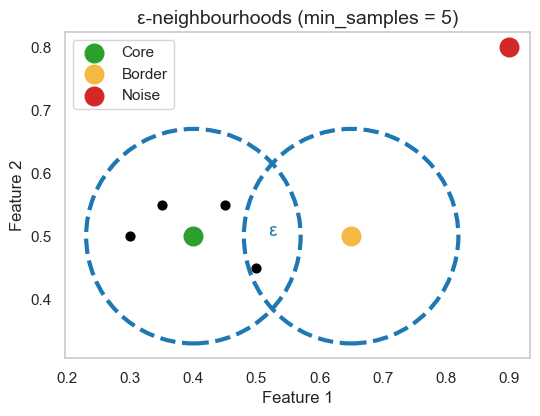

In [48]:
points = np.array([
    [0.4,0.5],   # core
    [0.45,0.55],
    [0.35,0.55],
    [0.50,0.45],
    [0.30,0.50],
    [0.65,0.50], # border
    [0.90,0.80]  # noise
])

eps = 0.17

core = points[0]
border = points[5]
noise = points[6]

fig, ax = plt.subplots(figsize=(6,6))

# background points
ax.scatter(points[:,0], points[:,1], color="black", s=40, zorder=3)

# highlight points
ax.scatter(*core, color="#2ca02c", s=180, label="Core", zorder=4)
ax.scatter(*border, color="#f4b942", s=180, label="Border", zorder=4)
ax.scatter(*noise, color="#d62728", s=180, label="Noise", zorder=4)

# ε neighbourhood circles
for p in [core, border]:
    circ = Circle(p, eps,
                  fill=False,
                  linewidth=3,
                  linestyle="--",
                  color="#1f77b4",
                  zorder=2)
    ax.add_patch(circ)

# epsilon label
ax.annotate("ε", (core[0]+eps*0.7, core[1]),
            fontsize=14, color="#1f77b4")

ax.set_title("ε-neighbourhoods (min_samples = 5)", fontsize=14)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

ax.set_aspect("equal")
ax.grid(False)

ax.legend(frameon=True)

plt.show()

**How to read the diagram**

- The dashed circle shows the ε-neighbourhood of each point.
- The green point has $≥ min_samples$ neighbours inside its ε-circle, so it is a core point.
- The orange point lies inside the ε-circle of a core point but does not have enough neighbours itself — it is a border point.
- The red point has no dense neighbourhood nearby and is therefore noise.

Points inside the ε-circle are considered neighbours. A point becomes a core point if its ε-neighbourhood contains at least `min_samples` observations.

#### How clusters form

Clusters grow from **core points**.

When DBSCAN finds a core point, it starts a cluster and examines all points within ε of that core point.

If any of those neighbours are also core points, their ε-neighbourhoods are explored as well. This creates a **chain of density-connected points**, allowing clusters to expand through overlapping neighbourhoods.

Border points may attach to a cluster, but **only core points can expand it**.

```mermaid
flowchart TD
    A[For each unvisited point] --> B{≥ min_samples neighbours within ε?}
    B -- Yes --> C[Core point: start/expand cluster]
    C --> A
    B -- No --> D{Within ε of a core point?}
    D -- Yes --> E[Border point: join that cluster]
    D -- No --> F[Noise point: label −1]
    E --> A; F --> A
```

#### Why this matters

Because clusters are defined by **density connectivity**, DBSCAN can:

* detect **non-spherical clusters**
* identify **outliers automatically**
* avoid forcing every observation into a cluster.

However, the results depend strongly on the choice of **ε** and **min_samples**, which we examine next

### 6.3 Choosing ε — the k-distance graph

Two parameters must be chosen for DBSCAN: **ε** and **min_samples**.
A common strategy is:

1. choose `min_samples` first
2. then choose **ε** using a **k-distance plot**

#### Choosing `min_samples`

A common rule of thumb is:

$$
\text{min\_samples} \approx \ln(n)
$$

where $n$ is the number of observations.

The intuition is that the density threshold should increase slowly with sample size: in larger datasets, we usually require slightly more neighbours before declaring that a point lies in a genuinely dense region.

A second rule of thumb sometimes used is:

$$
\text{min\_samples} \ge d+1
$$

where $d$ is the number of features. This can be useful when DBSCAN is applied directly in the **original feature space**, because it ensures that clusters are supported by more than a minimal number of points.

However, this rule is **less useful in transformed spaces such as UMAP**. If DBSCAN is run on a 2D UMAP embedding, then $d=2$, which would suggest a very small value such as `min_samples = 3`. In practice this is often too low, because UMAP is a non-linear projection for visualisation and does not preserve all geometric properties of the original space. For UMAP-based clustering, a sample-size-based heuristic such as $\ln(n)$, combined with visual inspection of the results, is usually more sensible.

#### Choosing ε using the k-distance graph

Once `min_samples` is chosen, we set $k = \text{min\_samples}$ and construct a **k-distance plot**.

1. For each point, compute the distance to its $k$-th nearest neighbour.
2. Sort these distances in ascending order.
3. Plot them.

The resulting curve often shows a **sharp bend (an elbow)**.

* **Left of the elbow:** points lie in dense regions and are likely to become **core points**
* **Right of the elbow:** points are relatively isolated and are more likely to be **border points or noise**

The ε value near this elbow is therefore a natural threshold separating dense regions from sparse ones.

If you want, I can also help rewrite the surrounding DBSCAN parameter-tuning section so it matches this caveat cleanly throughout.


min_samples = 4  (rule of thumb: ≈ ln(n))
Suggested ε = 3.025


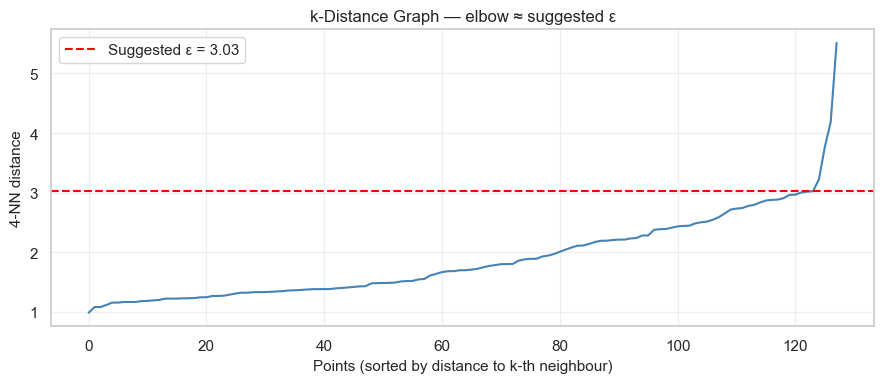

In [49]:
min_samples = max(3, int(np.log(len(wc))))
print(f"min_samples = {min_samples}  (rule of thumb: ≈ ln(n))")

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, linewidth=1.5, color='steelblue')
ax.set_xlabel('Points (sorted by distance to k-th neighbour)', fontsize=11)
ax.set_ylabel(f'{min_samples}-NN distance', fontsize=11)
ax.set_title('k-Distance Graph — elbow ≈ suggested ε', fontsize=12)
ax.grid(True, alpha=0.3)

if KNEED_AVAILABLE:
    kl_db = KneeLocator(range(len(k_distances)), k_distances,
                        curve='convex', direction='increasing')
    if kl_db.knee:
        eps_val = k_distances[kl_db.knee]
        ax.axhline(eps_val, color='red', linestyle='--',
                   label=f'Suggested ε = {eps_val:.2f}')
        ax.legend(); print(f"Suggested ε = {eps_val:.3f}")
    else:
        eps_val = np.percentile(k_distances, 80)
        print(f"No clear knee — using 80th percentile: ε = {eps_val:.3f}")
else:
    eps_val = np.percentile(k_distances, 80)
    print(f"Using 80th percentile: ε = {eps_val:.3f}")

plt.tight_layout(); plt.show()


In [50]:
# ── Choosing min_samples ─────────────────────────────────────────────────
# Rule of thumb: min_samples ≈ ln(n) for large datasets.
# For small datasets like ours (~128 obs), use 3–5.
# Higher min_samples → stricter core point definition → more noise points.
# Lower min_samples → more permissive → fewer noise points.
print(f"Dataset size: {len(wc)}")
print(f"ln(n) = {np.log(len(wc)):.1f}  →  min_samples = {min_samples}")
print("\nIf you find too many noise points, try reducing min_samples.")
print("If you find too few, increase it. Check robustness across multiple values.")


Dataset size: 128
ln(n) = 4.9  →  min_samples = 4

If you find too many noise points, try reducing min_samples.
If you find too few, increase it. Check robustness across multiple values.


In [51]:
# ── Apply DBSCAN ─────────────────────────────────────────────────────────
db = DBSCAN(eps=eps_val, min_samples=min_samples)
wc['cluster_db'] = db.fit_predict(X_scaled)

n_clusters_db = len(set(wc['cluster_db']) - {-1})
n_noise = (wc['cluster_db'] == -1).sum()
print(f"DBSCAN: {n_clusters_db} cluster(s), {n_noise} noise points ({n_noise/len(wc)*100:.1f}%)")
print("\nCluster sizes:")
print(wc['cluster_db'].value_counts().sort_index().to_string())


DBSCAN: 1 cluster(s), 2 noise points (1.6%)

Cluster sizes:
cluster_db
-1      2
 0    126


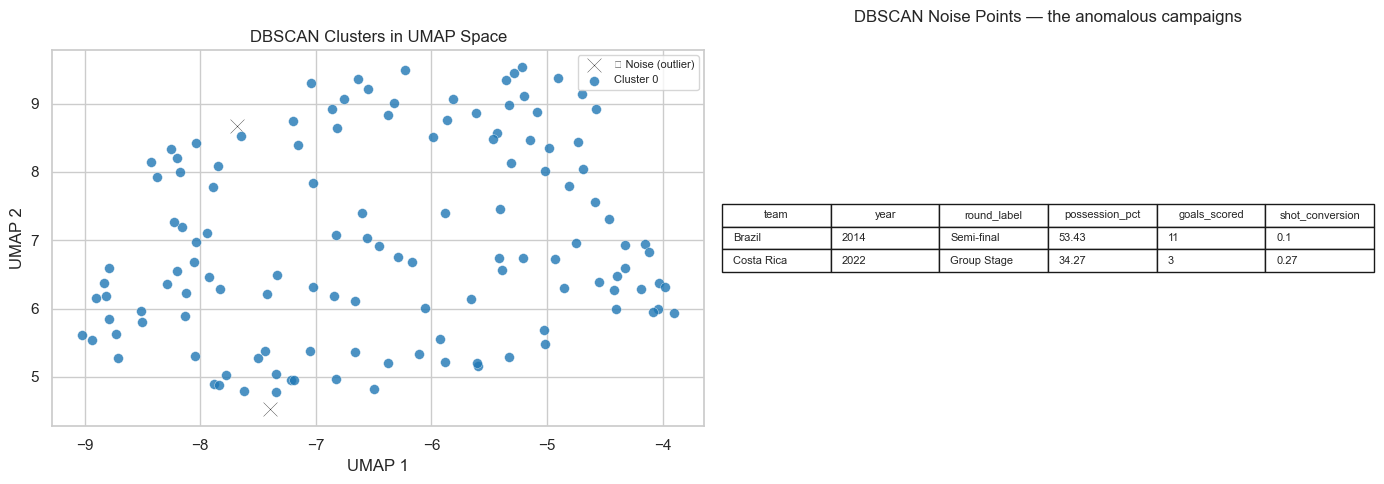

In [52]:
if UMAP_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    db_labels = sorted(wc['cluster_db'].unique())
    cmap_db = plt.cm.get_cmap('tab10', max(len(db_labels), 2))
    for lbl in db_labels:
        mask = wc['cluster_db'] == lbl
        color  = 'black' if lbl == -1 else cmap_db(lbl)
        marker = 'x'     if lbl == -1 else 'o'
        ms     = 100     if lbl == -1 else 50
        label  = '⚠ Noise (outlier)' if lbl == -1 else f'Cluster {lbl}'
        axes[0].scatter(wc.loc[mask,'UMAP1'], wc.loc[mask,'UMAP2'],
                        c=[color], marker=marker, s=ms, alpha=0.8,
                        label=label, edgecolors='white', linewidth=0.3)
    axes[0].set_title('DBSCAN Clusters in UMAP Space')
    axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
    axes[0].legend(fontsize=8)

    # Who are the noise points?
    noise = wc[wc['cluster_db']==-1][['team','year','round_label',
                                       'possession_pct','goals_scored','shot_conversion']]
    axes[1].axis('off')
    if len(noise):
        tbl = axes[1].table(cellText=noise.round(2).values,
                            colLabels=noise.columns, loc='center', cellLoc='left')
        tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.4)
    axes[1].set_title('DBSCAN Noise Points — the anomalous campaigns', pad=20)
    plt.tight_layout(); plt.show()


**The noise points are the most analytically interesting DBSCAN output.**

Unlike k-means, which forces every observation into a cluster, DBSCAN allows points to remain **unassigned** when they do not belong to any sufficiently dense region of feature space. In this run, DBSCAN identifies **one large cluster representing the typical campaign profile**, while two team–tournaments are labelled **noise**.

These noise points correspond to **Brazil 2014** and **Costa Rica 2022**. DBSCAN is effectively saying that these campaigns **do not resemble the majority of historical campaigns closely enough to belong to the main dense region of the data**.

This does not mean they are errors or irrelevant observations. On the contrary, they represent **statistical outliers** — campaigns whose combination of performance indicators is unusual relative to the rest of the dataset.

Brazil 2014 stands out because of its **dramatic defensive collapse**, most famously the 7–1 semi-final defeat. Costa Rica 2022 appears unusual for the opposite reason: **low-possession, low-scoring football combined with unusually high shot conversion**, producing a profile that sits far from the typical structure of the dataset.

From an analytical perspective, these anomalies are often the most interesting observations. They highlight campaigns that **do not follow the dominant patterns of tournament performance**, and therefore deserve closer examination.

> **Connection to Week 9: Anomaly Detection**
> The DBSCAN noise label and the **autoencoder reconstruction error** (Section 3.6) are two independent signals pointing to the same phenomenon: observations that do not conform to the dominant structure of the data. In Week 9 we will formalise this idea and build a full **anomaly detection pipeline**, comparing whether different methods flag the same campaigns as unusual.


**Why did DBSCAN find only one cluster?**

DBSCAN detects **dense regions separated by sparse regions**. In this dataset, most team–tournaments occupy a **single continuous region of feature space**, meaning there are no clear density gaps that would naturally split the data into multiple groups. As a result, DBSCAN identifies **one large dense cluster representing the typical World Cup campaign profile**, while only a few observations lie far enough away to be labelled as noise.

This highlights an important difference between clustering methods:

* **k-means** always partitions the data into *k* clusters, even if the structure is weak.
* **DBSCAN** only creates additional clusters when **separate dense regions truly exist**.

In other words, DBSCAN is telling us that **most campaigns vary along a continuum rather than forming sharply separated archetypes**, with only a handful of genuinely unusual cases.

### 6.4 Parameter sensitivity


In [53]:
# ── Sensitivity: vary eps and min_samples ────────────────────────────────
results_sens = []
for eps_c in [eps_val*0.7, eps_val, eps_val*1.3]:
    for ms_c in [max(3, min_samples-1), min_samples, min_samples+1]:
        labels_c = DBSCAN(eps=eps_c, min_samples=ms_c).fit_predict(X_scaled)
        results_sens.append({
            'eps': round(eps_c, 3), 'min_samples': ms_c,
            'n_clusters': len(set(labels_c)-{-1}),
            'n_noise': (labels_c==-1).sum()
        })

sens_df = pd.DataFrame(results_sens)
print("Noise points across parameter values (sensitivity check):")
print(sens_df.pivot(index='eps', columns='min_samples', values='n_noise').to_string())
print("\nStructure that is stable across all settings is trustworthy.")


Noise points across parameter values (sensitivity check):
min_samples   3   4   5
eps                    
2.118        22  27  32
3.025         2   2   2
3.933         1   1   1

Structure that is stable across all settings is trustworthy.


## PART 7 — World Cup 2026 Predictions

### 7.1 The prediction problem

So far we have analysed **historical World Cup campaigns** and identified several **campaign archetypes** using clustering. These archetypes describe typical tournament trajectories — for example deep runs by elite teams, solid quarter-final teams, or early exits.

A natural question follows:

> **Where would the teams qualified for the 2026 World Cup fall within these historical patterns?**

Our goal here is **not to simulate the tournament**. Instead, we assign each 2026 team to the **most similar historical campaign archetype**.

In other words, we ask:

> *Which historical campaigns does this team most resemble before the tournament begins?*

This produces a **baseline expectation** of tournament performance based on historical patterns.

### 7.2 The methodological challenge

A key difficulty is that the variables used in our clustering step are **match statistics** from completed tournaments, such as:

* goals scored
* shots
* possession
* round reached

These variables obviously **do not exist yet for the 2026 tournament**.

In addition, qualification statistics are **not comparable across confederations**. For example:

* CONMEBOL teams play long round-robin qualifiers against elite opposition
* UEFA teams play short group formats with large skill disparities
* AFC and CONCACAF formats differ again

Directly comparing qualifying performance would therefore introduce strong biases.

To avoid this, we construct **proxy features** that approximate the same underlying concepts while using information available before the tournament.

### 7.3 Constructing proxy features

The idea is to build variables that roughly correspond to the historical campaign statistics used in clustering.

| Historical feature | 2026 proxy                       | Interpretation                            |
| ------------------ | -------------------------------- | ----------------------------------------- |
| Goals scored       | Scaled FIFA ranking points       | Stronger teams tend to score more         |
| Possession         | Confederation average possession | Confederations have characteristic styles |
| Shots              | Confederation average shots      | Proxy for attacking activity              |
| Round reached      | Best ever round reached          | Historical performance ceiling            |

These proxies do **not attempt to predict match outcomes directly**. Their purpose is simply to place the 2026 teams **into approximately the same feature space used to discover the historical campaign archetypes**.

Because of this simplification, the results should be interpreted as **baseline expectations rather than precise forecasts**.


In [54]:
TEAMS_2026 = [
    ('Argentina','CONMEBOL',1844,18,6),('France','UEFA',1820,16,6),
    ('Spain','UEFA',1803,16,6),('England','UEFA',1789,17,5),
    ('Brazil','CONMEBOL',1782,22,6),('Portugal','UEFA',1763,9,4),
    ('Belgium','UEFA',1757,14,4),('Netherlands','UEFA',1742,11,5),
    ('Germany','UEFA',1726,20,6),('Italy','UEFA',1715,18,6),
    ('Croatia','UEFA',1698,8,5),('Morocco','CAF',1687,6,4),
    ('Japan','AFC',1673,8,3),('USA','CONCACAF',1661,11,3),
    ('Switzerland','UEFA',1655,12,4),('Denmark','UEFA',1649,6,4),
    ('Mexico','CONCACAF',1643,17,3),('Colombia','CONMEBOL',1638,6,3),
    ('Uruguay','CONMEBOL',1631,14,4),('Senegal','CAF',1622,4,3),
    ('Poland','UEFA',1614,9,3),('South Korea','AFC',1608,11,4),
    ('Ecuador','CONMEBOL',1597,4,2),('Canada','CONCACAF',1591,3,1),
    ('Austria','UEFA',1583,8,3),('Australia','AFC',1572,6,3),
    ('Iran','AFC',1561,6,2),('Nigeria','CAF',1549,7,3),
    ('Serbia','UEFA',1538,4,3),('Czech Republic','UEFA',1527,10,4),
    ('Cameroon','CAF',1518,8,3),('Ghana','CAF',1509,4,3),
    ('Tunisia','CAF',1498,6,2),('Saudi Arabia','AFC',1487,6,2),
    ('Paraguay','CONMEBOL',1476,9,3),('Chile','CONMEBOL',1465,10,3),
    ('Venezuela','CONMEBOL',1454,1,1),('Honduras','CONCACAF',1443,3,1),
    ('Costa Rica','CONCACAF',1432,6,3),('Panama','CONCACAF',1421,2,1),
    ('Bolivia','CONMEBOL',1410,6,1),('Peru','CONMEBOL',1399,9,3),
    ('Algeria','CAF',1388,4,3),('Ivory Coast','CAF',1377,4,2),
    ('Egypt','CAF',1366,3,2),('Iraq','AFC',1355,5,2),
    ('New Zealand','OFC',1312,3,2),('Cuba','CONCACAF',1290,4,1),
]

wc26 = pd.DataFrame(TEAMS_2026,
    columns=['team','confederation','fifa_rank_pts','wc_appearances','best_round_ever'])
print(f"2026 qualified teams: {len(wc26)}")
wc26.head(6)


2026 qualified teams: 48


,team,confederation,fifa_rank_pts,wc_appearances,best_round_ever
0,Argentina,CONMEBOL,1844,18,6
1,France,UEFA,1820,16,6
2,Spain,UEFA,1803,16,6
3,England,UEFA,1789,17,5
4,Brazil,CONMEBOL,1782,22,6
5,Portugal,UEFA,1763,9,4


### 7.4 Mapping teams to historical campaign archetypes

Once the proxy features are constructed, we assign each team to a campaign archetype using a **k-nearest neighbours (KNN) classifier**.

Conceptually the process works as follows:

1. Historical campaigns have

   * feature vectors
   * cluster labels obtained from the clustering step.

2. Each 2026 team receives a **proxy feature vector** constructed from ranking, confederation averages, and historical performance.

3. For each team we identify the **k most similar historical campaigns** (here (k = 5)).

4. The team is assigned the **cluster most common among those neighbours**.

Importantly:

* **The clusters themselves are not recalculated.**
* We simply **map new observations onto the existing historical campaign structure.**

In effect, the model answers:

> *Which historical World Cup campaigns does this team most resemble?*

The cluster associated with those campaigns becomes the team’s **predicted campaign archetype**.

### 7.5 Interpreting clusters as campaign tiers

To make the results easier to interpret, we convert clusters into intuitive **campaign tiers** based on the historical average round reached.

| Tier                      | Interpretation                                           |
| ------------------------- | -------------------------------------------------------- |
| 🏆 **Elite / Favourites** | Campaign profiles historically associated with deep runs |
| ⚡ **Contenders**          | Strong teams capable of quarter-finals or beyond         |
| 🛡 **Solid performers**   | Competitive teams typically reaching the knockouts       |
| 👋 **Group stage teams**  | Teams historically eliminated early                      |

The model then assigns each 2026 team to one of these tiers.

### 7.6 Predicted campaign tiers

The predictions broadly reflect the current hierarchy of international football.

The **elite tier** contains the teams whose statistical profiles most resemble historical deep-run campaigns. These include traditional powers such as:

* Argentina
* France
* Spain
* Brazil
* Germany
* England
* Italy
* Netherlands

These teams combine strong FIFA rankings with long histories of deep tournament runs.

The largest group falls into the **contender tier**. These are competitive teams capable of reaching the later knockout rounds but less consistently associated with semi-final runs. Examples include:

* Morocco
* Switzerland
* Denmark
* Senegal
* Mexico
* USA
* Japan

Historically, teams with similar profiles most often reach the **round of 16 or quarter-finals**, with occasional breakthroughs.

In [55]:
# ── Nearest-neighbour cluster assignment ──────────────────────────────────
# Build proxy feature matrix from historical data for comparison
hist_proxy = wc[['goals_scored','round_reached','possession_pct','shots']].copy()
hist_proxy_sc = StandardScaler().fit_transform(
    SimpleImputer(strategy='median').fit_transform(hist_proxy))

# Build comparable proxy matrix for 2026 teams
conf_means = wc.groupby('confederation')[['possession_pct','shots']].mean()
wc26['poss_proxy']  = wc26['confederation'].map(conf_means['possession_pct'])
wc26['shots_proxy'] = wc26['confederation'].map(conf_means['shots'])

# Scale FIFA ranking → rough goals proxy
min_r, max_r = wc26['fifa_rank_pts'].min(), wc26['fifa_rank_pts'].max()
min_g, max_g = wc['goals_scored'].min(), wc['goals_scored'].max()
wc26['goals_proxy'] = (wc26['fifa_rank_pts']-min_r)/(max_r-min_r)*(max_g-min_g)+min_g

proxy_2026 = wc26[['goals_proxy','best_round_ever','poss_proxy','shots_proxy']].fillna(wc26[['goals_proxy','best_round_ever','poss_proxy','shots_proxy']].mean())
proxy_sc   = StandardScaler().fit_transform(proxy_2026)

# KNN classifier trained on historical proxy → cluster label
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(hist_proxy_sc, wc['cluster'])
wc26['predicted_cluster'] = knn.predict(proxy_sc)

# Label clusters by historical round_reached mean
cluster_means = wc.groupby('cluster')['round_reached'].mean().sort_values(ascending=False)
tier_map = {}
tier_names = ['🏆 Elite / Favourites','⚡ Contenders','🛡 Solid Performers','👋 Group Stage']
for i, (cid, _) in enumerate(cluster_means.items()):
    tier_map[cid] = tier_names[min(i, len(tier_names)-1)]
wc26['tier'] = wc26['predicted_cluster'].map(tier_map)

print("\n=== 🔮 World Cup 2026 — Predicted Campaign Tiers ===\n")
for tier in tier_names:
    teams = sorted(wc26[wc26['tier']==tier]['team'].tolist())
    if teams:
        print(f"{tier}:"); print(f"  {', '.join(teams)}\n")



=== 🔮 World Cup 2026 — Predicted Campaign Tiers ===

🏆 Elite / Favourites:
  Argentina, Belgium, Brazil, Colombia, Croatia, England, France, Germany, Italy, Netherlands, Portugal, Spain, Uruguay

⚡ Contenders:
  Algeria, Australia, Austria, Bolivia, Cameroon, Canada, Chile, Costa Rica, Cuba, Czech Republic, Denmark, Ecuador, Egypt, Ghana, Honduras, Iran, Iraq, Ivory Coast, Japan, Mexico, Morocco, New Zealand, Nigeria, Panama, Paraguay, Peru, Poland, Saudi Arabia, Senegal, Serbia, South Korea, Switzerland, Tunisia, USA, Venezuela



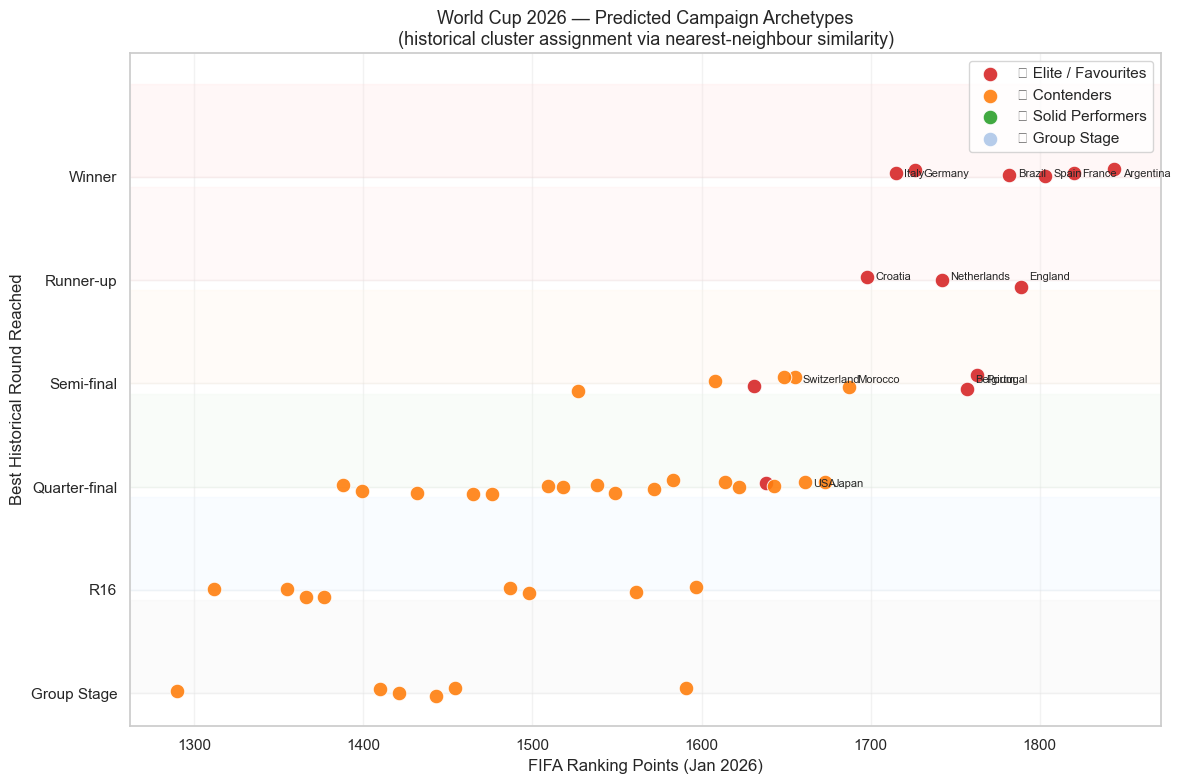

In [56]:
fig, ax = plt.subplots(figsize=(12,8))

# horizontal bands for rounds
bands = [
    (1,1.9,'#f0f0f0'),
    (2,2.9,'#e8f4ff'),
    (3,3.9,'#eaf7ea'),
    (4,4.9,'#fff3e6'),
    (5,5.9,'#ffe8e8'),
    (6,6.9,'#ffe0e0')
]

# ── Tier colour map ───────────────────────────────────────────────────────
# Defined here so it is available to all Section 7 plots.
tier_colors_map = {
    '🏆 Elite / Favourites': '#d62728',
    '⚡ Contenders':          '#ff7f0e',
    '🛡 Solid Performers':    '#2ca02c',
    '👋 Group Stage':         '#aec7e8',
}

for low,high,color in bands:
    ax.axhspan(low,high,color=color,alpha=0.25)

for tier, color in tier_colors_map.items():
    mask = wc26['tier']==tier

    ax.scatter(
        wc26.loc[mask,'fifa_rank_pts'],
        wc26.loc[mask,'best_round_ever'] +
        np.random.uniform(-0.08,0.08,mask.sum()),
        c=color,
        s=110,
        edgecolors='white',
        linewidth=0.7,
        alpha=0.9,
        label=tier
    )

# label only strongest teams to avoid clutter
top_labels = wc26.sort_values("fifa_rank_pts",ascending=False).head(15)

for _, row in top_labels.iterrows():
    ax.text(
        row['fifa_rank_pts']+5,
        row['best_round_ever'],
        row['team'],
        fontsize=8
    )

ax.set_xlabel("FIFA Ranking Points (Jan 2026)",fontsize=12)
ax.set_ylabel("Best Historical Round Reached",fontsize=12)

ax.set_yticks(range(1,7))
ax.set_yticklabels([
    "Group Stage",
    "R16",
    "Quarter-final",
    "Semi-final",
    "Runner-up",
    "Winner"
])

ax.set_title(
"World Cup 2026 — Predicted Campaign Archetypes\n"
"(historical cluster assignment via nearest-neighbour similarity)",
fontsize=13
)

ax.grid(True,alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

### 7.7 Reading the prediction plot

The figure visualises the predicted campaign tiers.

* **x-axis:** FIFA ranking points (January 2026) — a proxy for current team strength
* **y-axis:** best historical round reached — a proxy for long-term tournament performance
* **colour:** predicted campaign tier

Teams toward the **top-right of the plot** combine strong current rankings with strong historical performance and therefore appear as natural tournament favourites.

Teams lower on the plot typically lack either:

* sustained historical success, or
* current competitive strength.

The clustering-based tier assignment therefore reflects a **combination of current ability and historical performance ceiling**.

### 7.8 What this model does *not* capture

This prediction should not be interpreted as a forecast of the actual tournament outcome.

Several important factors are not included in this simplified model:

* squad injuries
* generational talent cycles
* coaching changes and tactical systems
* randomness inherent in knockout tournaments

World Cups frequently produce unexpected runs — for example:

* Croatia reaching the **2018 final**
* Morocco reaching the **2022 semi-final**
* Costa Rica reaching the **2014 quarter-finals**

Such surprises correspond exactly to the **anomalous campaigns** identified earlier using DBSCAN and other methods.

### 7.9 Key takeaway

This section does not attempt to predict the tournament winner. Instead, it places each 2026 team within the **historical landscape of World Cup campaigns**.

The result is a **data-driven prior expectation** based on historical patterns.

The most interesting stories in the 2026 tournament will likely be the teams that **defy these expectations** — the campaigns that fall outside the historical archetypes we have identified.

## PART 8 — Key Takeaways

| Topic | Core idea |
|-------|-----------|
| **MCA** | Chi-square distance for categoricals; column coordinates: distance = association, origin distance = distinctiveness |
| **FAMD** | Unified DR for mixed data; cross-type relationships captured in one space |
| **UMAP** | Non-linear manifold; outliers and non-convex structure visible; validate with n_neighbors sensitivity |
| **Autoencoders** | Non-linear compression; reconstruction error = anomaly score; interpret geometrically not algebraically |
| **DR → supervised** | Fit DR on training data only (no-leakage); PCA inside Pipeline; AE managed manually |
| **Clustering in 2D** | 3 feature pairs → intuition for archetypes; reveals counter-attacking outliers |
| **K-means** | Minimise WCSS; k-means++ init; standardise first; synthetic centroids |
| **K-medoids** | Real observation as centre; robust to outliers; any distance metric |
| **Choosing k** | Elbow + silhouette + CH index; require agreement; domain knowledge breaks ties |
| **Cluster evaluation** | Internal indices measure geometry, not meaning; always validate substantively |
| **DBSCAN** | Density-based; noise label = anomaly; ε from k-distance graph; sensitivity check |
| **2026 predictions** | Proxy features → prior; updateable as tournament data arrives |

### Decision guide

```
All numeric features?  → K-Means or K-Medoids (Euclidean, standardised)
Know k?                → K-Means / K-Medoids
Don't know k?          → Elbow + Silhouette + CH  OR  DBSCAN
Outliers matter?       → DBSCAN (noise label −1)
Non-spherical clusters?→ DBSCAN or cluster on UMAP embedding
High-dimensional?      → Reduce with PCA/UMAP first, then cluster
Need interpretable centres? → K-Medoids (medoid is a real observation)
```

**Week 9:** DBSCAN noise points + autoencoder reconstruction error → full anomaly detection pipeline (Isolation Forest, LOF) on government procurement data.


## APPENDIX - Quick note: Similarity metrics

Underlying the discussion about clustering, are similarity metrics. We mostly assumed until now that the similarity metric that was used was the Euclidean distance (and for k-means, this is a fair assumption to make). But there are cases where the Euclidean distance would not be an appropriate choice (e.g when comparing strings or sets or for computer vision or recommendation engines applications).

Here is a quick run-through of some of the most common similarity metrics:

*Real-valued data:*

-   Euclidian distance: $d(A,B)=\sqrt{\sum_{i=1}^n |A_i-B_i|^2}$

-   Cosine distance: $S_C(A,B)=\frac{\sum_{i=1}^n A_iB_i}{\sqrt{\sum_{i=1}^n A_i^2}\sqrt{\sum_{i=1}^n B_i^2}}$

where **A** and **B** are two n-dimensional vectors of attributes, and $A_i$ and $B_i$ the $i$th components of vectors **A** and **B** respectively

(metric frequently used in NLP and computer vision - see \[this page\](<https://www.datastax.com/guides/real-world-applications-of-cosine-similarity>) for more information)

*String similarity:*

-   Hamming distance: given two strings of equal length, it is the number of positions at which the corresponding symbols (i.e either letters, bits, or decimal digits) are different e.g:

    -   [0000]{style="color:#BA160C"} and [1111]{style="color:#BA160C"} is 4
    -   ca[t]{style="color:#BA160C"} and ca[r]{style="color:#BA160C"} is 1
    -   c[a]{style="color:#BA160C"}l[l]{style="color:#BA160C"} and c[o]{style="color:#BA160C"}l[d]{style="color:#BA160C"} is 2

-   Levenstein distance: given two strings, it's the minimal number of edits (substitutions, deletions, insertions) needed to turn one string into another e.g:

    The Levenshtein distance between *kitten* and *sitting* is 3, since the following 3 edits change one into the other, and there is no way to do it with fewer than 3 edits:

    1.  [k]{style="color:#BA160C"}itten → [s]{style="color:#BA160C"}itten (substitution of "s" for "k"),
    2.  sitt[e]{style="color:#BA160C"}n → sitt[i]{style="color:#BA160C"}n (substitution of "i" for "e"),
    3.  sittin → sittin[g]{style="color:#BA160C"} (insertion of "g" at the end).

*Set similarity:*

A set is a collection of items with no order or repetition. Sets are typically used to represent relationships or associations between objects or even people.

-   Jaccard index: it is often used in recommendation systems and social media analysis and measures the similarity between two sets based on the number of items present in both sets relative to the total number of items:

    $J(A,B)=\frac{|A\cap B|}{|A\cup B|}$

    where A and B are two sets, $|A\cap B|$ the number of items included in both sets and $|A\cup B|$ the total number of items

Another useful resources: \[this page\](<https://scikit-learn.org/stable/modules/clustering.html>) compares various clustering algorithms (among which k-means and DBSCAN) and shows their parameters, use cases,...

**Bibliography**

*About k-means++*

David Arthur and Sergei Vassilvitskii. 2007. *K-means++: the advantages of careful seeding*. In Proceedings of the eighteenth annual ACM-SIAM symposium on Discrete algorithms (SODA '07). Society for Industrial and Applied Mathematics, USA, 1027–1035. <https://dl.acm.org/doi/10.5555/1283383.1283494>

*About k-medoid*

Leonard Kaufman and Peter J. Rousseeuw (1990). *Partitioning Around Medoids (Program PAM)*. In Finding Groups in Data (eds L. Kaufman and P.J. Rousseeuw). <https://doi.org/10.1002/9780470316801.ch2>

Erich Schubert, Peter J. Rousseeuw, *Fast and eager k-medoids clustering: O(k) runtime improvement of the PAM, CLARA, and CLARANS algorithms*, Information Systems, Volume 101, 2021, 101804, ISSN 0306-4379, <https://doi.org/10.1016/j.is.2021.101804.>

*About DBSCAN*

Martin Ester, Hans-Peter Kriegel, Jörg Sander, and Xiaowei Xu. 1996. *A density-based algorithm for discovering clusters in large spatial databases with noise*. In Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD'96). AAAI Press, 226–231. <https://dl.acm.org/doi/10.5555/3001460.3001507>

*About missing data mechanisms and missing data handling*

Enders, Craig K. *Applied missing data analysis*. Guilford Publications, 2022.

Scheffer, J. (2002), Dealing with missing data, Research Letters in the Information and Mathematical Sciences, 3, 153-160. <http://hdl.handle.net/10179/4355>

McKnight, Patrick E., et al. *Missing data: A gentle introduction*. Guilford Press, 2007.

*Clustering with mixed attributes (numerical and categorical)*

- *Clustering — Beyonds KMeans+PCA…*,Shahar Gino, Medium, Jul 14, 2023, [https://sgino209.medium.com/clustering-beyonds-kmeans-pca-878c235840c9](https://sgino209.medium.com/clustering-beyonds-kmeans-pca-878c235840c9)
- *The k-prototype as Clustering Algorithm for Mixed Data Type (Categorical and Numerical)*,Audhi Aprilliant, Jan 17, 2021, Towards Data Science, [https://towardsdatascience.com/the-k-prototype-as-clustering-algorithm-for-mixed-data-type-categorical-and-numerical-fe7c50538ebb/?source=post_page-----76537d84a669---------------------------------------](https://towardsdatascience.com/the-k-prototype-as-clustering-algorithm-for-mixed-data-type-categorical-and-numerical-fe7c50538ebb/?source=post_page-----76537d84a669---------------------------------------)
- Z. Huang. "Extensions to the k-Means Algorithm for Clustering Large Data Sets with Categorical Values" (1998). *Data Mining and Knowledge Discovery*. 2(3): 283–304.[https://link.springer.com/article/10.1023/A:1009769707641](https://link.springer.com/article/10.1023/A:1009769707641)
- *The Ultimate Guide for Clustering Mixed Data*, Eoghan Keany, Nov 1, 2021, [https://medium.com/analytics-vidhya/the-ultimate-guide-for-clustering-mixed-data-1eefa0b4743b](https://medium.com/analytics-vidhya/the-ultimate-guide-for-clustering-mixed-data-1eefa0b4743b)
- "Clustering on numerical and categorical features", Jorge Martín Lasaosa, May 29, 2021[https://towardsdatascience.com/clustering-on-numerical-and-categorical-features-6e0ebcf1cbad/](https://towardsdatascience.com/clustering-on-numerical-and-categorical-features-6e0ebcf1cbad/)

*Selecting $k$ for $k$-means*

- "Are You Still Using the Elbow Method?", Samuele Mazzanti, Medium, Feb 3, 2023, [https://medium.com/data-science/are-you-still-using-the-elbow-method-5d271b3063bd](https://medium.com/data-science/are-you-still-using-the-elbow-method-5d271b3063bd)
- "K-means, DBSCAN, GMM, Agglomerative clustering – Mastering the popular models in a segmentation…",Indraneel Dutta Baruah,Nov 8, 2020, [https://towardsdatascience.com/k-means-dbscan-gmm-agglomerative-clustering-mastering-the-popular-models-in-a-segmentation-c891a3818e29/](https://towardsdatascience.com/k-means-dbscan-gmm-agglomerative-clustering-mastering-the-popular-models-in-a-segmentation-c891a3818e29/) (Also talks about how to select DBSCAN's parameters)
- Erich Schubert. 2023. Stop using the elbow criterion for k-means and how to choose the number of clusters instead. SIGKDD Explor. Newsl. 25, 1 (June 2023), 36–42. [https://doi.org/10.1145/3606274.3606278](https://doi.org/10.1145/3606274.3606278)

*UMAP*

McInnes, Leland, John Healy, and James Melville. "Umap: Uniform manifold approximation and projection for dimension reduction." [arXiv preprint arXiv:1802.03426 (2018)](https://arxiv.org/abs/1802.03426).


